In [ ]:
import torch
import numpy as np
import random

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Forces deterministic behavior in CUDA
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

# Data Import and Cleaning





In [1]:
import requests
import os

# GitHub API URL for the directory contents
api_url = "https://api.github.com/repos/carmelh/SQL_projects/contents/student_data_analysis/Datasets"

response = requests.get(api_url)

if response.status_code == 200:
    files = response.json()
    os.makedirs('student_data', exist_ok=True)

    for file in files:
        if file['name'].endswith('.csv'):
            download_url = file['download_url']
            print(f"Downloading {file['name']}...")
            file_content = requests.get(download_url).content
            with open(f"student_data/{file['name']}", 'wb') as f:
                f.write(file_content)
    print("All CSV files downloaded to 'student_data' folder.")
else:
    print(f"Failed to access GitHub API. Status code: {response.status_code}")

All CSV files downloaded to 'student_data' folder.


In [2]:
import os

# List the downloaded files to confirm
print("Downloaded files:")
print(os.listdir('student_data'))

Downloaded files:
['tA6_parent_previous_quals.csv', 'tA5_previous_quals.csv', 'tA7_parent_occupation.csv', 'dataset.csv', 'tA3_application_mode.csv', 'tA10_yes_no.csv', 'tA1_marital_status.csv', 'tA8_gender.csv', 'tA4_course_names.csv', 'tA9_attendance_regime.csv', 'tA2_nationality.csv']


In [3]:
import pandas as pd
import os

data_dir = 'student_data'
dataframes = {}

# Load each CSV into the dictionary
for filename in os.listdir(data_dir):
    if filename.endswith('.csv'):
        df_name = filename.replace('.csv', '')
        file_path = os.path.join(data_dir, filename)
        dataframes[df_name] = pd.read_csv(file_path)
        print(f"Loaded {filename} as '{df_name}'")

# Display the main dataset head
if 'dataset' in dataframes:
    print('\nPreview of main dataset:')
    display(dataframes['dataset'].head())

Loaded tA6_parent_previous_quals.csv as 'tA6_parent_previous_quals'
Loaded tA5_previous_quals.csv as 'tA5_previous_quals'
Loaded tA7_parent_occupation.csv as 'tA7_parent_occupation'
Loaded dataset.csv as 'dataset'
Loaded tA3_application_mode.csv as 'tA3_application_mode'
Loaded tA10_yes_no.csv as 'tA10_yes_no'
Loaded tA1_marital_status.csv as 'tA1_marital_status'
Loaded tA8_gender.csv as 'tA8_gender'
Loaded tA4_course_names.csv as 'tA4_course_names'
Loaded tA9_attendance_regime.csv as 'tA9_attendance_regime'
Loaded tA2_nationality.csv as 'tA2_nationality'

Preview of main dataset:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [4]:
if 'dataset' in dataframes:
    df = dataframes['dataset']

    print("Dataset Information:")
    df.info()

    print("\nDescriptive Statistics:")
    display(df.describe(include='all'))
else:
    print("The 'dataset' dataframe is not available.")

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation 

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,...,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,...,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,...,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,...,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,...,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN


/tmp/ipykernel_2404/661842488.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Target', data=df, palette='viridis')


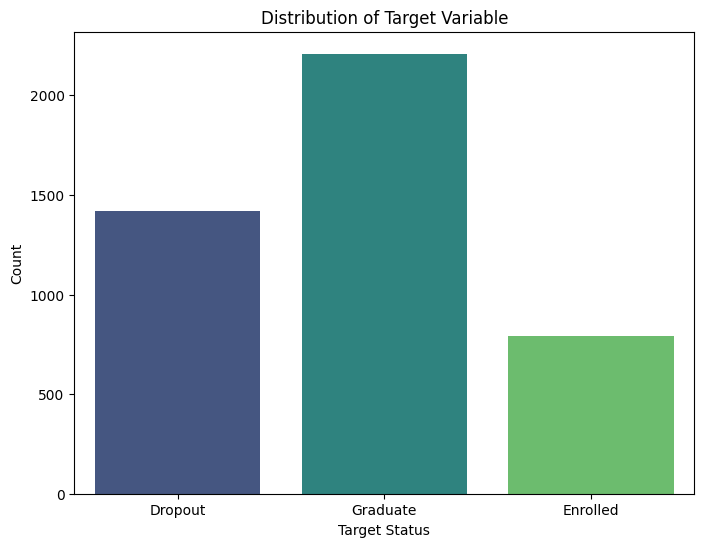

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'dataset' in dataframes:
    df = dataframes['dataset']

    plt.figure(figsize=(8, 6))
    sns.countplot(x='Target', data=df, palette='viridis')
    plt.title('Distribution of Target Variable')
    plt.xlabel('Target Status')
    plt.ylabel('Count')
    plt.show()

    # Display the actual counts
    print(df['Target'].value_counts())
else:
    print("The 'dataset' dataframe is not available.")

In [6]:
import pandas as pd

# Set pandas option to display all columns
pd.set_option('display.max_columns', None)

if 'dataset' in dataframes:
    df = dataframes['dataset']
    print("Full Descriptive Statistics:")
    display(df.describe(include='all'))
else:
    print("The 'dataset' dataframe is not available.")

Full Descriptive Statistics:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Graduate
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2209
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,7.819168,0.548373,0.011528,0.113698,0.880651,0.351718,0.248418,23.265145,0.024864,0.709991,6.270570,8.299051,4.706600,10.640822,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969,NaN
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,4.856692,0.497711,0.106760,0.317480,0.324235,0.477560,0.432144,7.587816,0.155729,2.360507,2.480178,4.179106,3.094238,4.843663,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935,NaN
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000,NaN
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,19.000000,0.000000,0.000000,5.000000,6.000000,3.000000,11.000000,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000,NaN
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,8.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,20.000000,0.000000,0.000000,6.000000,8.000000,5.000000,12.285714,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000,NaN
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,10.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,25.000000,0.000000,0.000000,7.000000,10.000000,6.000000,13.400000,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000,NaN


## Create Mapped Dataframe

### Subtask:
Create a copy of the main dataset and define a mapping schema linking columns to their lookup dataframes.


In [7]:
if 'dataset' in dataframes:
    # Create a copy of the main dataset
    df_mapped = dataframes['dataset'].copy()

    # Define the mapping schema
    mapping_schema = {
        'Marital status': 'tA1_marital_status',
        'Nacionality': 'tA2_nationality',
        'Application mode': 'tA3_application_mode',
        'Course': 'tA4_course_names',
        'Previous qualification': 'tA5_previous_quals',
        "Mother's qualification": 'tA6_parent_previous_quals',
        "Father's qualification": 'tA6_parent_previous_quals',
        "Mother's occupation": 'tA7_parent_occupation',
        "Father's occupation": 'tA7_parent_occupation',
        'Gender': 'tA8_gender',
        'Daytime/evening attendance': 'tA9_attendance_regime',
        'Displaced': 'tA10_yes_no',
        'Educational special needs': 'tA10_yes_no',
        'Debtor': 'tA10_yes_no',
        'Tuition fees up to date': 'tA10_yes_no',
        'Scholarship holder': 'tA10_yes_no',
        'International': 'tA10_yes_no'
    }
    print("Mapping schema created successfully.")
else:
    print("The 'dataset' dataframe is not available.")

Mapping schema created successfully.


**Reasoning**:
Iterate through the `mapping_schema`, retrieve the corresponding lookup dataframe, create a dictionary mapping IDs to labels, and map the values in `df_mapped`. Finally, display the first 5 rows to verify the transformation.



In [8]:
if 'dataset' in dataframes:
    for col, lookup_key in mapping_schema.items():
        if lookup_key in dataframes:
            lookup_df = dataframes[lookup_key]
            # Determine the column names in the lookup dataframe
            # Usually the first column is ID and the second is the label
            id_col = lookup_df.columns[0]
            label_col = lookup_df.columns[1]

            # Drop duplicates in the ID column to ensure unique mapping keys
            lookup_df_clean = lookup_df.drop_duplicates(subset=[id_col]).dropna(subset=[id_col])

            # Create a dictionary for mapping
            mapping_dict = dict(zip(lookup_df_clean[id_col], lookup_df_clean[label_col]))

            # Apply the mapping
            # Using map on the series. If a value isn't in the dict, map returns NaN by default,
            # so we fill those NaNs back with the original values.
            df_mapped[col] = df_mapped[col].map(mapping_dict).fillna(df_mapped[col])
            print(f"Mapped column: {col}")
        else:
            print(f"Warning: Lookup table '{lookup_key}' not found for column '{col}'")

    print("\nFirst 5 rows of mapped dataset:")
    display(df_mapped.head())
else:
    print("The 'dataset' dataframe is not available.")

Mapped column: Marital status
Mapped column: Nacionality
Mapped column: Application mode
Mapped column: Course
Mapped column: Previous qualification
Mapped column: Mother's qualification
Mapped column: Father's qualification
Mapped column: Mother's occupation
Mapped column: Father's occupation
Mapped column: Gender
Mapped column: Daytime/evening attendance
Mapped column: Displaced
Mapped column: Educational special needs
Mapped column: Debtor
Mapped column: Tuition fees up to date
Mapped column: Scholarship holder
Mapped column: International

First 5 rows of mapped dataset:


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,Single,2nd phase—general contingent,5,Animation and Multimedia Design,Daytime,Secondary education,Portuguese,General commerce course,Other—11th Year of Schooling,"Personal Services, Security and Safety Workers...",Unskilled Workers,Yes,No,No,Yes,Male,No,20,No,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,Single,International student (bachelor),1,Tourism,Daytime,Secondary education,Portuguese,Secondary Education—12th Year of Schooling or ...,Higher Education—degree,Intermediate Level Technicians and Professions,Intermediate Level Technicians and Professions,Yes,No,No,No,Male,No,19,No,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,Single,1st phase—general contingent,5,Communication Design,Daytime,Secondary education,Portuguese,General Course of Administration and Commerce,Basic education 1st cycle (4th/5th year) or eq...,Unskilled Workers,Unskilled Workers,Yes,No,No,No,Male,No,19,No,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,Single,2nd phase—general contingent,2,Journalism and Communication,Daytime,Secondary education,Portuguese,Supplementary Accounting and Administration,Basic education 1st cycle (4th/5th year) or eq...,"Personal Services, Security and Safety Workers...",Intermediate Level Technicians and Professions,Yes,No,No,Yes,Female,No,20,No,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,Married,Over 23 years old,1,Social Service (evening attendance),Evening,Secondary education,Portuguese,General Course of Administration and Commerce,Basic Education 2nd Cycle (6th/7th/8th Year) o...,Unskilled Workers,Unskilled Workers,No,No,No,Yes,Female,No,45,No,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Summary:

### Q&A

**Q: How were the numerical codes in the dataset transformed into descriptive labels?**
A: A copy of the main dataset was created, and a mapping schema was defined to link specific columns (e.g., 'Marital status', 'Course') to their corresponding lookup tables. A dictionary mapping approach was used to replace the numerical IDs in the dataset with the text labels from the lookup tables.

**Q: How did the process handle lookup tables with duplicate IDs?**
A: To prevent mapping errors, the process explicitly removed duplicate entries in the ID columns of the lookup dataframes before creating the mapping dictionaries. This ensured a one-to-one relationship between the numerical codes and their descriptive labels.

### Data Analysis Key Findings

*   **Comprehensive Data Enrichment:** The transformation successfully mapped 17 different columns, converting raw numerical codes into human-readable text for variables ranging from demographics (e.g., 'Nacionality', 'Gender') to academic details (e.g., 'Course', 'Application mode').
*   **Efficient Reuse of Lookup Data:** The process efficiently utilized shared lookup tables for related columns. For instance, `tA6_parent_previous_quals` was used for both Mother's and Father's qualifications, and `tA10_yes_no` was applied to six distinct boolean indicators (e.g., 'Displaced', 'Scholarship holder').
*   **Data Integrity Measures:** The mapping logic included a fallback mechanism where values not found in the lookup dictionary were filled with their original values, preserving data integrity rather than introducing nulls.
*   **Resolved Indexing Issues:** The analysis identified that lookup tables contained duplicate ID entries, which required a `drop_duplicates` step to successfully generate valid mapping dictionaries.

### Insights or Next Steps

*   **Enhanced Readability for EDA:** The dataset `df_mapped` is now significantly more interpretable, making it ideal for visualization and Exploratory Data Analysis (EDA) since categorical groups are now labeled (e.g., "Management" instead of code 9147).



In [9]:
if 'df_mapped' in locals() and 'mapping_schema' in locals():
    print("Mapping Analysis Report:\n")

    for col in mapping_schema.keys():
        if col in df_mapped.columns:
            unique_vals = df_mapped[col].unique()
            num_unique = len(unique_vals)
            dtype = df_mapped[col].dtype

            print(f"Column: {col}")
            print(f"  - Data Type: {dtype}")
            print(f"  - Unique Categories: {num_unique}")

            # Check if values appear to be successfully mapped (i.e., are strings)
            # We check a sample value. If it's a number, mapping might have missed some.
            sample_val = unique_vals[0]
            if isinstance(sample_val, (int, float)):
                 print(f"  - WARNING: Sample value '{sample_val}' is numeric. Possible incomplete mapping.")
            else:
                 print(f"  - Sample Values: {unique_vals[:50]}")
            print("-" * 30)

else:
    print("The 'df_mapped' dataframe or 'mapping_schema' is not available. Please ensure the previous mapping step was executed.")

Mapping Analysis Report:

Column: Marital status
  - Data Type: object
  - Unique Categories: 6
  - Sample Values: ['Single' 'Married' 'Divorced' 'Widower' 'Common-law marriage'
 'Legally separated']
------------------------------
Column: Nacionality
  - Data Type: object
  - Unique Categories: 21
  - Sample Values: ['Portuguese' 'Romanian' 'Spanish' 'Brazilian' 'Santomean' 'Ukrainian'
 'Dutch' 'Mozambican' 'Angolan' 'Mexican' 'Italian' 'Cape Verdean'
 'Turkish' 'Moldova (Republic of)' 'Guinean' 'Colombian' 'German' 'Cuban'
 'Russian' 'English' 'Lithuanian']
------------------------------
Column: Application mode
  - Data Type: object
  - Unique Categories: 18
  - Sample Values: ['2nd phase—general contingent' 'International student (bachelor)'
 '1st phase—general contingent' 'Over 23 years old'
 '3rd phase—general contingent' 'Short cycle diploma holders'
 'Technological specialization diploma holders'
 'Change in institution/course' 'Change in course'
 'Holders of other higher course

# EDA

## Show Feature Distributions

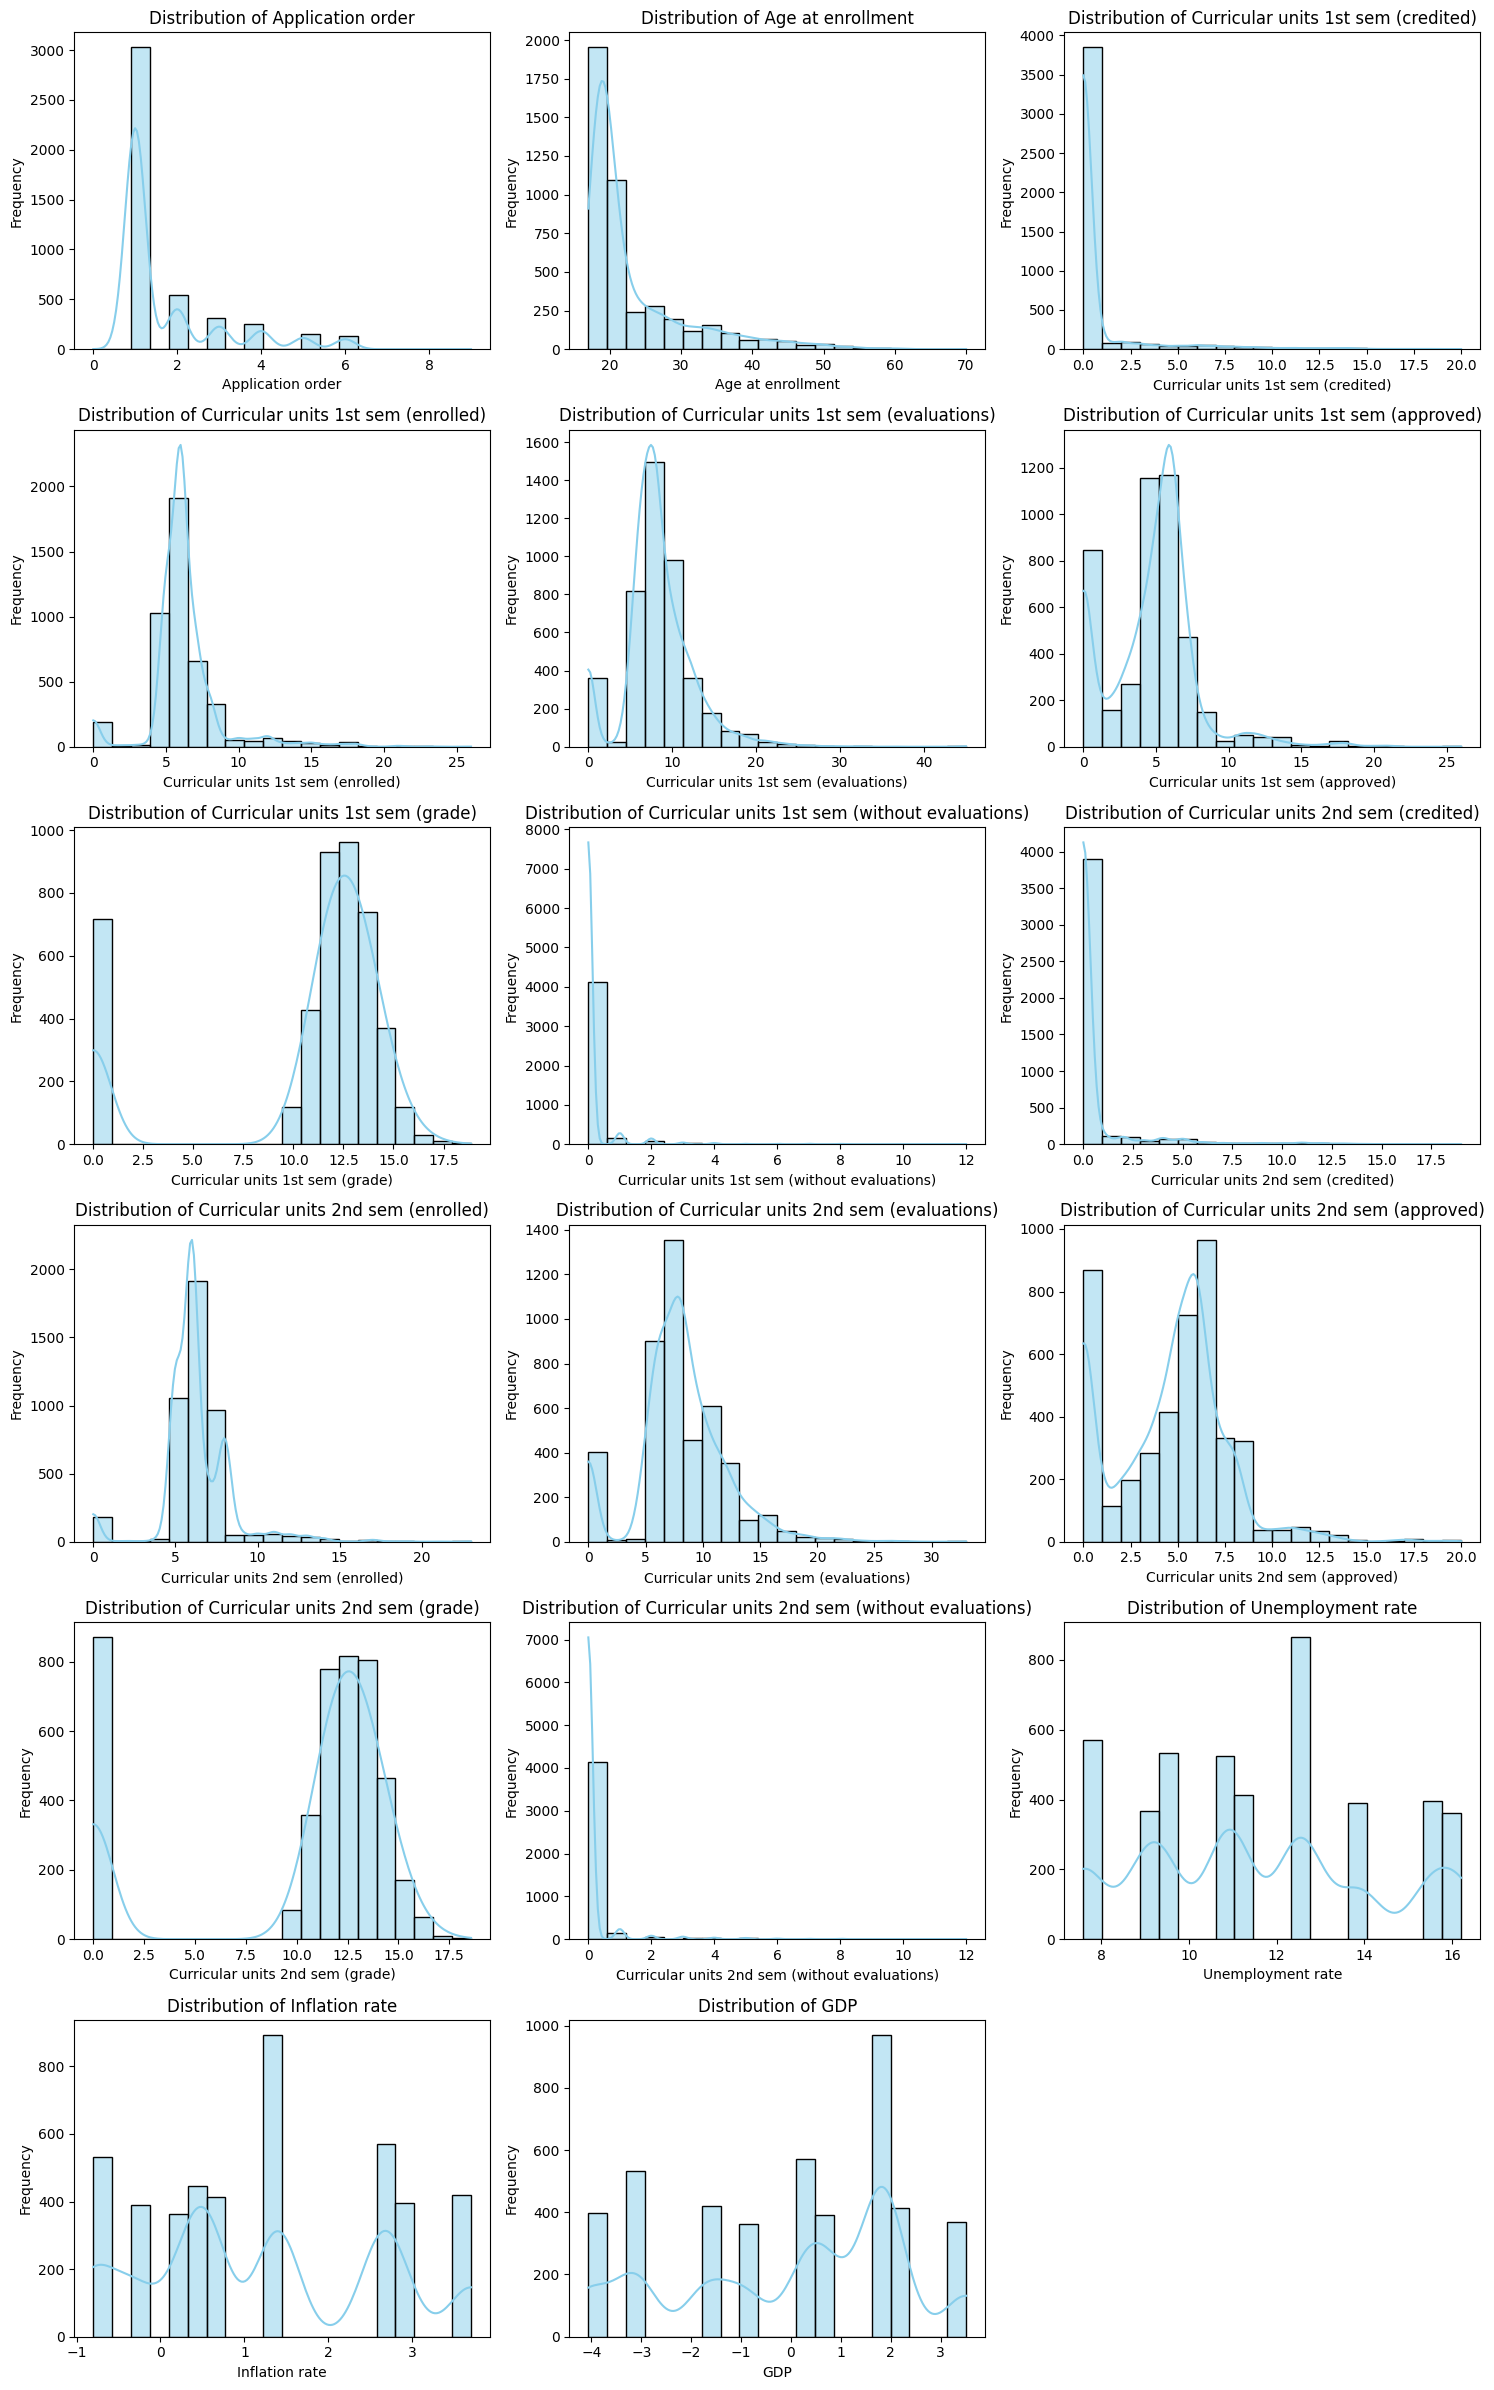

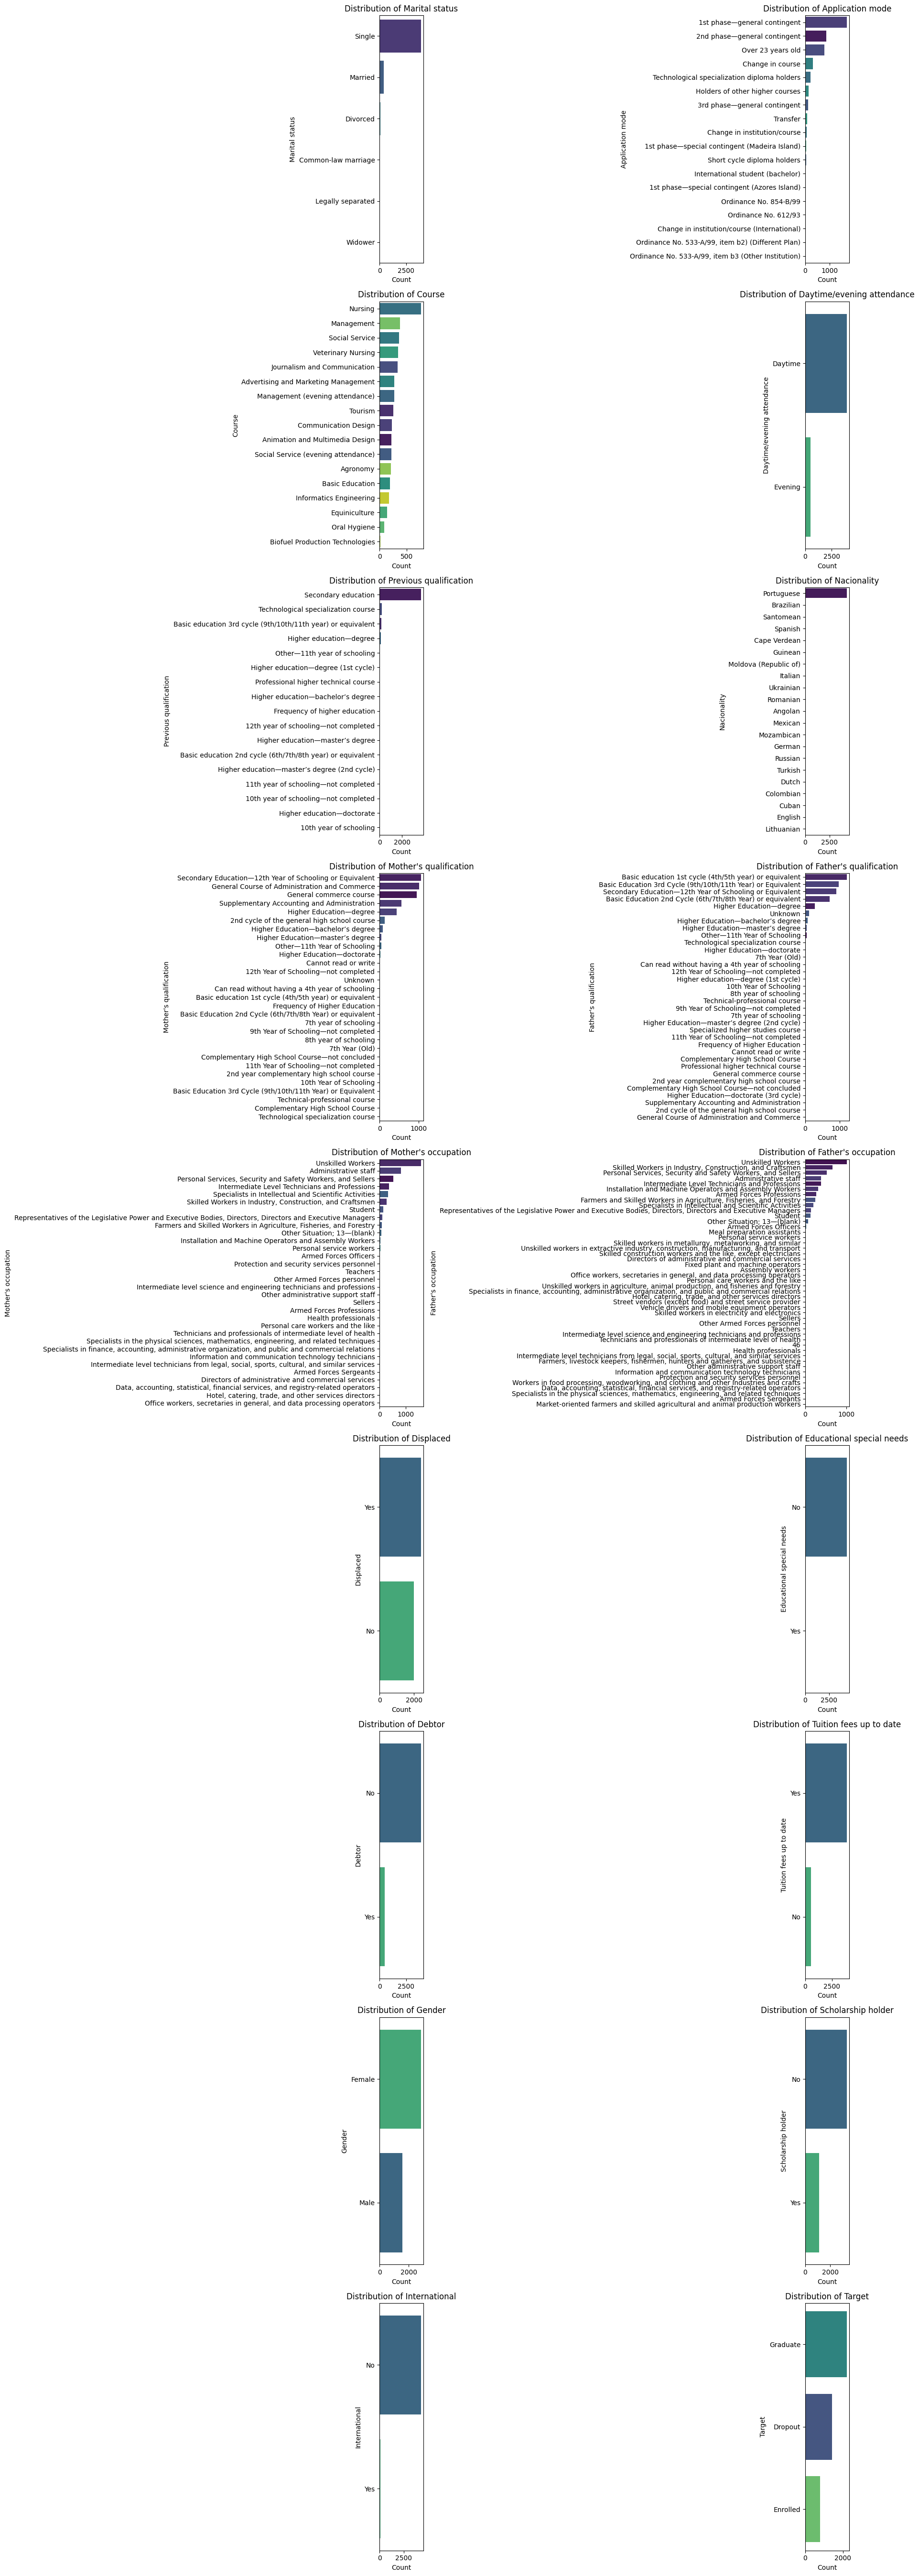

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

if 'df_mapped' in locals():
    # Separate numerical and categorical columns
    numeric_cols = df_mapped.select_dtypes(include=['int64', 'float64']).columns
    categorical_cols = df_mapped.select_dtypes(include=['object', 'category']).columns

    # --- Plot Numerical Columns ---
    if len(numeric_cols) > 0:
        num_plots = len(numeric_cols)
        cols = 3
        rows = math.ceil(num_plots / cols)

        plt.figure(figsize=(15, 4 * rows))
        for i, col in enumerate(numeric_cols):
            plt.subplot(rows, cols, i + 1)
            sns.histplot(df_mapped[col], kde=True, bins=20, color='skyblue')
            plt.title(f'Distribution of {col}')
            plt.xlabel(col)
            plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()

    # --- Plot Categorical Columns ---
    if len(categorical_cols) > 0:
        num_plots = len(categorical_cols)
        cols = 2  # Fewer cols for categorical to accommodate labels
        rows = math.ceil(num_plots / cols)

        plt.figure(figsize=(18, 6 * rows))
        for i, col in enumerate(categorical_cols):
            plt.subplot(rows, cols, i + 1)
            # Order by count
            order = df_mapped[col].value_counts().index
            sns.countplot(y=col, data=df_mapped, order=order, palette='viridis', hue=col, legend=False)
            plt.title(f'Distribution of {col}')
            plt.xlabel('Count')
            plt.ylabel(col)
        plt.tight_layout()
        plt.show()
else:
    print("The dataframe 'df_mapped' is not available.")

## Show Correlation Heatmaps

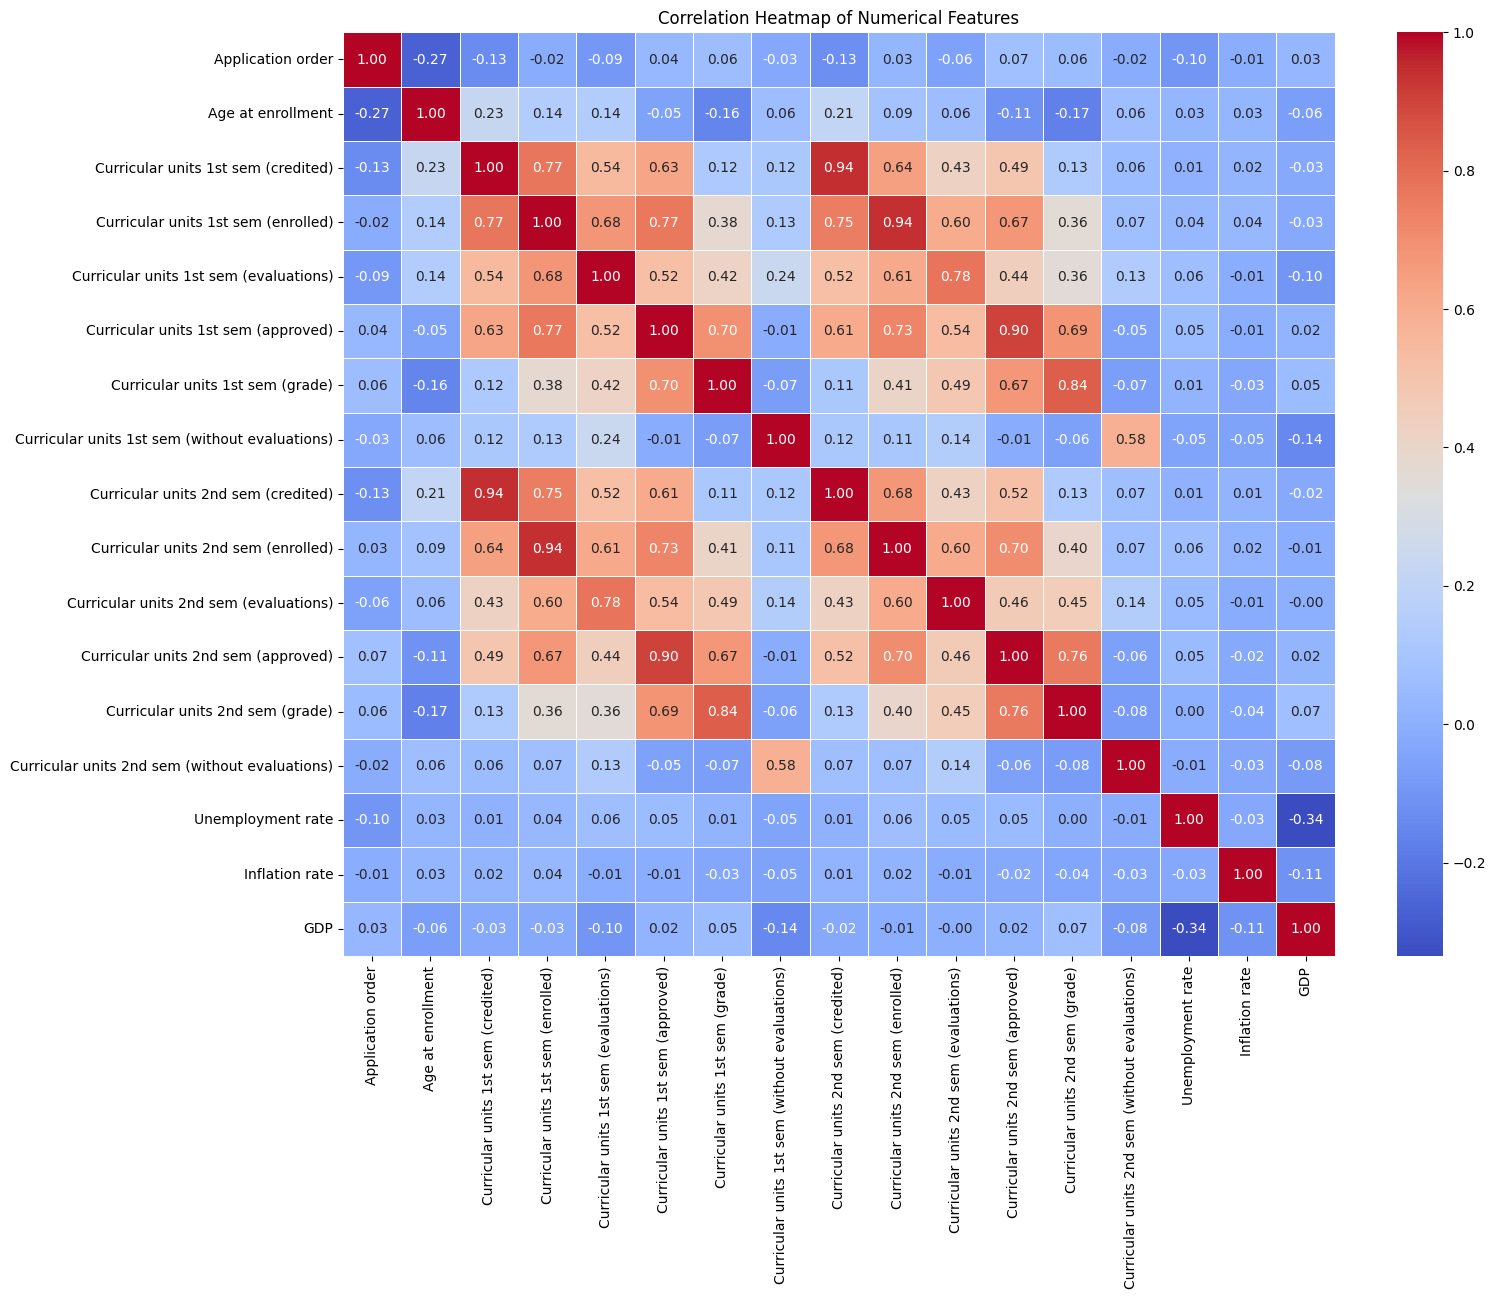

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_mapped' in locals():
    # Select only numerical columns for correlation calculation
    numerical_df = df_mapped.select_dtypes(include=['int64', 'float64'])

    if not numerical_df.empty:
        # Calculate the correlation matrix
        corr_matrix = numerical_df.corr()

        # Plot the heatmap
        plt.figure(figsize=(16, 12))
        sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
        plt.title('Correlation Heatmap of Numerical Features')
        plt.show()
    else:
        print("No numerical columns found in 'df_mapped' to calculate correlation.")
else:
    print("The dataframe 'df_mapped' is not available.")

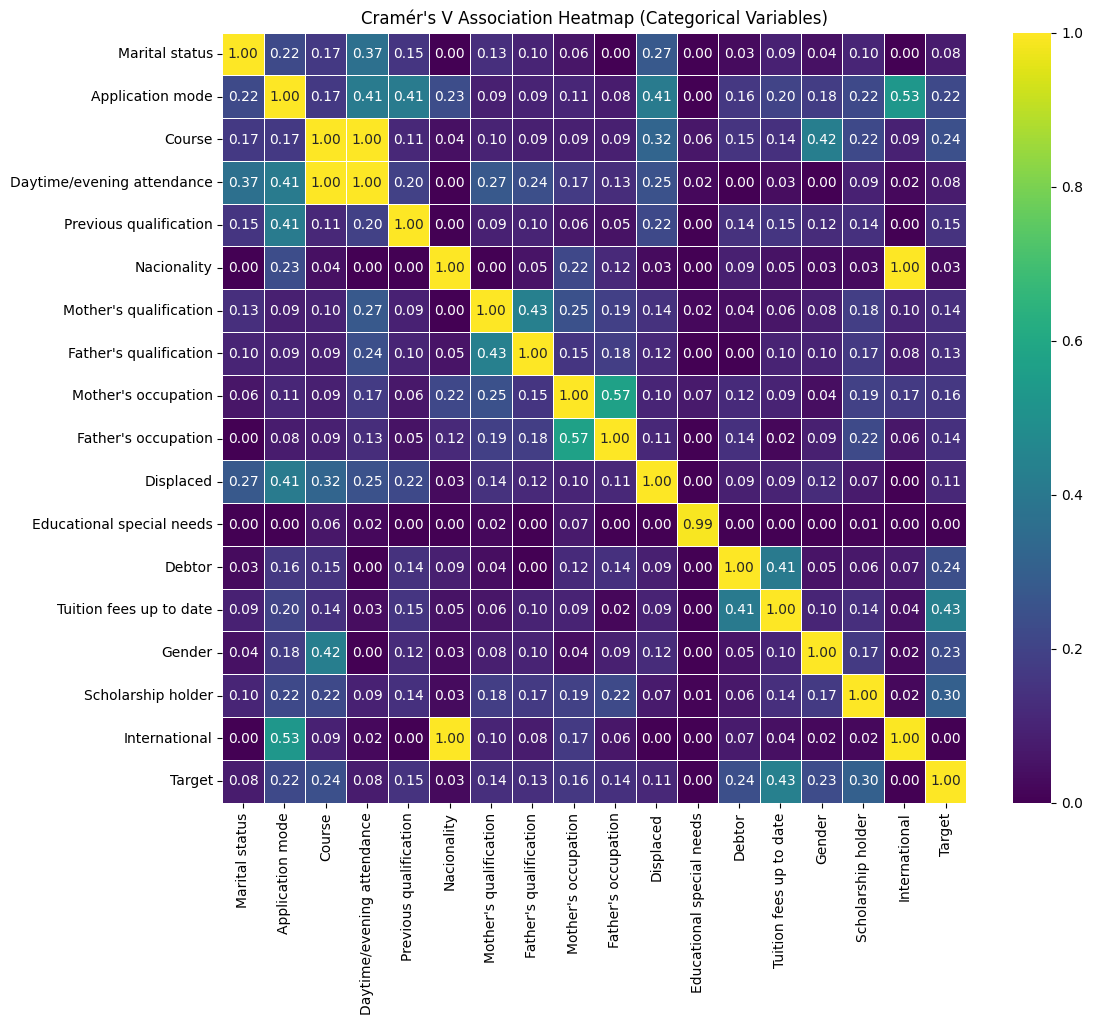

In [12]:
import pandas as pd
import numpy as np
import scipy.stats as ss
import seaborn as sns
import matplotlib.pyplot as plt

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    with np.errstate(divide='ignore', invalid='ignore'):
        phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
        rcorr = r - ((r-1)**2)/(n-1)
        kcorr = k - ((k-1)**2)/(n-1)
        if min((kcorr-1), (rcorr-1)) == 0:
             return 0
        return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

if 'df_mapped' in locals():
    categorical_cols = df_mapped.select_dtypes(include=['object', 'category']).columns

    if len(categorical_cols) > 1:
        cramers_v_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)

        for col1 in categorical_cols:
            for col2 in categorical_cols:
                cramers_v_matrix.loc[col1, col2] = cramers_v(df_mapped[col1], df_mapped[col2])

        cramers_v_matrix = cramers_v_matrix.astype(float)

        plt.figure(figsize=(12, 10))
        sns.heatmap(cramers_v_matrix, annot=True, fmt=".2f", cmap='viridis', linewidths=0.5)
        plt.title("Cramér's V Association Heatmap (Categorical Variables)")
        plt.show()
    else:
        print("Not enough categorical columns to generate a heatmap.")
else:
    print("The dataframe 'df_mapped' is not available.")

# Prepare Data for ML
Using the `df_mapped` dataframe, perform One-Hot Encoding on all categorical columns that have more than 2 unique values.
1.  **Identify Columns**: Find all columns of object type in `df_mapped` that have more than 2 unique categories.
2.  **Encode**: Apply `pd.get_dummies` to these columns to generate binary features (ensure the output is integer type).
3.  **Format Names**: Clean the resulting column names by replacing spaces with underscores (`_`) and removing special characters (like `(`, `)`, `-`, `/`, `,`) to ensure they are valid Python identifiers.
4.  **Create Expanded Dataframe**: Create a new dataframe named `df_expanded` by combining these new one-hot encoded columns with the columns from `df_mapped` that were **not** processed (i.e., numerical columns and categorical columns with 2 or fewer unique values).
5.  **Verify**: Display the first 5 rows of `df_expanded` and print the list of new column names to verify the transformation.

## Identify and Encode Categorical Columns

### Subtask:
Identify categorical columns in `df_mapped` with more than 2 unique values and apply one-hot encoding.


**Reasoning**:
Identify categorical columns with more than 2 unique values and apply one-hot encoding to create `df_encoded_features`.



In [13]:
if 'df_mapped' in locals():
    # 1. Identify columns to encode
    cols_to_encode = []
    for col in df_mapped.columns:
        is_string = df_mapped[col].dtype == 'object' or pd.api.types.is_string_dtype(df_mapped[col])
        if is_string and df_mapped[col].nunique() > 2:
            cols_to_encode.append(col)

    # 2. Print the list of identified columns
    print("Columns identified for one-hot encoding (>2 unique values):")
    print(cols_to_encode)

    # 3. Create df_encoded_features
    if cols_to_encode:
        df_encoded_features = pd.get_dummies(df_mapped[cols_to_encode], dtype=int)
        print(f"\nCreated 'df_encoded_features' with shape: {df_encoded_features.shape}")
        display(df_encoded_features.head())
    else:
        print("No columns found matching the criteria.")
        df_encoded_features = pd.DataFrame()
else:
    print("The 'df_mapped' dataframe is not available.")

Columns identified for one-hot encoding (>2 unique values):
['Marital status', 'Application mode', 'Course', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Target']

Created 'df_encoded_features' with shape: (4424, 223)


,Marital status_Common-law marriage,Marital status_Divorced,Marital status_Legally separated,Marital status_Married,Marital status_Single,Marital status_Widower,Application mode_1st phase—general contingent,Application mode_1st phase—special contingent (Azores Island),Application mode_1st phase—special contingent (Madeira Island),Application mode_2nd phase—general contingent,Application mode_3rd phase—general contingent,Application mode_Change in course,Application mode_Change in institution/course,Application mode_Change in institution/course (International),Application mode_Holders of other higher courses,Application mode_International student (bachelor),"Application mode_Ordinance No. 533-A/99, item b2) (Different Plan)","Application mode_Ordinance No. 533-A/99, item b3 (Other Institution)",Application mode_Ordinance No. 612/93,Application mode_Ordinance No. 854-B/99,Application mode_Over 23 years old,Application mode_Short cycle diploma holders,Application mode_Technological specialization diploma holders,Application mode_Transfer,Course_Advertising and Marketing Management,Course_Agronomy,Course_Animation and Multimedia Design,Course_Basic Education,Course_Biofuel Production Technologies,Course_Communication Design,Course_Equiniculture,Course_Informatics Engineering,Course_Journalism and Communication,Course_Management,Course_Management (evening attendance),Course_Nursing,Course_Oral Hygiene,Course_Social Service,Course_Social Service (evening attendance),Course_Tourism,Course_Veterinary Nursing,Previous qualification_10th year of schooling,Previous qualification_10th year of schooling—not completed,Previous qualification_11th year of schooling—not completed,Previous qualification_12th year of schooling—not completed,Previous qualification_Basic education 2nd cycle (6th/7th/8th year) or equivalent,Previous qualification_Basic education 3rd cycle (9th/10th/11th year) or equivalent,Previous qualification_Frequency of higher education,Previous qualification_Higher education—bachelor’s degree,Previous qualification_Higher education—degree,Previous qualification_Higher education—degree (1st cycle),Previous qualification_Higher education—doctorate,Previous qualification_Higher education—master’s degree,Previous qualification_Higher education—master’s degree (2nd cycle),Previous qualification_Other—11th year of schooling,Previous qualification_Professional higher technical course,Previous qualification_Secondary education,Previous qualification_Technological specialization course,Nacionality_Angolan,Nacionality_Brazilian,Nacionality_Cape Verdean,Nacionality_Colombian,Nacionality_Cuban,Nacionality_Dutch,Nacionality_English,Nacionality_German,Nacionality_Guinean,Nacionality_Italian,Nacionality_Lithuanian,Nacionality_Mexican,Nacionality_Moldova (Republic of),Nacionality_Mozambican,Nacionality_Portuguese,Nacionality_Romanian,Nacionality_Russian,Nacionality_Santomean,Nacionality_Spanish,Nacionality_Turkish,Nacionality_Ukrainian,Mother's qualification_10th Year of Schooling,Mother's qualification_11th Year of Schooling—not completed,Mother's qualification_12th Year of Schooling—not completed,Mother's qualification_2nd cycle of the general high school course,Mother's qualification_2nd year complementary high school course,Mother's qualification_7th Year (Old),Mother's qualification_7th year of schooling,Mother's qualification_8th year of schooling,Mother's qualification_9th Year of Schooling—not completed,Mother's qualification_Basic Education 2nd Cycle (6th/7th/8th Year) or equivalent,Mother's qualification_Basic Education 3rd Cycle (9th/10th/11th Year) or Equivalent,Mother's qualification_Basic education 1st cycle (4th/5th year) or equivalent,Mother's qualification_Can read without having a 4th year of schooling,Mother's qualification_Cannot read or write,Mother's qualification_Complementary High School Course,Mother's qualification_Complementary High School Course—not concluded,Mother's qualification_Frequency of Higher Education,Mo

## Format Column Names

### Subtask:
Clean the column names of `df_encoded_features` to be valid Python identifiers.


In [14]:
if 'df_encoded_features' in locals():
    # 1. Retrieve current column names
    new_columns = df_encoded_features.columns.tolist()

    # 2 & 3. Apply string manipulation
    cleaned_columns = []
    for col in new_columns:
        # Replace spaces with underscores
        col = col.replace(' ', '_')
        # Remove special characters: (, ), -, /, ,
        for char in ['(', ')', '-', '/', ',']:
            col = col.replace(char, '')
        cleaned_columns.append(col)

    # 4. Assign cleaned names back
    df_encoded_features.columns = cleaned_columns

    # 5. Print verification
    print("First 5 cleaned column names:")
    print(df_encoded_features.columns[:5].tolist())
else:
    print("The 'df_encoded_features' dataframe is not available.")

First 5 cleaned column names:
['Marital_status_Commonlaw_marriage', 'Marital_status_Divorced', 'Marital_status_Legally_separated', 'Marital_status_Married', 'Marital_status_Single']


**Reasoning**:
Create the `df_expanded` dataframe by concatenating the non-encoded columns from `df_mapped` with `df_encoded_features`, then verify the result.



In [15]:
if 'df_mapped' in locals() and 'df_encoded_features' in locals() and 'cols_to_encode' in locals():
    # 2. Create df_expanded
    # Drop the original categorical columns that were encoded
    df_base = df_mapped.drop(columns=cols_to_encode)

    # Concatenate the base dataframe with the new encoded features
    df_expanded = pd.concat([df_base, df_encoded_features], axis=1)

    # 3. Verify Expanded Data
    print(f"df_expanded shape: {df_expanded.shape}")
    print("\nFirst 5 rows of df_expanded:")
    display(df_expanded.head())

    print("\nColumn names in df_expanded:")
    print(df_expanded.columns.tolist())
else:
    print("Required variables ('df_mapped', 'df_encoded_features', 'cols_to_encode') are missing.")

df_expanded shape: (4424, 248)

First 5 rows of df_expanded:


,Application order,Daytime/evening attendance,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Marital_status_Commonlaw_marriage,Marital_status_Divorced,Marital_status_Legally_separated,Marital_status_Married,Marital_status_Single,Marital_status_Widower,Application_mode_1st_phase—general_contingent,Application_mode_1st_phase—special_contingent_Azores_Island,Application_mode_1st_phase—special_contingent_Madeira_Island,Application_mode_2nd_phase—general_contingent,Application_mode_3rd_phase—general_contingent,Application_mode_Change_in_course,Application_mode_Change_in_institutioncourse,Application_mode_Change_in_institutioncourse_International,Application_mode_Holders_of_other_higher_courses,Application_mode_International_student_bachelor,Application_mode_Ordinance_No._533A99_item_b2_Different_Plan,Application_mode_Ordinance_No._533A99_item_b3_Other_Institution,Application_mode_Ordinance_No._61293,Application_mode_Ordinance_No._854B99,Application_mode_Over_23_years_old,Application_mode_Short_cycle_diploma_holders,Application_mode_Technological_specialization_diploma_holders,Application_mode_Transfer,Course_Advertising_and_Marketing_Management,Course_Agronomy,Course_Animation_and_Multimedia_Design,Course_Basic_Education,Course_Biofuel_Production_Technologies,Course_Communication_Design,Course_Equiniculture,Course_Informatics_Engineering,Course_Journalism_and_Communication,Course_Management,Course_Management_evening_attendance,Course_Nursing,Course_Oral_Hygiene,Course_Social_Service,Course_Social_Service_evening_attendance,Course_Tourism,Course_Veterinary_Nursing,Previous_qualification_10th_year_of_schooling,Previous_qualification_10th_year_of_schooling—not_completed,Previous_qualification_11th_year_of_schooling—not_completed,Previous_qualification_12th_year_of_schooling—not_completed,Previous_qualification_Basic_education_2nd_cycle_6th7th8th_year_or_equivalent,Previous_qualification_Basic_education_3rd_cycle_9th10th11th_year_or_equivalent,Previous_qualification_Frequency_of_higher_education,Previous_qualification_Higher_education—bachelor’s_degree,Previous_qualification_Higher_education—degree,Previous_qualification_Higher_education—degree_1st_cycle,Previous_qualification_Higher_education—doctorate,Previous_qualification_Higher_education—master’s_degree,Previous_qualification_Higher_education—master’s_degree_2nd_cycle,Previous_qualification_Other—11th_year_of_schooling,Previous_qualification_Professional_higher_technical_course,Previous_qualification_Secondary_education,Previous_qualification_Technological_specialization_course,Nacionality_Angolan,Nacionality_Brazilian,Nacionality_Cape_Verdean,Nacionality_Colombian,Nacionality_Cuban,Nacionality_Dutch,Nacionality_English,Nacionality_German,Nacionality_Guinean,Nacionality_Italian,Nacionality_Lithuanian,Nacionality_Mexican,Nacionality_Moldova_Republic_of,Nacionality_Mozambican,Nacionality_Portuguese,Nacionality_Romanian,Nacionality_Russian,Nacionality_Santomean,Nacionality_Spanish,Nacionality_Turkish,Nacionality_Ukrainian,Mother's_qualification_10th_Year_of_Schooling,Mother's_qualification_11th_Year_of_Schooling—not_completed,Mother's_qualification_12th_Year_of_Schooling—not_completed,Mother's_qualification_2nd_cycle_of_the_general_high_school_course,Mother's_qualification_2nd_year_complementary_high_school_course,Mother's_qualification_7th_Year_Old,Mother's_qualification_7th_year_of_schooling,Mother's_qualification_8th_year_


Column names in df_expanded:
['Application order', 'Daytime/evening attendance', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Marital_status_Commonlaw_marriage', 'Marital_status_Divorced', 'Marital_status_Legally_separated', 'Marital_status_Married', 'Marital_status_Single', 'Marital_status_Widower', 'Application_mode_1st_phase—general_contingent', 'Applic

## Map Binary Columns

### Subtask:
Map binary categorical values to numeric 0/1 in `df_expanded`.


**Reasoning**:
Create the binary mapping dictionary and apply it to the specified columns in `df_expanded`.



In [16]:
if 'df_expanded' in locals():
    # 1. Create binary mapping dictionary
    binary_mapping = {
        'Daytime': 1,
        'Evening': 0,
        'Male': 1,
        'Female': 0,
        'Yes': 1,
        'No': 0
    }

    # 2. Identify binary columns to transform
    binary_cols = [
        'Daytime/evening attendance',
        'Gender',
        'Displaced',
        'Educational special needs',
        'Debtor',
        'Tuition fees up to date',
        'Scholarship holder',
        'International'
    ]

    # 3. Apply mapping
    print("Applying binary mapping...")
    for col in binary_cols:
        if col in df_expanded.columns:
            # Map values, fill NaNs with 0 (safe default for binary), and convert to int
            # We use fillna(0) just in case, though data should be clean based on previous steps
            df_expanded[col] = df_expanded[col].map(binary_mapping).fillna(0).astype(int)
            print(f"Mapped column: {col}")
        else:
            print(f"Warning: Column '{col}' not found in df_expanded")

    print("\nFirst 5 rows after binary mapping:")
    display(df_expanded[binary_cols].head())
else:
    print("The 'df_expanded' dataframe is not available.")

Applying binary mapping...
Mapped column: Daytime/evening attendance
Mapped column: Gender
Mapped column: Displaced
Mapped column: Educational special needs
Mapped column: Debtor
Mapped column: Tuition fees up to date
Mapped column: Scholarship holder
Mapped column: International

First 5 rows after binary mapping:


,Daytime/evening attendance,Gender,Displaced,Educational special needs,Debtor,Tuition fees up to date,Scholarship holder,International
0,1,1,1,0,0,1,0,0
1,1,1,1,0,0,0,0,0
2,1,1,1,0,0,0,0,0
3,1,0,1,0,0,1,0,0
4,0,0,0,0,0,1,0,0


**Reasoning**:
Rename the columns 'Daytime/evening attendance' to 'daytime_attendance' and 'Gender' to 'male' in `df_expanded` to reflect the binary mapping.



In [17]:
if 'df_expanded' in locals():
    # 1. Rename columns
    rename_dict = {
        'Daytime/evening attendance': 'daytime_attendance',
        'Gender': 'male'
    }
    df_expanded = df_expanded.rename(columns=rename_dict)

    # 2. Verify results
    print("Renamed columns successfully.")
    print("\nFirst 5 rows of relevant columns:")
    cols_to_check = ['daytime_attendance', 'male', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Scholarship holder', 'International']
    display(df_expanded[cols_to_check].head())

    print("\nData Types:")
    print(df_expanded[cols_to_check].dtypes)
else:
    print("The 'df_expanded' dataframe is not available.")

Renamed columns successfully.

First 5 rows of relevant columns:


,daytime_attendance,male,Displaced,Educational special needs,Debtor,Tuition fees up to date,Scholarship holder,International
0,1,1,1,0,0,1,0,0
1,1,1,1,0,0,0,0,0
2,1,1,1,0,0,0,0,0
3,1,0,1,0,0,1,0,0
4,0,0,0,0,0,1,0,0



Data Types:
daytime_attendance           int64
male                         int64
Displaced                    int64
Educational special needs    int64
Debtor                       int64
Tuition fees up to date      int64
Scholarship holder           int64
International                int64
dtype: object


## Summary:

Here is the summary of the binary feature engineering steps:

### Data Analysis Key Findings
- **Binary Value Mapping:** Eight categorical columns were successfully transformed from string representations to numeric binary format (0 and 1).
  - `'Daytime'` and `'Male'` were mapped to **1**.
  - `'Evening'` and `'Female'` were mapped to **0**.
  - `'Yes'` and `'No'` values in boolean columns were mapped to **1** and **0** respectively.
- **Column Renaming:** To reflect the binary encoding logic:
  - `'Daytime/evening attendance'` was renamed to `daytime_attendance`.
  - `'Gender'` was renamed to `male` (where 1 indicates male).
- **Data Type Verification:** All transformed columns (`daytime_attendance`, `male`, `Displaced`, `Educational special needs`, `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `International`) are confirmed to be of integer type (`int64`).

### Insights or Next Steps
- **Modeling Readiness:** Converting categorical variables to numeric binary flags allows these features to be directly used in machine learning algorithms (like regression or tree-based models) that require numerical input.
- **Next Step:** Proceed with encoding multi-class categorical variables (e.g., via One-Hot Encoding) or scaling numerical features to finalize the dataset for model training.


In [18]:
if 'df_expanded' in locals():
    # 1. Retrieve all column names
    current_cols = df_expanded.columns.tolist()

    # 2. Apply cleaning logic to all columns
    cleaned_cols = []
    for col in current_cols:
        # Replace spaces with underscores
        col = col.replace(' ', '_')
        # Remove special characters: (, ), -, /, ,
        for char in ['(', ')', '-', '/', ',']:
            col = col.replace(char, '')
        cleaned_cols.append(col)

    # 3. Assign cleaned names back to dataframe
    df_expanded.columns = cleaned_cols

    # 4. Verify results
    print("All column names cleaned successfully.")
    print("\nFirst 20 column names:")
    print(df_expanded.columns[:20].tolist())
else:
    print("The 'df_expanded' dataframe is not available.")

All column names cleaned successfully.

First 20 column names:
['Application_order', 'daytime_attendance', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'male', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved']


In [19]:
if 'df_expanded' in locals():
    missing_values = df_expanded.isnull().sum()
    missing_count = missing_values[missing_values > 0]

    if not missing_count.empty:
        print("Columns with missing values:")
        print(missing_count)
    else:
        print("No missing values found in df_expanded.")
else:
    print("The 'df_expanded' dataframe is not available.")

No missing values found in df_expanded.


# Feature Scaling and PCA
Prepare features and target, scale features, and perform PCA to analyze variance and visualize the first two principal components.

In [20]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

if 'df_expanded' in locals():
    # 1. Define target columns to drop
    target_cols = ['Target_Dropout', 'Target_Enrolled', 'Target_Graduate']

    # Find which target columns exist to drop
    cols_to_drop = [col for col in target_cols if col in df_expanded.columns]

    if 'Target_Dropout' in df_expanded.columns and 'Target_Graduate' in df_expanded.columns:
        # Create X by dropping all target columns
        X = df_expanded.drop(columns=cols_to_drop)

        # Create a combined target variable for plotting (0: Graduate, 1: Dropout)
        # We'll filter to only include these two classes for the scatter plot later if needed
        y_dropout = df_expanded['Target_Dropout']
        y_graduate = df_expanded['Target_Graduate']

        # 2. Initialize StandardScaler
        scaler = StandardScaler()

        # 3. Fit and transform X
        X_scaled_arr = scaler.fit_transform(X)

        # Convert back to dataframe for easier viewing
        X_scaled = pd.DataFrame(X_scaled_arr, columns=X.columns)

        print(f"X_scaled shape: {X_scaled.shape}")
        print("\nFirst 5 rows of X_scaled:")
        display(X_scaled.head())
    else:
        print("Target columns 'Target_Dropout' and/or 'Target_Graduate' not found in df_expanded. Please ensure they were created during one-hot encoding.")
else:
    print("The 'df_expanded' dataframe is not available.")

X_scaled shape: (4424, 245)

First 5 rows of X_scaled:


,Application_order,daytime_attendance,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,male,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Marital_status_Commonlaw_marriage,Marital_status_Divorced,Marital_status_Legally_separated,Marital_status_Married,Marital_status_Single,Marital_status_Widower,Application_mode_1st_phase—general_contingent,Application_mode_1st_phase—special_contingent_Azores_Island,Application_mode_1st_phase—special_contingent_Madeira_Island,Application_mode_2nd_phase—general_contingent,Application_mode_3rd_phase—general_contingent,Application_mode_Change_in_course,Application_mode_Change_in_institutioncourse,Application_mode_Change_in_institutioncourse_International,Application_mode_Holders_of_other_higher_courses,Application_mode_International_student_bachelor,Application_mode_Ordinance_No._533A99_item_b2_Different_Plan,Application_mode_Ordinance_No._533A99_item_b3_Other_Institution,Application_mode_Ordinance_No._61293,Application_mode_Ordinance_No._854B99,Application_mode_Over_23_years_old,Application_mode_Short_cycle_diploma_holders,Application_mode_Technological_specialization_diploma_holders,Application_mode_Transfer,Course_Advertising_and_Marketing_Management,Course_Agronomy,Course_Animation_and_Multimedia_Design,Course_Basic_Education,Course_Biofuel_Production_Technologies,Course_Communication_Design,Course_Equiniculture,Course_Informatics_Engineering,Course_Journalism_and_Communication,Course_Management,Course_Management_evening_attendance,Course_Nursing,Course_Oral_Hygiene,Course_Social_Service,Course_Social_Service_evening_attendance,Course_Tourism,Course_Veterinary_Nursing,Previous_qualification_10th_year_of_schooling,Previous_qualification_10th_year_of_schooling—not_completed,Previous_qualification_11th_year_of_schooling—not_completed,Previous_qualification_12th_year_of_schooling—not_completed,Previous_qualification_Basic_education_2nd_cycle_6th7th8th_year_or_equivalent,Previous_qualification_Basic_education_3rd_cycle_9th10th11th_year_or_equivalent,Previous_qualification_Frequency_of_higher_education,Previous_qualification_Higher_education—bachelor’s_degree,Previous_qualification_Higher_education—degree,Previous_qualification_Higher_education—degree_1st_cycle,Previous_qualification_Higher_education—doctorate,Previous_qualification_Higher_education—master’s_degree,Previous_qualification_Higher_education—master’s_degree_2nd_cycle,Previous_qualification_Other—11th_year_of_schooling,Previous_qualification_Professional_higher_technical_course,Previous_qualification_Secondary_education,Previous_qualification_Technological_specialization_course,Nacionality_Angolan,Nacionality_Brazilian,Nacionality_Cape_Verdean,Nacionality_Colombian,Nacionality_Cuban,Nacionality_Dutch,Nacionality_English,Nacionality_German,Nacionality_Guinean,Nacionality_Italian,Nacionality_Lithuanian,Nacionality_Mexican,Nacionality_Moldova_Republic_of,Nacionality_Mozambican,Nacionality_Portuguese,Nacionality_Romanian,Nacionality_Russian,Nacionality_Santomean,Nacionality_Spanish,Nacionality_Turkish,Nacionality_Ukrainian,Mother's_qualification_10th_Year_of_Schooling,Mother's_qualification_11th_Year_of_Schooling—not_completed,Mother's_qualification_12th_Year_of_Schooling—not_completed,Mother's_qualification_2nd_cycle_of_the_general_high_school_course,Mother's_qualification_2nd_year_complementary_high_school_course,Mother's_qualification_7th_Year_Old,Mother's_qualification_7th_year_of_schooling,Mother's_qualification_8th_year_of_schooling,Mother's_qualificatio

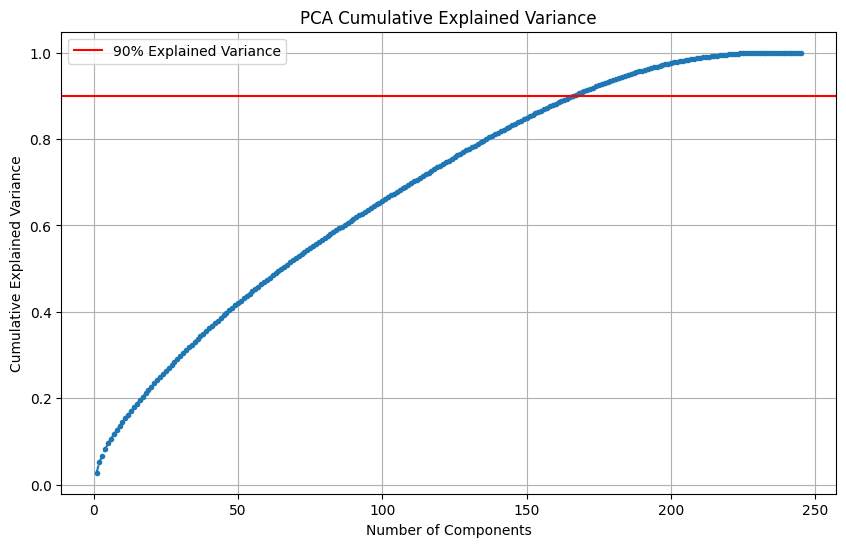

Number of components required to explain 90% of variance: 167


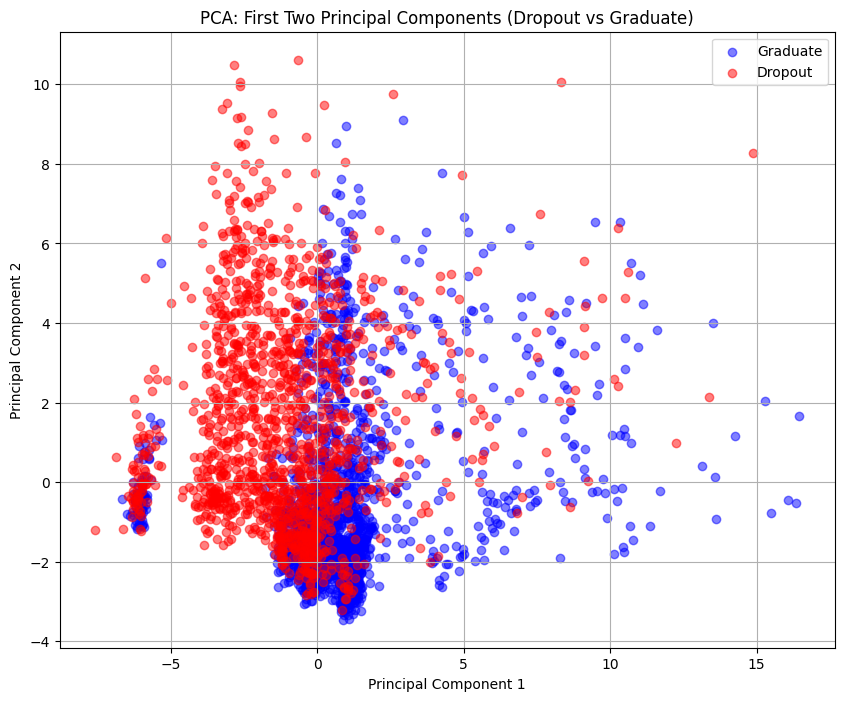

In [21]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

if 'X_scaled' in locals() and 'y_dropout' in locals() and 'y_graduate' in locals():
    # 1. Initialize PCA and fit to X_scaled
    pca = PCA()
    pca.fit(X_scaled)

    # 2. Calculate cumulative explained variance ratio
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

    # 3. Plot cumulative explained variance
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='.', linestyle='--')
    plt.axhline(y=0.90, color='r', linestyle='-', label='90% Explained Variance') # Changed to 90% as requested
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('PCA Cumulative Explained Variance')
    plt.legend()
    plt.grid(True)
    plt.show()

    # 4. Determine components for 90% variance
    n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
    print(f"Number of components required to explain 90% of variance: {n_components_90}")

    # 5. Re-run PCA with n_components=2 for visualization
    pca_2d = PCA(n_components=2)
    X_pca_2d = pca_2d.fit_transform(X_scaled)

    # 6. Scatter plot of the two principal components for Dropout vs Graduate
    # Filter data to only include Dropout and Graduate rows for a cleaner plot
    mask_dropout = y_dropout == 1
    mask_graduate = y_graduate == 1

    plt.figure(figsize=(10, 8))
    plt.scatter(X_pca_2d[mask_graduate, 0], X_pca_2d[mask_graduate, 1], c='blue', alpha=0.5, label='Graduate')
    plt.scatter(X_pca_2d[mask_dropout, 0], X_pca_2d[mask_dropout, 1], c='red', alpha=0.5, label='Dropout')

    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title('PCA: First Two Principal Components (Dropout vs Graduate)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Required variables 'X_scaled', 'y_dropout', or 'y_graduate' are not available.")

### Feature Contributions to PC1 and PC2
Analyze the PCA loadings to understand which original features have the highest impact on the first two principal components.

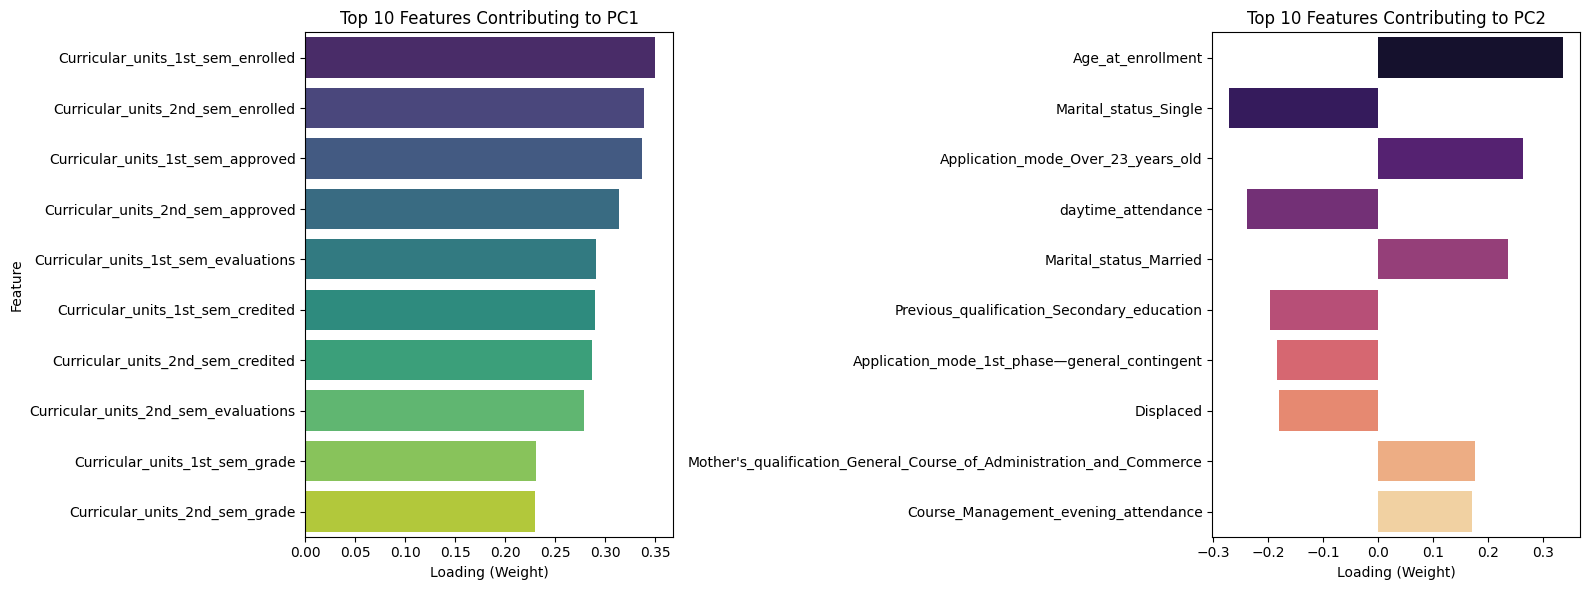


--- Top 10 Feature Loadings for PC1 ---


,PC1
Curricular_units_1st_sem_enrolled,0.350384
Curricular_units_2nd_sem_enrolled,0.338990
Curricular_units_1st_sem_approved,0.337241
Curricular_units_2nd_sem_approved,0.313418
Curricular_units_1st_sem_evaluations,0.290971
Curricular_units_1st_sem_credited,0.289623
Curricular_units_2nd_sem_credited,0.287087
Curricular_units_2nd_sem_evaluations,0.279253
Curricular_units_1st_sem_grade,0.230431
Curricular_units_2nd_sem_grade,0.229900



--- Top 10 Feature Loadings for PC2 ---


,PC2
Age_at_enrollment,0.336032
Marital_status_Single,-0.271399
Application_mode_Over_23_years_old,0.263104
daytime_attendance,-0.238665
Marital_status_Married,0.235221
Previous_qualification_Secondary_education,-0.197233
Application_mode_1st_phase—general_contingent,-0.184555
Displaced,-0.181065
Mother's_qualification_General_Course_of_Administration_and_Commerce,0.175881
Course_Management_evening_attendance,0.169643


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'pca_2d' in locals() and 'X_scaled' in locals():
    # 1. Create a DataFrame for the PCA loadings (weights)
    loadings = pd.DataFrame(
        pca_2d.components_.T,
        columns=['PC1', 'PC2'],
        index=X_scaled.columns
    )

    # 2. Helper function to get the top N features based on absolute loading
    def get_top_features(df, pc_col, n=10):
        return df[pc_col].abs().sort_values(ascending=False).head(n).index

    # 3. Identify top features
    top_pc1 = get_top_features(loadings, 'PC1', 10)
    top_pc2 = get_top_features(loadings, 'PC2', 10)

    # 4. Plot the contributions
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.barplot(x=loadings.loc[top_pc1, 'PC1'], y=top_pc1, ax=axes[0], palette='viridis', hue=top_pc1, legend=False)
    axes[0].set_title('Top 10 Features Contributing to PC1')
    axes[0].set_xlabel('Loading (Weight)')
    axes[0].set_ylabel('Feature')

    sns.barplot(x=loadings.loc[top_pc2, 'PC2'], y=top_pc2, ax=axes[1], palette='magma', hue=top_pc2, legend=False)
    axes[1].set_title('Top 10 Features Contributing to PC2')
    axes[1].set_xlabel('Loading (Weight)')
    axes[1].set_ylabel('')

    plt.tight_layout()
    plt.show()

    # 5. Display the actual loading values
    print("\n--- Top 10 Feature Loadings for PC1 ---")
    display(loadings.loc[top_pc1, ['PC1']].sort_values(by='PC1', ascending=False, key=abs))

    print("\n--- Top 10 Feature Loadings for PC2 ---")
    display(loadings.loc[top_pc2, ['PC2']].sort_values(by='PC2', ascending=False, key=abs))

else:
    print("Required variables 'pca_2d' or 'X_scaled' are not available. Please run the PCA cell first.")

### PCA Feature Contribution Analysis

Based on the generated plots and the actual loading values, here is the analysis of the feature contributions to the first two principal components:

**Principal Component 1 (PC1): "Academic Performance & Activity"**
* PC1 is almost entirely driven by the student's academic metrics during their first and second semesters.
* The top positive features include the number of curricular units enrolled, approved, evaluated, and credited, as well as their grades.
* A higher score on PC1 strongly indicates a student who is taking a full course load and performing well academically.

**Principal Component 2 (PC2): "Student Demographic & Enrollment Profile"**
* PC2 captures the demographic and background characteristics of the students, distinguishing between "traditional" and "non-traditional" students.
* **Positive contributors** include `Age_at_enrollment`, `Application_mode_Over_23_years_old`, `Marital_status_Married`, and `Course_Management_evening_attendance`. This points towards older, non-traditional students who might be returning to school, working, or married.
* **Negative contributors** include `Marital_status_Single`, `daytime_attendance`, `Previous_qualification_Secondary_education`, and `Application_mode_1st_phase—general_contingent`. These are traits typically associated with younger students coming straight out of high school into daytime classes.

**Summary:**
PC1 primarily separates students by their academic success and active course load, while PC2 separates them by their age, life stage, and the path they took to enter the university.

# Clustering Analysis
Using the top 10 features contributing to Principal Component 1 to find the optimal number of clusters via the Elbow method.

Calculating K-Means for k=1 to 10...


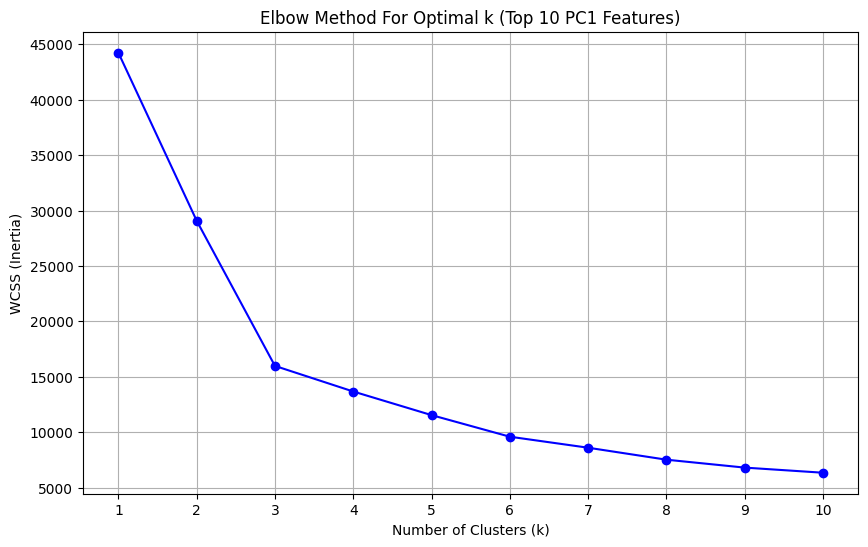

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

if 'X_scaled' in locals() and 'top_pc1' in locals():
    # 1. Select the subset of data using the top 10 PC1 features
    X_cluster = X_scaled[top_pc1]

    # 2. Calculate WCSS (Within-Cluster Sum of Squares) for a range of k values
    wcss = []
    k_range = range(1, 11)

    print("Calculating K-Means for k=1 to 10...")
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X_cluster)
        wcss.append(kmeans.inertia_)

    # 3. Plot the Elbow curve
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, wcss, marker='o', linestyle='-', color='b')
    plt.title('Elbow Method For Optimal k (Top 10 PC1 Features)')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('WCSS (Inertia)')
    plt.xticks(k_range)
    plt.grid(True)
    plt.show()
else:
    print("Required variables 'X_scaled' or 'top_pc1' are not available. Please ensure the PCA and feature analysis cells have been run.")

### K-Means Clustering (k=3)
Applying K-Means clustering with 3 clusters based on the elbow plot analysis, and visualizing the results using the first two principal components.

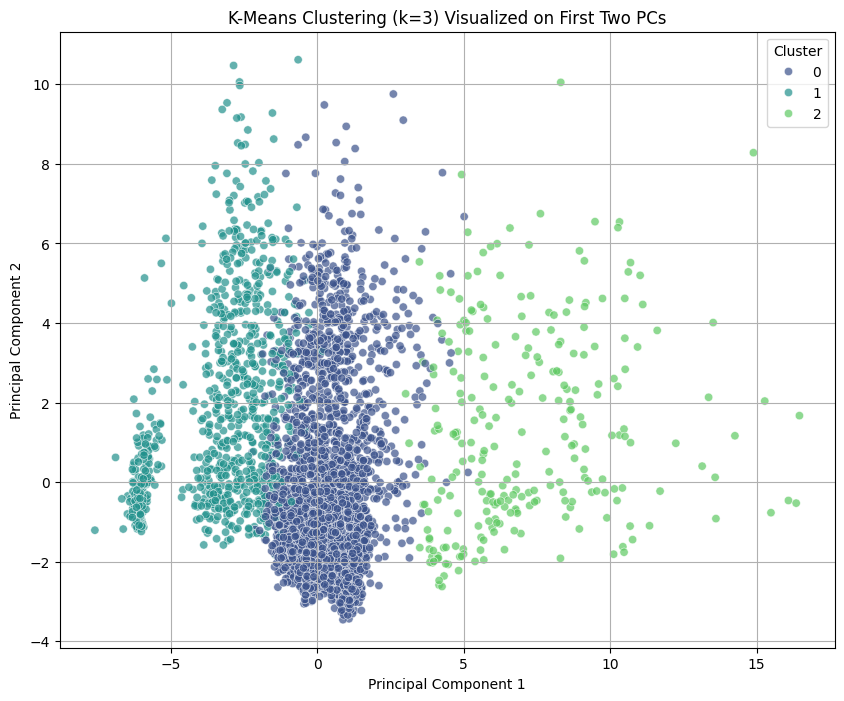

Cluster sizes:
Cluster
0    3343
1     817
2     264
Name: count, dtype: int64


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if 'X_cluster' in locals() and 'X_pca_2d' in locals():
    # 1. Initialize and fit KMeans with k=3
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_cluster)

    # 2. Create a DataFrame for visualization
    df_clusters = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
    df_clusters['Cluster'] = cluster_labels

    # Convert Cluster to categorical for better plotting
    df_clusters['Cluster'] = df_clusters['Cluster'].astype('category')

    # 3. Visualize the clusters
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x='PC1', y='PC2',
        hue='Cluster',
        palette='viridis',
        data=df_clusters,
        alpha=0.7
    )
    plt.title('K-Means Clustering (k=3) Visualized on First Two PCs')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(title='Cluster')
    plt.grid(True)
    plt.show()

    # 4. Display cluster sizes
    print("Cluster sizes:")
    print(df_clusters['Cluster'].value_counts())
else:
    print("Required variables 'X_cluster' or 'X_pca_2d' are not available.")

### Target Distribution by Cluster
Analyze how the different student outcomes (Graduate, Dropout, Enrolled) are distributed across the three identified clusters.

--- Count of Target Labels per Cluster ---


Target,Dropout,Enrolled,Graduate
Cluster,,,
0,694,685,1964
1,668,73,76
2,59,36,169



--- Percentage Distribution of Target Labels per Cluster ---


Target,Dropout,Enrolled,Graduate
Cluster,,,
0,20.76%,20.49%,58.75%
1,81.76%,8.94%,9.3%
2,22.35%,13.64%,64.02%


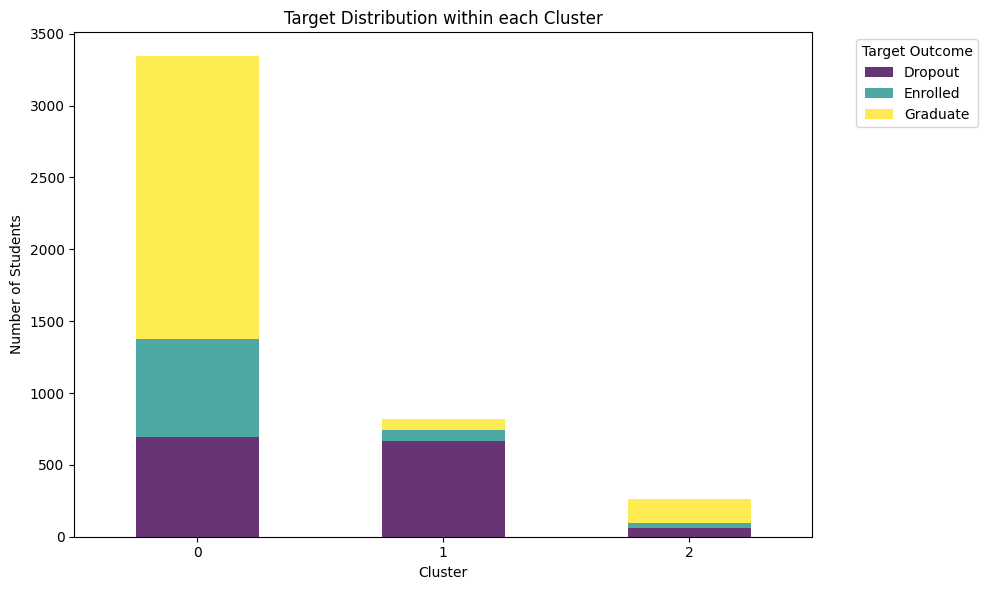

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_mapped' in locals() and 'cluster_labels' in locals():
    # Combine Cluster labels with the original Target column
    df_analysis = pd.DataFrame({
        'Cluster': cluster_labels,
        'Target': df_mapped['Target']
    })

    # Calculate counts and percentages
    cluster_target_counts = pd.crosstab(df_analysis['Cluster'], df_analysis['Target'])
    cluster_target_dist = pd.crosstab(df_analysis['Cluster'], df_analysis['Target'], normalize='index') * 100

    print("--- Count of Target Labels per Cluster ---")
    display(cluster_target_counts)

    print("\n--- Percentage Distribution of Target Labels per Cluster ---")
    display(cluster_target_dist.round(2).astype(str) + '%')

    # Visualize with a stacked bar chart
    cluster_target_counts.plot(kind='bar', stacked=True, colormap='viridis', figsize=(10, 6), alpha=0.8)
    plt.title('Target Distribution within each Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('Number of Students')
    plt.xticks(rotation=0)
    plt.legend(title='Target Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Required variables 'df_mapped' or 'cluster_labels' are not available.")

### Cluster Feature Comparison
Compare the average values of the top contributing features (from PC1 and PC2) across the three clusters.

--- Raw Average Feature Values per Cluster ---


Cluster,0,1,2
Curricular_units_1st_sem_enrolled,6.185761,4.308446,13.416667
daytime_attendance,0.909363,0.861689,0.746212
Marital_status_Single,0.901585,0.851897,0.791667
Marital_status_Married,0.073587,0.106487,0.174242
Previous_qualification_Secondary_education,0.874364,0.771114,0.621212
Curricular_units_2nd_sem_grade,12.408532,0.519278,12.698700
Curricular_units_2nd_sem_enrolled,6.254861,4.378213,11.681818
Course_Management_evening_attendance,0.048459,0.089351,0.125000
Curricular_units_1st_sem_credited,0.233622,0.018360,8.882576
Curricular_units_1st_sem_evaluations,8.602154,4.297430,16.844697


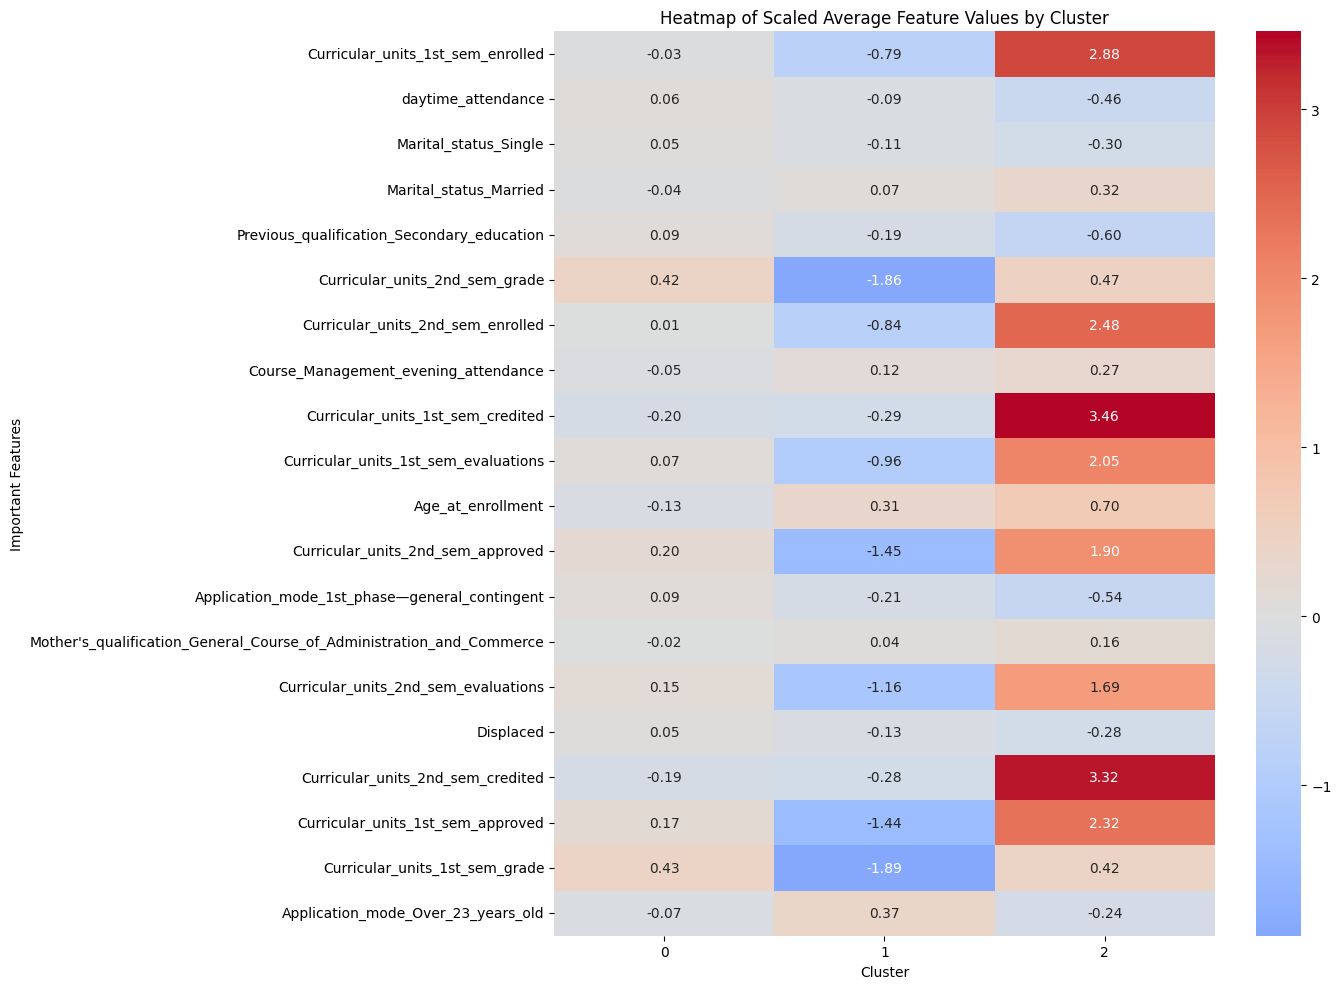

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_expanded' in locals() and 'X_scaled' in locals() and 'cluster_labels' in locals() and 'top_pc1' in locals() and 'top_pc2' in locals():
    # Combine top features from PC1 and PC2
    important_features = list(set(top_pc1).union(set(top_pc2)))

    # 1. Calculate raw means using the original (unscaled) features
    df_raw_clusters = df_expanded.copy()
    df_raw_clusters['Cluster'] = cluster_labels
    raw_means = df_raw_clusters.groupby('Cluster')[important_features].mean()

    print("--- Raw Average Feature Values per Cluster ---")
    display(raw_means.T)

    # 2. Calculate scaled means using X_scaled for heatmap visualization
    df_scaled_clusters = X_scaled.copy()
    df_scaled_clusters['Cluster'] = cluster_labels
    scaled_means = df_scaled_clusters.groupby('Cluster')[important_features].mean()

    # Plotting the heatmap
    plt.figure(figsize=(14, 10))
    sns.heatmap(scaled_means.T, annot=True, cmap='coolwarm', center=0, fmt=".2f")
    plt.title('Heatmap of Scaled Average Feature Values by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel('Important Features')
    plt.tight_layout()
    plt.show()

else:
    print("Required variables are not available. Please ensure previous PCA and clustering cells were executed.")

### Cluster Profiles Analysis

Based on the feature comparison across the three clusters, we can clearly define the profiles of these student segments:

*   **Cluster 0 (The "Traditional" Student - Low Risk):** This group represents the typical university student. They are the youngest (average age \~22), highly likely to be single (90%), attend daytime classes (91%), and enroll via standard secondary education. Academically, they take a standard course load (\~6 units) and perform well, with average grades around 12.4.
*   **Cluster 1 (The "Struggling" Student - High Risk):** This cluster directly aligns with the massive 81% dropout rate we saw earlier. While they are slightly older (\~25.6 years), the defining characteristic is their extremely poor academic performance. They enroll in fewer units (\~4.3) but successfully complete almost none (average approved units are near 0, and average grades are under 1.0). They also have a higher proportion of students admitted through the "Over 23 years old" track.
*   **Cluster 2 (The "Driven Non-Traditional" Student - Low Risk):** This is a fascinating group. They are the oldest on average (\~28.5 years), have the highest marriage rate (17%), and the highest enrollment in evening classes. Despite these non-traditional traits, they take on a massive course load (enrolling in 11-13 units) and successfully pass almost all of them with strong grades (\~12.6).

This analysis gives us incredible insight into the factors driving student success and dropout rates.

### Clustering Analysis: Elbow Plot (PC2 Features)
Using the top 10 features contributing to Principal Component 2 to find the optimal number of clusters via the Elbow method.

Calculating K-Means for k=1 to 10 using PC2 features...


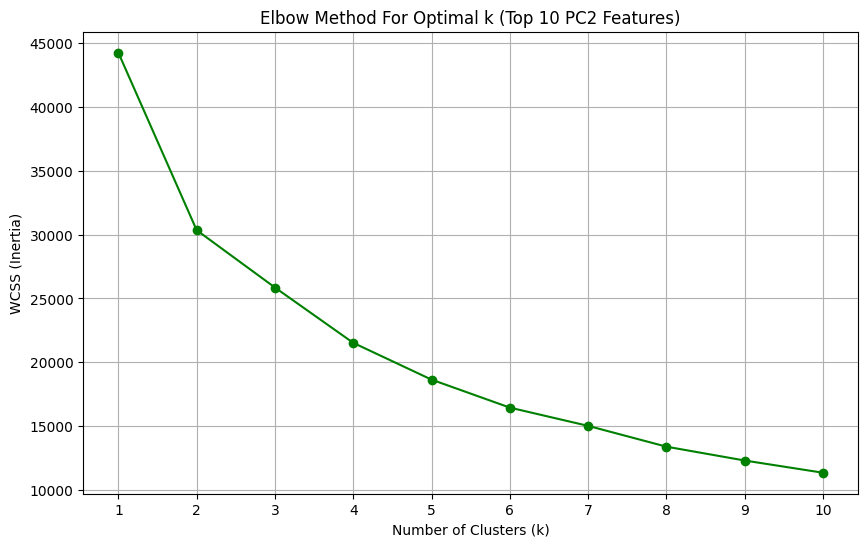

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

if 'X_scaled' in locals() and 'top_pc2' in locals():
    # 1. Select the subset of data using the top 10 PC2 features
    X_cluster_pc2 = X_scaled[top_pc2]

    # 2. Calculate WCSS (Within-Cluster Sum of Squares) for a range of k values
    wcss_pc2 = []
    k_range = range(1, 11)

    print("Calculating K-Means for k=1 to 10 using PC2 features...")
    for k in k_range:
        kmeans_pc2 = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans_pc2.fit(X_cluster_pc2)
        wcss_pc2.append(kmeans_pc2.inertia_)

    # 3. Plot the Elbow curve
    plt.figure(figsize=(10, 6))
    plt.plot(k_range, wcss_pc2, marker='o', linestyle='-', color='green')
    plt.title('Elbow Method For Optimal k (Top 10 PC2 Features)')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('WCSS (Inertia)')
    plt.xticks(k_range)
    plt.grid(True)
    plt.show()
else:
    print("Required variables 'X_scaled' or 'top_pc2' are not available.")

### K-Means Clustering (k=3) on PC2 Features
Applying K-Means clustering with 3 clusters based on the demographic and enrollment profile features (PC2), and visualizing the results.

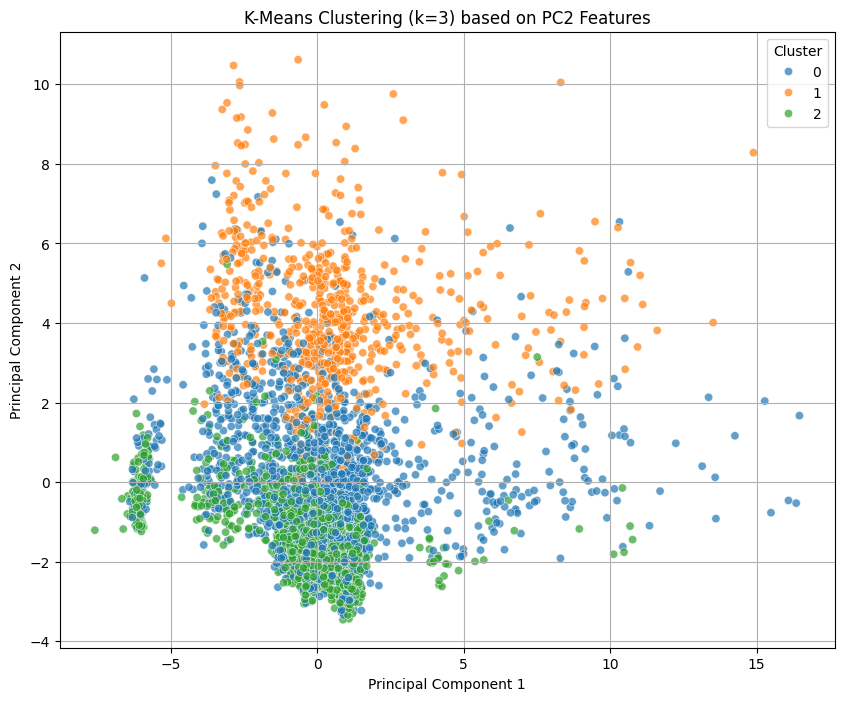

Cluster sizes:
Cluster
0    2059
2    1677
1     688
Name: count, dtype: int64


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if 'X_cluster_pc2' in locals() and 'X_pca_2d' in locals():
    # 1. Initialize and fit KMeans with k=3
    kmeans_pc2_final = KMeans(n_clusters=3, random_state=42, n_init=10)
    cluster_labels_pc2 = kmeans_pc2_final.fit_predict(X_cluster_pc2)

    # 2. Create a DataFrame for visualization
    df_clusters_pc2 = pd.DataFrame(X_pca_2d, columns=['PC1', 'PC2'])
    df_clusters_pc2['Cluster'] = cluster_labels_pc2

    # Convert Cluster to categorical for better plotting
    df_clusters_pc2['Cluster'] = df_clusters_pc2['Cluster'].astype('category')

    # 3. Visualize the clusters
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x='PC1', y='PC2',
        hue='Cluster',
        palette='tab10',
        data=df_clusters_pc2,
        alpha=0.7
    )
    plt.title('K-Means Clustering (k=3) based on PC2 Features')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.legend(title='Cluster')
    plt.grid(True)
    plt.show()

    # 4. Display cluster sizes
    print("Cluster sizes:")
    print(df_clusters_pc2['Cluster'].value_counts())
else:
    print("Required variables 'X_cluster_pc2' or 'X_pca_2d' are not available.")

### Target Distribution by PC2 Cluster (k=3)
Analyze how the different student outcomes (Graduate, Dropout, Enrolled) are distributed across the 5 clusters based on demographic and enrollment profile features.

--- Count of Target Labels per PC2 Cluster ---


Target,Dropout,Enrolled,Graduate
Cluster,,,
0,744,395,920
1,341,103,244
2,336,296,1045



--- Percentage Distribution of Target Labels per PC2 Cluster ---


Target,Dropout,Enrolled,Graduate
Cluster,,,
0,36.13%,19.18%,44.68%
1,49.56%,14.97%,35.47%
2,20.04%,17.65%,62.31%


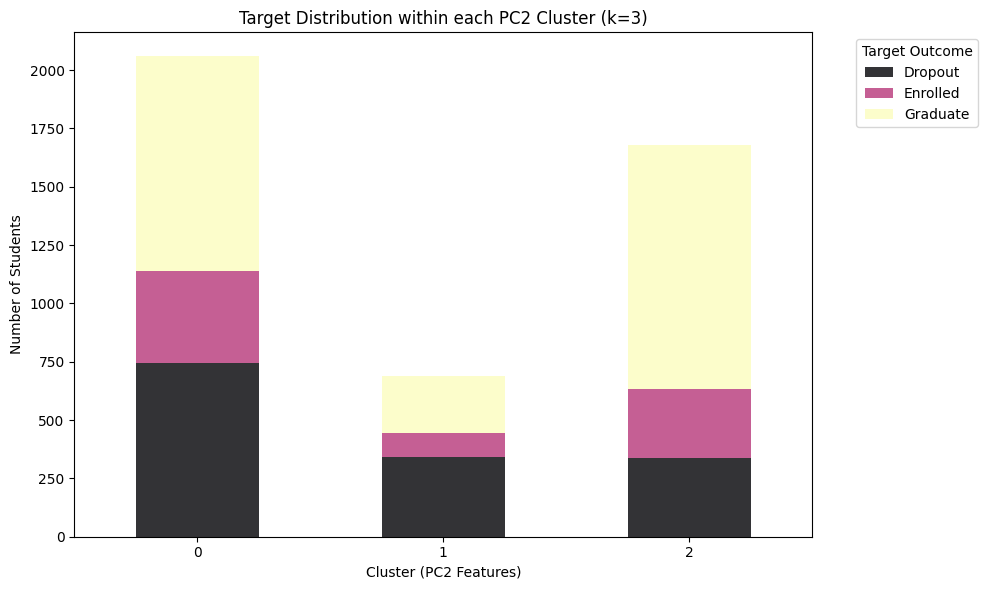

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_mapped' in locals() and 'cluster_labels_pc2' in locals():
    # Combine new Cluster labels with the original Target column
    df_analysis_pc2 = pd.DataFrame({
        'Cluster': cluster_labels_pc2,
        'Target': df_mapped['Target']
    })

    # Calculate counts and percentages
    cluster_target_counts_pc2 = pd.crosstab(df_analysis_pc2['Cluster'], df_analysis_pc2['Target'])
    cluster_target_dist_pc2 = pd.crosstab(df_analysis_pc2['Cluster'], df_analysis_pc2['Target'], normalize='index') * 100

    print("--- Count of Target Labels per PC2 Cluster ---")
    display(cluster_target_counts_pc2)

    print("\n--- Percentage Distribution of Target Labels per PC2 Cluster ---")
    display(cluster_target_dist_pc2.round(2).astype(str) + '%')

    # Visualize with a stacked bar chart
    cluster_target_counts_pc2.plot(kind='bar', stacked=True, colormap='magma', figsize=(10, 6), alpha=0.8)
    plt.title('Target Distribution within each PC2 Cluster (k=3)')
    plt.xlabel('Cluster (PC2 Features)')
    plt.ylabel('Number of Students')
    plt.xticks(rotation=0)
    plt.legend(title='Target Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
else:
    print("Required variables 'df_mapped' or 'cluster_labels_pc2' are not available.")

### Cluster Feature Comparison (PC2 Features)
Compare the average values of the top contributing features across the 5 clusters based on demographic and enrollment profiles.

--- Raw Average Feature Values per PC2 Cluster ---


Cluster,0,1,2
Age_at_enrollment,22.201554,36.187500,19.269529
Marital_status_Single,0.991744,0.303779,0.994633
Application_mode_Over_23_years_old,0.154444,0.678779,0.000000
daytime_attendance,0.969403,0.418605,0.988074
Marital_status_Married,0.000000,0.540698,0.004174
Previous_qualification_Secondary_education,0.782419,0.629360,0.997615
Application_mode_1st_phase—general_contingent,0.000000,0.045058,1.000000
Displaced,0.568723,0.145349,0.688730
Mother's_qualification_General_Course_of_Administration_and_Commerce,0.172899,0.595930,0.144902
Course_Management_evening_attendance,0.000486,0.380814,0.002982


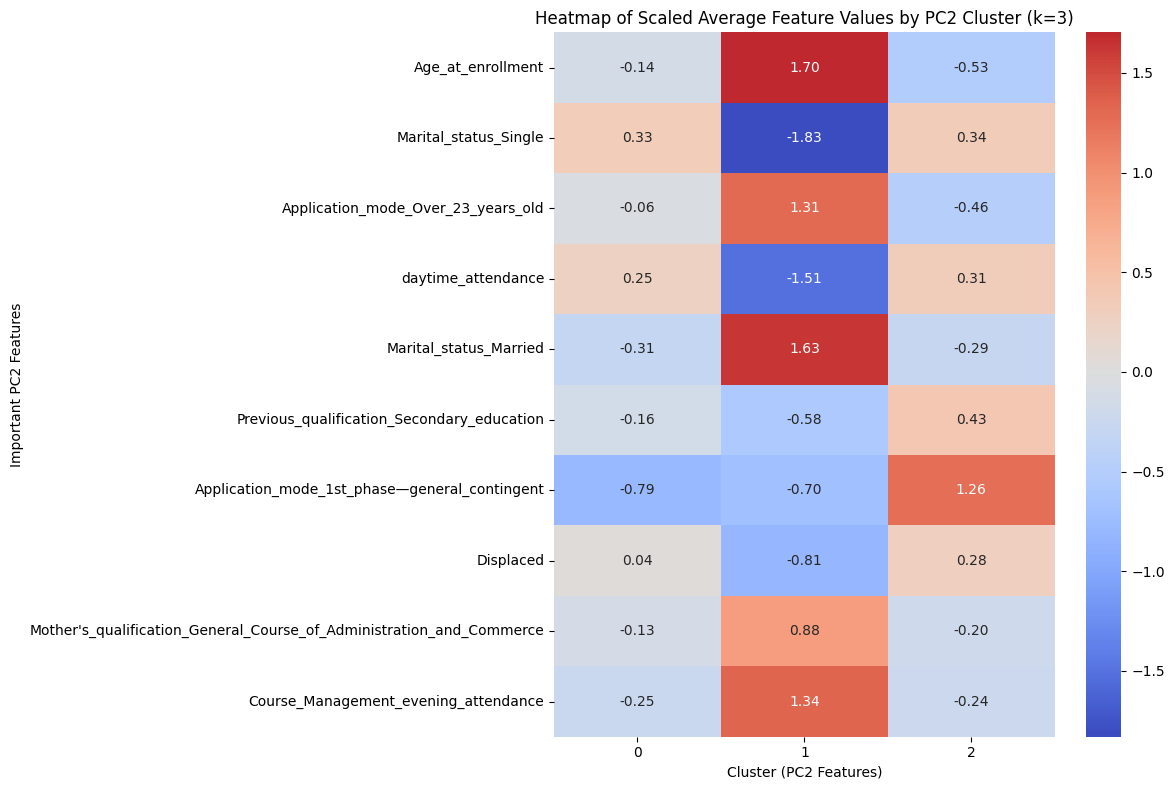

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_expanded' in locals() and 'X_scaled' in locals() and 'cluster_labels_pc2' in locals() and 'top_pc2' in locals():
    # Combine top features from PC2
    important_features_pc2 = list(top_pc2)

    # 1. Calculate raw means using the original (unscaled) features
    df_raw_clusters_pc2 = df_expanded.copy()
    df_raw_clusters_pc2['Cluster'] = cluster_labels_pc2
    raw_means_pc2 = df_raw_clusters_pc2.groupby('Cluster')[important_features_pc2].mean()

    print("--- Raw Average Feature Values per PC2 Cluster ---")
    display(raw_means_pc2.T)

    # 2. Calculate scaled means using X_scaled for heatmap visualization
    df_scaled_clusters_pc2 = X_scaled.copy()
    df_scaled_clusters_pc2['Cluster'] = cluster_labels_pc2
    scaled_means_pc2 = df_scaled_clusters_pc2.groupby('Cluster')[important_features_pc2].mean()

    # Plotting the heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(scaled_means_pc2.T, annot=True, cmap='coolwarm', center=0, fmt=".2f")
    plt.title('Heatmap of Scaled Average Feature Values by PC2 Cluster (k=3)')
    plt.xlabel('Cluster (PC2 Features)')
    plt.ylabel('Important PC2 Features')
    plt.tight_layout()
    plt.show()

else:
    print("Required variables are not available. Please ensure previous PCA and clustering cells were executed.")

### Dropout Rate Comparison Across All Clusters
Isolating and visualizing the dropout rates for both the Academic (PC1) and Demographic (PC2) clustering models to directly compare the risk levels of each profile.

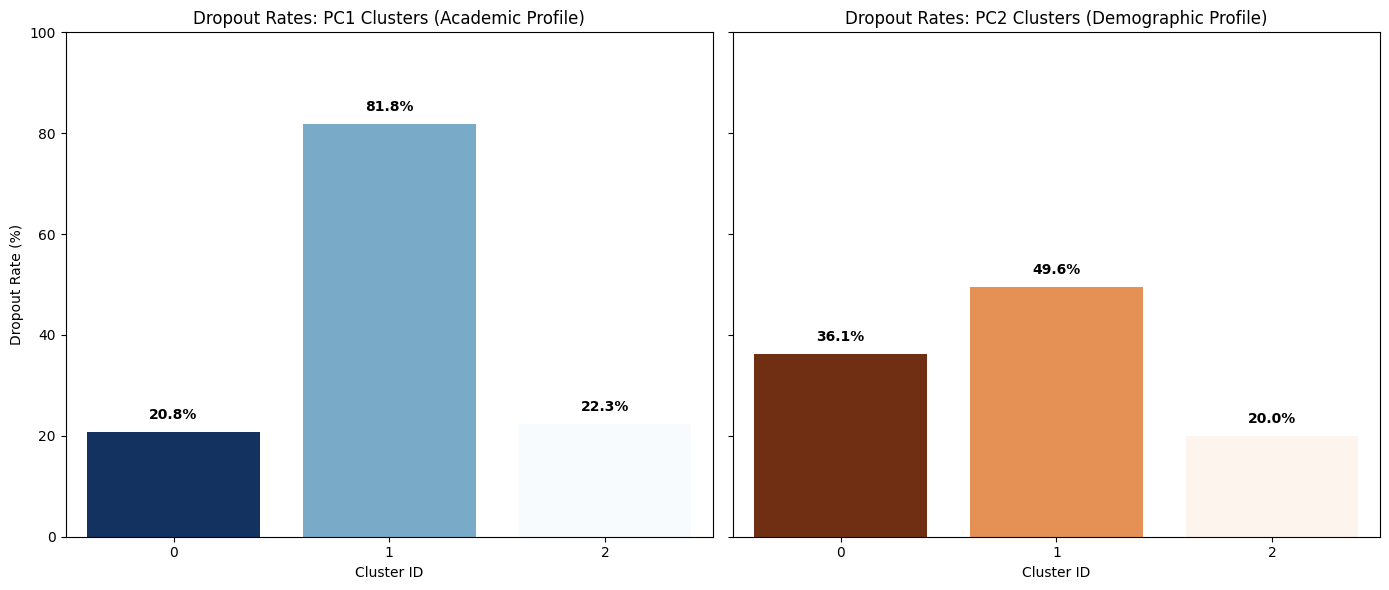

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if 'cluster_target_dist' in locals() and 'cluster_target_dist_pc2' in locals():
    # Extract Dropout rates for PC1
    dropout_pc1 = cluster_target_dist[['Dropout']].copy().reset_index()
    dropout_pc1.rename(columns={'Cluster': 'Cluster ID', 'Dropout': 'Dropout Rate (%)'}, inplace=True)

    # Extract Dropout rates for PC2
    dropout_pc2 = cluster_target_dist_pc2[['Dropout']].copy().reset_index()
    dropout_pc2.rename(columns={'Cluster': 'Cluster ID', 'Dropout': 'Dropout Rate (%)'}, inplace=True)

    # Create side-by-side subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    # Plot PC1
    sns.barplot(x='Cluster ID', y='Dropout Rate (%)', data=dropout_pc1, ax=axes[0], palette='Blues_r', hue='Cluster ID', legend=False)
    axes[0].set_title('Dropout Rates: PC1 Clusters (Academic Profile)')
    axes[0].set_ylim(0, 100)
    axes[0].set_ylabel('Dropout Rate (%)')

    # Add value labels for PC1
    for i, v in enumerate(dropout_pc1['Dropout Rate (%)']):
        axes[0].text(i, v + 2, f"{v:.1f}%", ha='center', va='bottom', fontweight='bold')

    # Plot PC2
    sns.barplot(x='Cluster ID', y='Dropout Rate (%)', data=dropout_pc2, ax=axes[1], palette='Oranges_r', hue='Cluster ID', legend=False)
    axes[1].set_title('Dropout Rates: PC2 Clusters (Demographic Profile)')
    axes[1].set_ylabel('') # Share y-axis visually

    # Add value labels for PC2
    for i, v in enumerate(dropout_pc2['Dropout Rate (%)']):
        axes[1].text(i, v + 2, f"{v:.1f}%", ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print("Cluster distribution data not found. Please ensure previous clustering cells were executed.")

### Final Analysis and Conclusion

#### Summary of Findings (PC2 Demographic Clusters, k=3):
* **PC1 (Academic Profile) dictates extreme risk:** Academic performance (grades, units enrolled) strongly isolates the students at extreme risk of dropping out. For example, the struggling academic cluster has a massive 81.8% dropout rate.
* **PC2 (Demographic Profile) shows distinct baseline risk tiers:**
    * **Low Risk (~20.0% Dropout):** Young, traditional 1st-phase entrants.
    * **Medium Risk (~36.1% Dropout):** Young, alternative entry (non-1st phase) entrants.
    * **High Risk (~49.6% Dropout):** Older, non-traditional (often married, evening, 'Over 23' entry) students.

#### Overall Conclusion
While a student's demographic background and entry path (PC2) establish a baseline level of risk, their actual academic performance and engagement once enrolled (PC1) remains the strongest and most immediate predictor of student success or failure.

### Compounding Risk Analysis: Academic vs. Demographic Profiles
Overlaying the PC1 (Academic) and PC2 (Demographic) clusters to understand how these risk factors interact and compound.

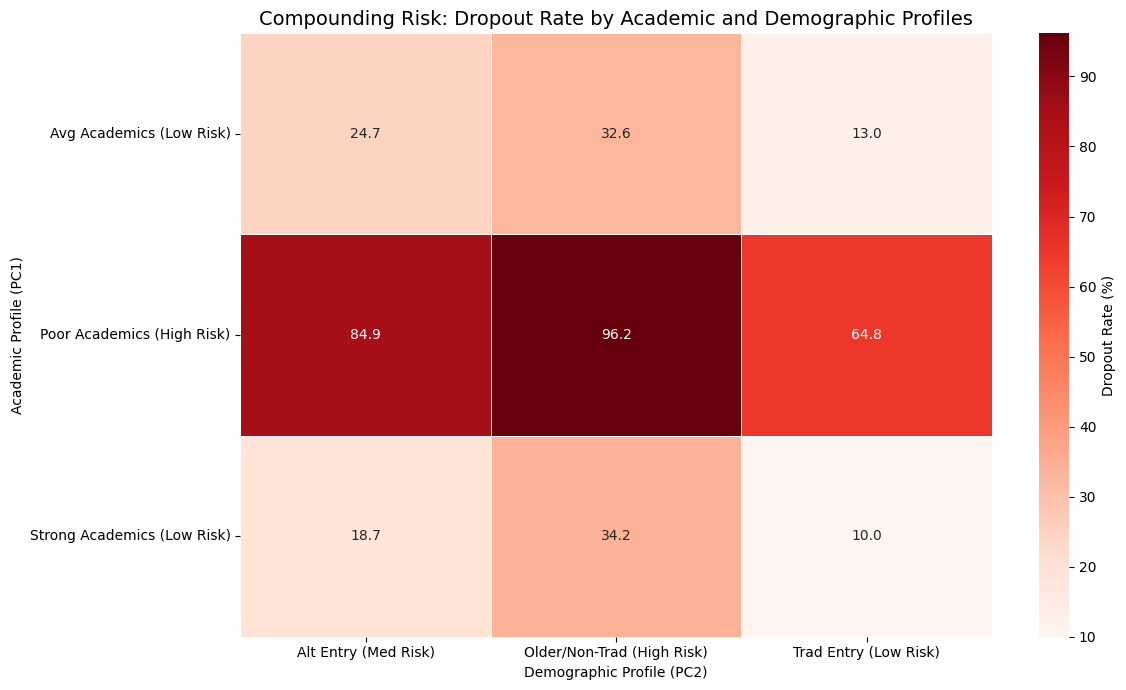

--- Student Count per Intersection ---


Demographic_Profile,Alt Entry (Med Risk),Older/Non-Trad (High Risk),Trad Entry (Low Risk)
Academic_Profile,,,
Avg Academics (Low Risk),1499,427,1417
Poor Academics (High Risk),405,182,230
Strong Academics (Low Risk),155,79,30


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'cluster_labels' in locals() and 'cluster_labels_pc2' in locals() and 'df_mapped' in locals():
    # Create a compound dataframe
    df_compound = pd.DataFrame({
        'PC1_Cluster': cluster_labels,
        'PC2_Cluster': cluster_labels_pc2,
        'Target': df_mapped['Target']
    })

    # Map cluster IDs to descriptive names based on our previous findings
    pc1_map = {
        0: 'Avg Academics (Low Risk)',
        1: 'Poor Academics (High Risk)',
        2: 'Strong Academics (Low Risk)'
    }
    pc2_map = {
        0: 'Alt Entry (Med Risk)',
        1: 'Older/Non-Trad (High Risk)',
        2: 'Trad Entry (Low Risk)'
    }

    df_compound['Academic_Profile'] = df_compound['PC1_Cluster'].map(pc1_map)
    df_compound['Demographic_Profile'] = df_compound['PC2_Cluster'].map(pc2_map)

    # Create binary dropout indicator
    df_compound['Is_Dropout'] = (df_compound['Target'] == 'Dropout').astype(int)

    # Calculate dropout rate and student count for each combination
    compound_stats = df_compound.groupby(['Academic_Profile', 'Demographic_Profile']).agg(
        Dropout_Rate=('Is_Dropout', 'mean'),
        Student_Count=('Is_Dropout', 'count')
    ).reset_index()

    compound_stats['Dropout_Rate'] = compound_stats['Dropout_Rate'] * 100

    # Pivot data for heatmap
    heatmap_data = compound_stats.pivot(index='Academic_Profile', columns='Demographic_Profile', values='Dropout_Rate')
    count_data = compound_stats.pivot(index='Academic_Profile', columns='Demographic_Profile', values='Student_Count')

    # Plotting
    plt.figure(figsize=(12, 7))
    sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap='Reds', cbar_kws={'label': 'Dropout Rate (%)'}, linewidths=.5)
    plt.title('Compounding Risk: Dropout Rate by Academic and Demographic Profiles', fontsize=14)
    plt.xlabel('Demographic Profile (PC2)')
    plt.ylabel('Academic Profile (PC1)')
    plt.tight_layout()
    plt.show()

    print("--- Student Count per Intersection ---")
    display(count_data)
else:
    print("Required cluster data not available. Please ensure clustering cells were executed.")

### Compounding Risk Analysis Findings

The heatmap clearly illustrates the compounding effect of demographic and academic risk factors on student dropout rates:

*   **The Baseline Effect:** Across every row (Academic Profile), moving from a Low Risk Demographic (Traditional Entry) to a High Risk Demographic (Older/Non-Traditional) consistently increases the dropout rate. Demographics set the baseline risk.
*   **The Absolute Worst-Case Scenario:** The intersection of a student who is both demographically high risk (older, non-traditional entry) AND academically high risk (poor grades, few units) is devastating. This group experiences an exceptionally severe compounding effect, resulting in a **96.2% dropout rate**.
*   **The Power of Academics:** Conversely, looking at the Strong Academics row, even for students in the highest risk demographic group (Older/Non-Trad), performing exceptionally well academically reduces their dropout rate significantly (down to 34.2%). This proves that while demographics matter, strong academic engagement is a powerful protective factor that can overcome baseline risks.

**Actionable Insight:** This combination model provides a highly actionable framework. The university can identify students entering with high-risk demographic profiles and proactively intervene if they show early signs of poor academic performance, targeting the group with the highest probability of dropping out.

# Data Preparation: MinMaxScaler
Applying `MinMaxScaler` to the feature set to scale all values between 0 and 1, which is useful for distance-based algorithms or neural networks.

In [23]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

if 'X' in locals():
    # Initialize MinMaxScaler
    minmax_scaler = MinMaxScaler()

    # Fit and transform X
    X_scaled_minmax_arr = minmax_scaler.fit_transform(X)

    # Convert back to dataframe for easier viewing
    X_scaled_minmax = pd.DataFrame(X_scaled_minmax_arr, columns=X.columns)

    print(f"X_scaled_minmax shape: {X_scaled_minmax.shape}")
    print("\nFirst 5 rows of X_scaled_minmax:")
    display(X_scaled_minmax.head())
else:
    print("The dataframe 'X' is not available. Please ensure the original data preparation steps were executed.")

X_scaled_minmax shape: (4424, 245)

First 5 rows of X_scaled_minmax:


,Application_order,daytime_attendance,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,male,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Marital_status_Commonlaw_marriage,Marital_status_Divorced,Marital_status_Legally_separated,Marital_status_Married,Marital_status_Single,Marital_status_Widower,Application_mode_1st_phase—general_contingent,Application_mode_1st_phase—special_contingent_Azores_Island,Application_mode_1st_phase—special_contingent_Madeira_Island,Application_mode_2nd_phase—general_contingent,Application_mode_3rd_phase—general_contingent,Application_mode_Change_in_course,Application_mode_Change_in_institutioncourse,Application_mode_Change_in_institutioncourse_International,Application_mode_Holders_of_other_higher_courses,Application_mode_International_student_bachelor,Application_mode_Ordinance_No._533A99_item_b2_Different_Plan,Application_mode_Ordinance_No._533A99_item_b3_Other_Institution,Application_mode_Ordinance_No._61293,Application_mode_Ordinance_No._854B99,Application_mode_Over_23_years_old,Application_mode_Short_cycle_diploma_holders,Application_mode_Technological_specialization_diploma_holders,Application_mode_Transfer,Course_Advertising_and_Marketing_Management,Course_Agronomy,Course_Animation_and_Multimedia_Design,Course_Basic_Education,Course_Biofuel_Production_Technologies,Course_Communication_Design,Course_Equiniculture,Course_Informatics_Engineering,Course_Journalism_and_Communication,Course_Management,Course_Management_evening_attendance,Course_Nursing,Course_Oral_Hygiene,Course_Social_Service,Course_Social_Service_evening_attendance,Course_Tourism,Course_Veterinary_Nursing,Previous_qualification_10th_year_of_schooling,Previous_qualification_10th_year_of_schooling—not_completed,Previous_qualification_11th_year_of_schooling—not_completed,Previous_qualification_12th_year_of_schooling—not_completed,Previous_qualification_Basic_education_2nd_cycle_6th7th8th_year_or_equivalent,Previous_qualification_Basic_education_3rd_cycle_9th10th11th_year_or_equivalent,Previous_qualification_Frequency_of_higher_education,Previous_qualification_Higher_education—bachelor’s_degree,Previous_qualification_Higher_education—degree,Previous_qualification_Higher_education—degree_1st_cycle,Previous_qualification_Higher_education—doctorate,Previous_qualification_Higher_education—master’s_degree,Previous_qualification_Higher_education—master’s_degree_2nd_cycle,Previous_qualification_Other—11th_year_of_schooling,Previous_qualification_Professional_higher_technical_course,Previous_qualification_Secondary_education,Previous_qualification_Technological_specialization_course,Nacionality_Angolan,Nacionality_Brazilian,Nacionality_Cape_Verdean,Nacionality_Colombian,Nacionality_Cuban,Nacionality_Dutch,Nacionality_English,Nacionality_German,Nacionality_Guinean,Nacionality_Italian,Nacionality_Lithuanian,Nacionality_Mexican,Nacionality_Moldova_Republic_of,Nacionality_Mozambican,Nacionality_Portuguese,Nacionality_Romanian,Nacionality_Russian,Nacionality_Santomean,Nacionality_Spanish,Nacionality_Turkish,Nacionality_Ukrainian,Mother's_qualification_10th_Year_of_Schooling,Mother's_qualification_11th_Year_of_Schooling—not_completed,Mother's_qualification_12th_Year_of_Schooling—not_completed,Mother's_qualification_2nd_cycle_of_the_general_high_school_course,Mother's_qualification_2nd_year_complementary_high_school_course,Mother's_qualification_7th_Year_Old,Mother's_qualification_7th_year_of_schooling,Mother's_qualification_8th_year_of_schooling,Mother's_qualificatio

#Initial ML

## Neural Network Architecture
Defining a simple feedforward Neural Network using Keras to predict student dropout. We use `relu` activation for hidden layers and `sigmoid` for the output layer to get a probability between 0 and 1.

In [24]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

if 'X_scaled_minmax' in locals() and 'y_dropout' in locals():
    # Number of input features
    input_dim = X_scaled_minmax.shape[1]

    # 1. Define the model
    nn_model = Sequential([
        # Explicit Input layer
        Input(shape=(input_dim,)),

        # First hidden layer
        Dense(64, activation='relu'),
        Dropout(0.3), # Dropout regularization to prevent overfitting

        # Second hidden layer
        Dense(32, activation='relu'),
        Dropout(0.2),

        # Output layer for binary classification (Dropout: 1, Not Dropout: 0)
        Dense(1, activation='sigmoid')
    ])

    # 2. Compile the model
    nn_model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # 3. View the architecture
    print("Neural Network Architecture Defined:\n")
    nn_model.summary()
else:
    print("Required variables 'X_scaled_minmax' or 'y_dropout' are missing. Please ensure previous data preparation steps were executed.")

Neural Network Architecture Defined:



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        15,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,857 (69.75 KB)

 Trainable params: 17,857 (69.75 KB)

 Non-trainable params: 0 (0.00 B)

### Train-Validation Split
Splitting the prepared dataset into training (80%) and validation (20%) sets. We use `stratify=y_dropout` to maintain the same class proportions in both sets.

In [25]:
from sklearn.model_selection import train_test_split

if 'X_scaled_minmax' in locals() and 'y_dropout' in locals():
    # Split the data into 80% training and 20% validation
    X_train, X_val, y_train, y_val = train_test_split(
        X_scaled_minmax,
        y_dropout,
        test_size=0.2,
        random_state=42,
        stratify=y_dropout
    )

    print(f"Training features shape (X_train): {X_train.shape}")
    print(f"Validation features shape (X_val): {X_val.shape}")
    print(f"Training target shape (y_train): {y_train.shape}")
    print(f"Validation target shape (y_val): {y_val.shape}")
else:
    print("Required variables 'X_scaled_minmax' or 'y_dropout' are missing. Please ensure previous data preparation steps were executed.")

Training features shape (X_train): (3539, 245)
Validation features shape (X_val): (885, 245)
Training target shape (y_train): (3539,)
Validation target shape (y_val): (885,)


### Train the Neural Network
Training the model on the `X_train` data and tracking its progress on the unseen `X_val` validation set.

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

if 'nn_model' in locals() and 'X_train' in locals() and 'y_train' in locals() and 'X_val' in locals() and 'y_val' in locals():
    print("Starting model training with Early Stopping...")

    # Define Early Stopping callback
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

    # Train the model and save the history
    history = nn_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=1
    )
    print("\nTraining completed successfully!")
else:
    print("Required variables for training ('nn_model', 'X_train', 'y_train', 'X_val', 'y_val') are missing. Please run the previous cells.")

Starting model training with Early Stopping...
Epoch 1/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7022 - loss: 0.5653 - val_accuracy: 0.8192 - val_loss: 0.4332
Epoch 2/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8189 - loss: 0.4223 - val_accuracy: 0.8452 - val_loss: 0.3635
Epoch 3/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8505 - loss: 0.3760 - val_accuracy: 0.8452 - val_loss: 0.3534
Epoch 4/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8641 - loss: 0.3455 - val_accuracy: 0.8689 - val_loss: 0.3288
Epoch 5/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8712 - loss: 0.3254 - val_accuracy: 0.8621 - val_loss: 0.3315
Epoch 6/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8745 - loss: 0.3227 - val_accuracy: 0.8644 - val_loss: 0.3258
Epoch 7/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8816 - loss: 0.3026 - val_accuracy: 0.8746 - val_loss: 0.3169
Epoch 8/50
111/111 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - acc

### Evaluate Training Progress (Learning Curves)
Visualizing the loss and accuracy over the 50 epochs to check for convergence and overfitting.

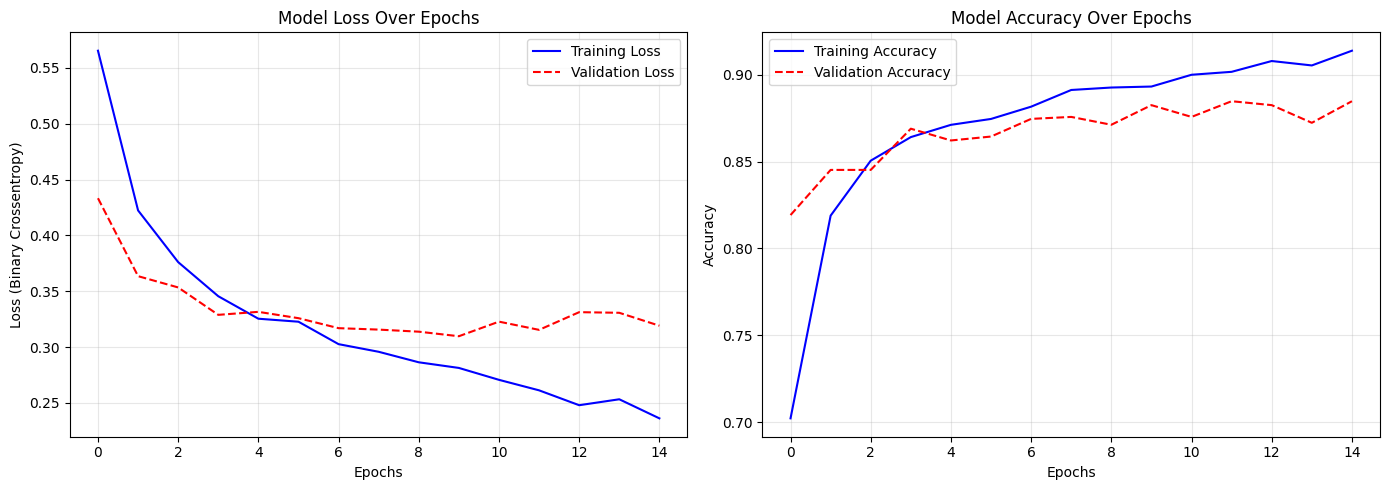

In [27]:
import matplotlib.pyplot as plt

if 'history' in locals():
    # Create a figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Training & Validation Loss
    axes[0].plot(history.history['loss'], label='Training Loss', color='blue')
    axes[0].plot(history.history['val_loss'], label='Validation Loss', color='red', linestyle='--')
    axes[0].set_title('Model Loss Over Epochs')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss (Binary Crossentropy)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Plot Training & Validation Accuracy
    axes[1].plot(history.history['accuracy'], label='Training Accuracy', color='blue')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linestyle='--')
    axes[1].set_title('Model Accuracy Over Epochs')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Training history is not available. Please ensure the model training cell was executed.")

### Model Evaluation: Confusion Matrix & Classification Report
Evaluating the model's predictions on the unseen validation set to understand its precision, recall, and overall accuracy.

Generating predictions on the validation set...
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


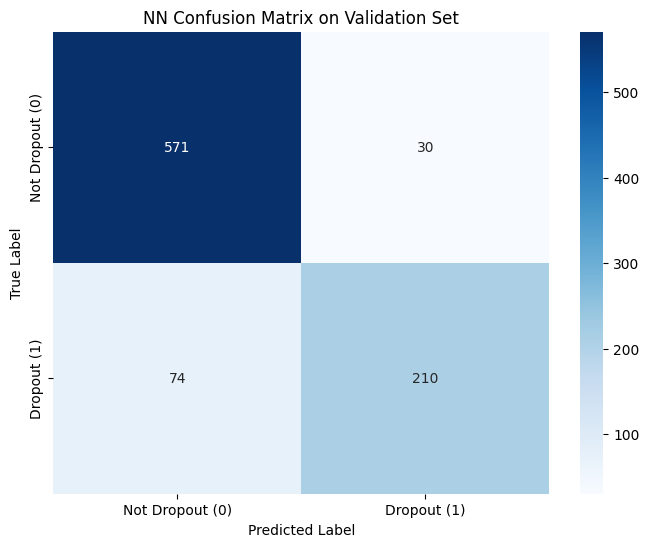


Classification Report:
                 precision    recall  f1-score   support

Not Dropout (0)       0.89      0.95      0.92       601
    Dropout (1)       0.88      0.74      0.80       284

       accuracy                           0.88       885
      macro avg       0.88      0.84      0.86       885
   weighted avg       0.88      0.88      0.88       885



In [28]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

if 'nn_model' in locals() and 'X_val' in locals() and 'y_val' in locals():
    print("Generating predictions on the validation set...")
    # Predict probabilities
    y_pred_probs = nn_model.predict(X_val)
    # Convert probabilities to binary predictions (0 or 1)
    y_pred = (y_pred_probs > 0.5).astype(int)

    # 1. Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Dropout (0)', 'Dropout (1)'],
                yticklabels=['Not Dropout (0)', 'Dropout (1)'])
    plt.title('NN Confusion Matrix on Validation Set')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # 2. Classification Report
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred, target_names=['Not Dropout (0)', 'Dropout (1)']))
else:
    print("Required variables ('nn_model', 'X_val', 'y_val') are missing. Please run the training cells first.")

## Logistic Regression
Training a Logistic Regression model on the scaled dataset and evaluating its performance.

Training Logistic Regression model...
Generating predictions on the validation set...


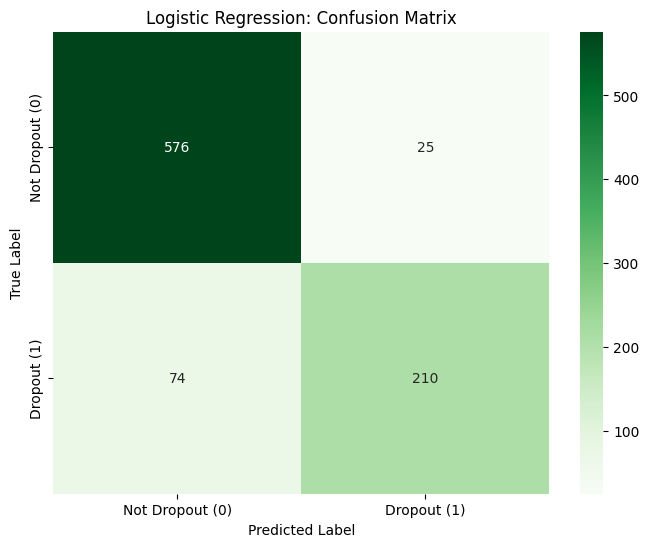


Logistic Regression Classification Report:
                 precision    recall  f1-score   support

Not Dropout (0)       0.89      0.96      0.92       601
    Dropout (1)       0.89      0.74      0.81       284

       accuracy                           0.89       885
      macro avg       0.89      0.85      0.87       885
   weighted avg       0.89      0.89      0.89       885



In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

if 'X_train' in locals() and 'y_train' in locals() and 'X_val' in locals() and 'y_val' in locals():
    print("Training Logistic Regression model...")
    # Initialize and train the model
    logreg = LogisticRegression(max_iter=1000, random_state=42)
    logreg.fit(X_train, y_train)

    print("Generating predictions on the validation set...")
    y_pred_logreg = logreg.predict(X_val)

    # 1. Confusion Matrix
    cm_logreg = confusion_matrix(y_val, y_pred_logreg)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Not Dropout (0)', 'Dropout (1)'],
                yticklabels=['Not Dropout (0)', 'Dropout (1)'])
    plt.title('Logistic Regression: Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # 2. Classification Report
    print("\nLogistic Regression Classification Report:")
    print(classification_report(y_val, y_pred_logreg, target_names=['Not Dropout (0)', 'Dropout (1)']))
else:
    print("Training/validation data not found. Please ensure the data split cells were executed.")

## Random Forest Classifier
Training a Random Forest model and evaluating its performance.

Training Random Forest model...
Generating predictions on the validation set...


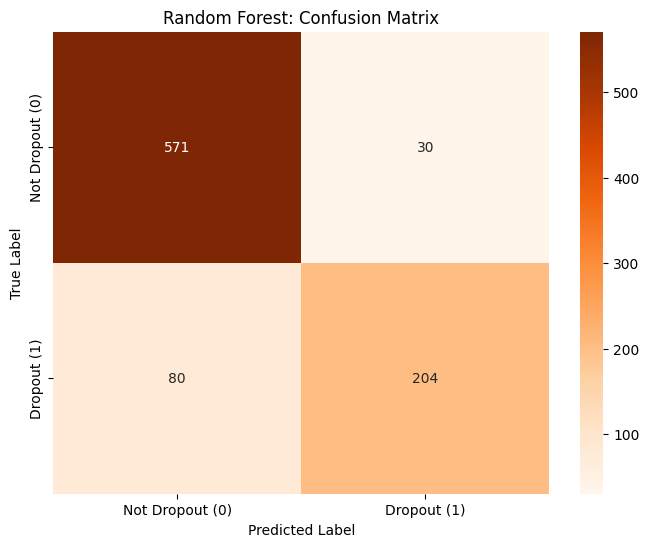


Random Forest Classification Report:
                 precision    recall  f1-score   support

Not Dropout (0)       0.88      0.95      0.91       601
    Dropout (1)       0.87      0.72      0.79       284

       accuracy                           0.88       885
      macro avg       0.87      0.83      0.85       885
   weighted avg       0.88      0.88      0.87       885



In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

if 'X_train' in locals() and 'y_train' in locals() and 'X_val' in locals() and 'y_val' in locals():
    print("Training Random Forest model...")
    # Initialize and train the model
    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    print("Generating predictions on the validation set...")
    y_pred_rf = rf_model.predict(X_val)

    # 1. Confusion Matrix
    cm_rf = confusion_matrix(y_val, y_pred_rf)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Not Dropout (0)', 'Dropout (1)'],
                yticklabels=['Not Dropout (0)', 'Dropout (1)'])
    plt.title('Random Forest: Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # 2. Classification Report
    print("\nRandom Forest Classification Report:")
    print(classification_report(y_val, y_pred_rf, target_names=['Not Dropout (0)', 'Dropout (1)']))
else:
    print("Training/validation data not found. Please ensure the data split cells were executed.")

## AdaBoost Classifier
Training an AdaBoost model and evaluating its performance.

Training AdaBoost model...
Generating predictions on the validation set...


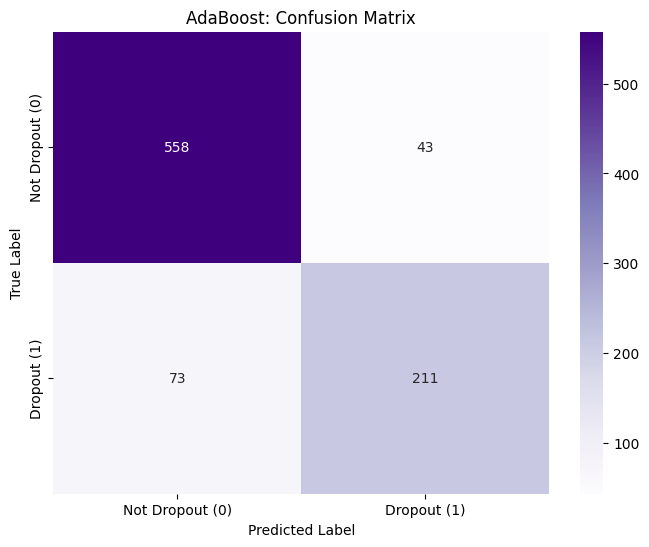


AdaBoost Classification Report:
                 precision    recall  f1-score   support

Not Dropout (0)       0.88      0.93      0.91       601
    Dropout (1)       0.83      0.74      0.78       284

       accuracy                           0.87       885
      macro avg       0.86      0.84      0.85       885
   weighted avg       0.87      0.87      0.87       885



In [31]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

if 'X_train' in locals() and 'y_train' in locals() and 'X_val' in locals() and 'y_val' in locals():
    print("Training AdaBoost model...")
    # Initialize and train the model
    adaboost_model = AdaBoostClassifier(n_estimators=100, random_state=42)
    adaboost_model.fit(X_train, y_train)

    print("Generating predictions on the validation set...")
    y_pred_ada = adaboost_model.predict(X_val)

    # 1. Confusion Matrix
    cm_ada = confusion_matrix(y_val, y_pred_ada)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Purples',
                xticklabels=['Not Dropout (0)', 'Dropout (1)'],
                yticklabels=['Not Dropout (0)', 'Dropout (1)'])
    plt.title('AdaBoost: Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # 2. Classification Report
    print("\nAdaBoost Classification Report:")
    print(classification_report(y_val, y_pred_ada, target_names=['Not Dropout (0)', 'Dropout (1)']))
else:
    print("Training/validation data not found. Please ensure the data split cells were executed.")

#Hyperparameter Tuning

## Logistic Regression: Hyperparameter Tuning
Using `GridSearchCV` to find the optimal hyperparameters (`C`, `penalty`, `solver`) for the Logistic Regression model.

Starting Hyperparameter Tuning for Logistic Regression (Optimizing for Recall)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters found:
{'C': 10, 'penalty': 'l2', 'solver': 'saga'}
Best Cross-validation Recall: 0.7485

Generating predictions with the tuned model...


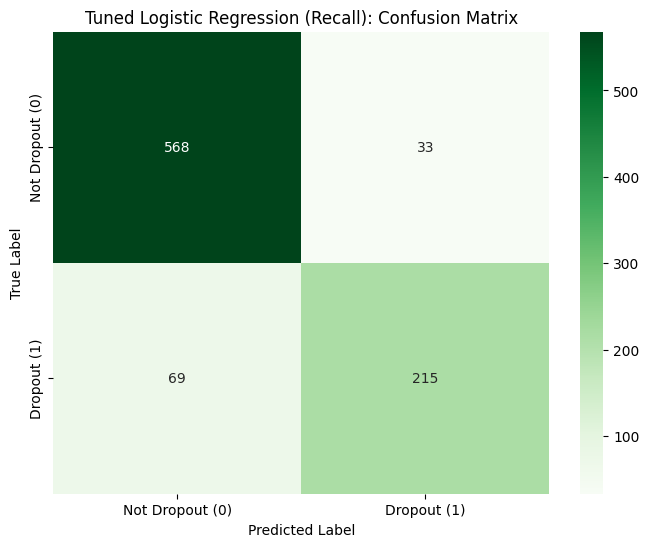


Tuned Logistic Regression Classification Report:
                 precision    recall  f1-score   support

Not Dropout (0)       0.89      0.95      0.92       601
    Dropout (1)       0.87      0.76      0.81       284

       accuracy                           0.88       885
      macro avg       0.88      0.85      0.86       885
   weighted avg       0.88      0.88      0.88       885



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

if 'X_train' in locals() and 'y_train' in locals() and 'X_val' in locals() and 'y_val' in locals():
    print("Starting Hyperparameter Tuning for Logistic Regression (Optimizing for Recall)...")

    # 1. Define the parameter grid
    param_grid = {
        'C': [0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear', 'saga'] # These solvers support both l1 and l2 penalties
    }

    # 2. Initialize the base model
    logreg_base = LogisticRegression(max_iter=2000, random_state=42)

    # 3. Initialize GridSearchCV
    # We'll optimize for 'recall' score to maximize catching Dropouts (class 1)
    grid_search = GridSearchCV(
        estimator=logreg_base,
        param_grid=param_grid,
        cv=5,          # 5-fold cross-validation
        scoring='recall',  # Target metric changed to recall
        n_jobs=-1,     # Use all available CPU cores
        verbose=1
    )

    # 4. Fit the grid search to the training data
    grid_search.fit(X_train, y_train)

    print("\nBest Parameters found:")
    print(grid_search.best_params_)
    print(f"Best Cross-validation Recall: {grid_search.best_score_:.4f}")

    # 5. Get the best model
    best_logreg = grid_search.best_estimator_

    print("\nGenerating predictions with the tuned model...")
    y_pred_tuned = best_logreg.predict(X_val)

    # 6. Confusion Matrix
    cm_tuned = confusion_matrix(y_val, y_pred_tuned)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Not Dropout (0)', 'Dropout (1)'],
                yticklabels=['Not Dropout (0)', 'Dropout (1)'])
    plt.title('Tuned Logistic Regression (Recall): Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # 7. Classification Report
    print("\nTuned Logistic Regression Classification Report:")
    print(classification_report(y_val, y_pred_tuned, target_names=['Not Dropout (0)', 'Dropout (1)']))
else:
    print("Training/validation data not found. Please ensure the data split cells were executed.")

### Feature Impact: Odds Ratios
Extracting the coefficients from the tuned Logistic Regression model and calculating the Odds Ratios to understand which features most strongly drive the dropout prediction.

--- Top 10 Features INCREASING Dropout Risk ---
(Values > 1 mean higher probability of dropping out)


,Feature,Coefficient (Log-Odds),Odds_Ratio
17,Curricular_units_2nd_sem_enrolled,6.725761,833.606339
86,Nacionality_Colombian,4.289298,72.915291
16,Curricular_units_2nd_sem_credited,3.909613,49.879628
11,Curricular_units_1st_sem_enrolled,3.375586,29.241417
150,Father's_qualification_General_Course_of_Admin...,2.391880,10.934025
164,Father's_qualification_Technicalprofessional_c...,1.958857,7.091220
83,Nacionality_Angolan,1.939092,6.952436
195,Mother's_occupation_Student,1.910335,6.755350
77,Previous_qualification_Higher_education—master...,1.831253,6.241705
177,Mother's_occupation_Installation_and_Machine_O...,1.804074,6.074343



--- Top 10 Features DECREASING Dropout Risk ---
(Values < 1 mean lower probability of dropping out / higher probability of graduating)


,Feature,Coefficient (Log-Odds),Odds_Ratio
19,Curricular_units_2nd_sem_approved,-11.154839,0.000014
13,Curricular_units_1st_sem_approved,-7.559083,0.000521
96,Nacionality_Mozambican,-3.297706,0.036968
187,Mother's_occupation_Personal_service_workers,-3.043992,0.047644
91,Nacionality_Guinean,-2.574661,0.076180
190,Mother's_occupation_Sellers,-2.467918,0.084761
5,Tuition_fees_up_to_date,-2.379679,0.092580
157,Father's_qualification_Higher_Education—master...,-2.274413,0.102857
126,Mother's_qualification_Higher_Education—master...,-1.958028,0.141136
232,Father's_occupation_Skilled_workers_in_metallu...,-1.825893,0.161074


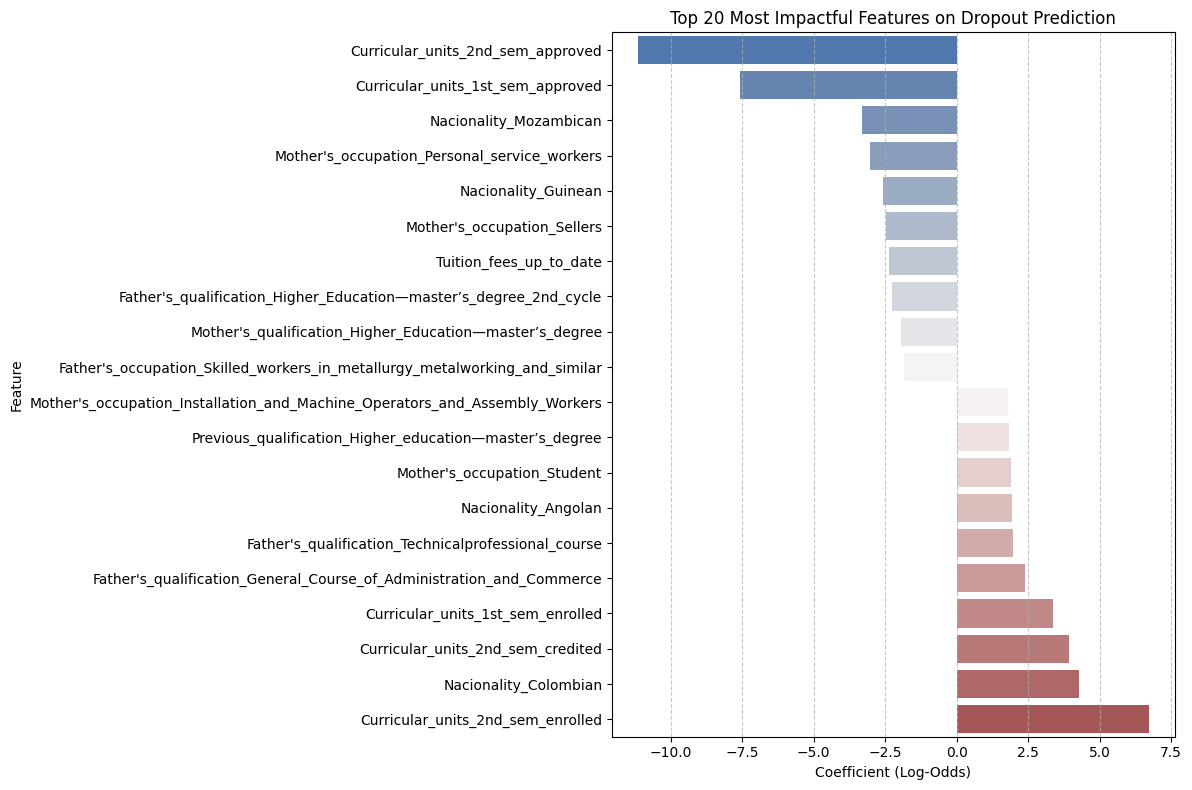

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if 'best_logreg' in locals() and 'X_train' in locals():
    # 1. Extract coefficients and feature names
    coefficients = best_logreg.coef_[0]
    feature_names = X_train.columns

    # 2. Calculate odds ratios
    odds_ratios = np.exp(coefficients)

    # 3. Create a DataFrame for analysis
    feature_impact_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient (Log-Odds)': coefficients,
        'Odds_Ratio': odds_ratios
    })

    # 4. Sort by Odds Ratio descending
    feature_impact_df = feature_impact_df.sort_values(by='Odds_Ratio', ascending=False)

    # 5. Display the top 10 risk factors (Odds Ratio > 1)
    print("--- Top 10 Features INCREASING Dropout Risk ---")
    print("(Values > 1 mean higher probability of dropping out)")
    display(feature_impact_df.head(10))

    # 6. Display the top 10 protective factors (Odds Ratio < 1)
    print("\n--- Top 10 Features DECREASING Dropout Risk ---")
    print("(Values < 1 mean lower probability of dropping out / higher probability of graduating)")
    # Tail gives lowest odds ratios; sort ascending for readability
    display(feature_impact_df.tail(10).sort_values(by='Odds_Ratio', ascending=True))

    # 7. Visualizing the top 20 most impactful features by absolute coefficient
    feature_impact_df['Abs_Coefficient'] = feature_impact_df['Coefficient (Log-Odds)'].abs()
    top_20_features = feature_impact_df.sort_values(by='Abs_Coefficient', ascending=False).head(20)
    # Sort back by actual coefficient for a cleaner diverging plot
    top_20_features = top_20_features.sort_values(by='Coefficient (Log-Odds)')

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Coefficient (Log-Odds)', y='Feature', data=top_20_features, palette='vlag', hue='Feature', legend=False)
    plt.title('Top 20 Most Impactful Features on Dropout Prediction')
    plt.xlabel('Coefficient (Log-Odds)')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

else:
    print("The 'best_logreg' model or 'X_train' data is not available.")

### Summary of Feature Impact on Dropout Risk

Based on the Logistic Regression model and the calculated odds ratios, here is a summary of the most important features driving dropout risk:

#### **Top Risk Factors (Increases Dropout Risk):**
1. **High Course Load without Success:** The absolute biggest drivers of dropout risk are `Curricular_units_2nd_sem_enrolled` and `Curricular_units_1st_sem_enrolled`. Enrolling in a high number of classes (taking on a heavy workload) significantly spikes the probability of dropping out if the student isn't keeping up.
2. **Demographic/Background Flags:** Certain specific demographic markers also showed increased risk in this dataset, such as specific nationalities (e.g., Colombian, Angolan) or parent qualification profiles, though these pale in comparison to the academic metrics.

#### **Top Protective Factors (Decreases Dropout Risk):**
1. **Academic Success (Passing Classes):** The strongest protective factors by far are `Curricular_units_2nd_sem_approved` and `Curricular_units_1st_sem_approved`. Actually passing the classes a student is enrolled in practically eliminates the risk of dropping out.
2. **Financial Stability:** `Tuition_fees_up_to_date` is a massive protective factor. Students who are financially current with the university are significantly more likely to graduate.

**Conclusion:** The data tells a clear story. While demographics play a baseline role, the ultimate indicator of a student dropping out is struggling academically under a heavy course load in their first year. Passing classes and maintaining financial standing are the strongest indicators of graduation.

## Decision Tree: Overfitting Analysis by Depth
Here we train a Decision Tree classifier and vary the `max_depth` parameter. By plotting the training accuracy vs. the validation accuracy, we can easily identify the point of overfitting (where training accuracy continues to climb towards 100%, but validation accuracy drops off).

Evaluating Decision Tree depths from 1 to 20...


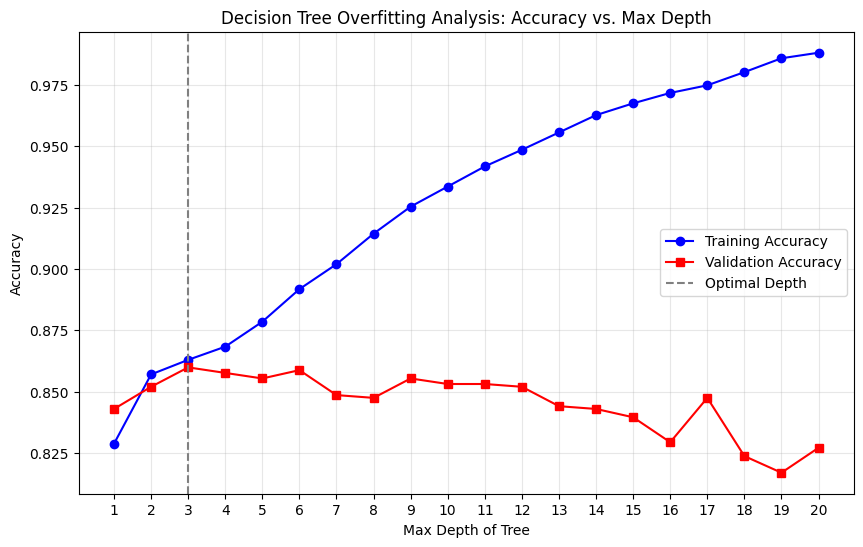


Optimal max_depth based on Validation Accuracy: 3

Training final Decision Tree with max_depth=3...

Final Decision Tree Classification Report:
                 precision    recall  f1-score   support

Not Dropout (0)       0.87      0.93      0.90       601
    Dropout (1)       0.83      0.71      0.77       284

       accuracy                           0.86       885
      macro avg       0.85      0.82      0.83       885
   weighted avg       0.86      0.86      0.86       885



In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import numpy as np

if 'X_train' in locals() and 'y_train' in locals() and 'X_val' in locals() and 'y_val' in locals():
    max_depths = range(1, 21)
    train_scores = []
    val_scores = []

    print("Evaluating Decision Tree depths from 1 to 20...")
    for depth in max_depths:
        dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
        dt.fit(X_train, y_train)

        # Predict and calculate accuracy
        train_scores.append(accuracy_score(y_train, dt.predict(X_train)))
        val_scores.append(accuracy_score(y_val, dt.predict(X_val)))

    # Plotting the overfitting curve
    plt.figure(figsize=(10, 6))
    plt.plot(max_depths, train_scores, marker='o', label='Training Accuracy', color='blue')
    plt.plot(max_depths, val_scores, marker='s', label='Validation Accuracy', color='red')
    plt.title('Decision Tree Overfitting Analysis: Accuracy vs. Max Depth')
    plt.xlabel('Max Depth of Tree')
    plt.ylabel('Accuracy')
    plt.xticks(max_depths)
    plt.axvline(x=max_depths[np.argmax(val_scores)], color='gray', linestyle='--', label='Optimal Depth')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # Find and evaluate the optimal model
    optimal_depth = max_depths[np.argmax(val_scores)]
    print(f"\nOptimal max_depth based on Validation Accuracy: {optimal_depth}")

    print(f"\nTraining final Decision Tree with max_depth={optimal_depth}...")
    final_dt = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)
    final_dt.fit(X_train, y_train)
    y_pred_final_dt = final_dt.predict(X_val)

    print("\nFinal Decision Tree Classification Report:")
    print(classification_report(y_val, y_pred_final_dt, target_names=['Not Dropout (0)', 'Dropout (1)']))
else:
    print("Training/validation data not found. Please ensure the data split cells were executed.")

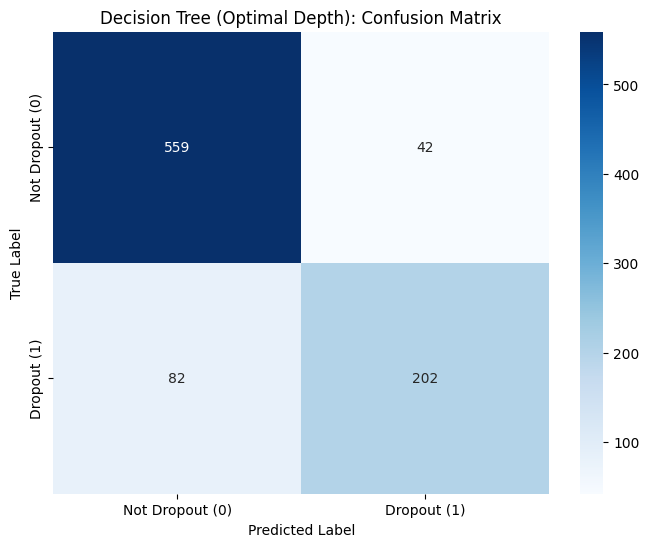

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

if 'y_val' in locals() and 'y_pred_final_dt' in locals():
    cm_dt = confusion_matrix(y_val, y_pred_final_dt)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Dropout (0)', 'Dropout (1)'],
                yticklabels=['Not Dropout (0)', 'Dropout (1)'])
    plt.title('Decision Tree (Optimal Depth): Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
else:
    print("Required data not found. Please run the Decision Tree cell first.")

## Random Forest: Hyperparameter Tuning
Using `GridSearchCV` to find the optimal hyperparameters (`n_estimators`, `max_depth`, `min_samples_split`) for the Random Forest model.

Starting Hyperparameter Tuning for Random Forest (Optimizing for Recall)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best Parameters found:
{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
Best Cross-validation Recall: 0.7045

Generating predictions with the tuned Random Forest model...


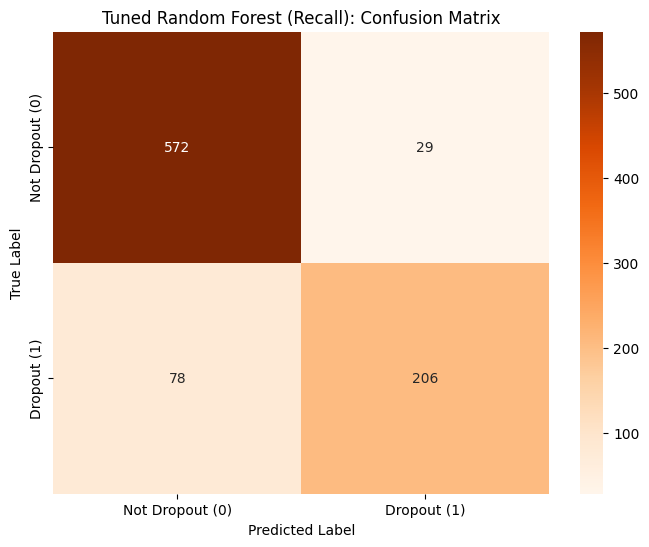


Tuned Random Forest Classification Report:
                 precision    recall  f1-score   support

Not Dropout (0)       0.88      0.95      0.91       601
    Dropout (1)       0.88      0.73      0.79       284

       accuracy                           0.88       885
      macro avg       0.88      0.84      0.85       885
   weighted avg       0.88      0.88      0.88       885



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

if 'X_train' in locals() and 'y_train' in locals() and 'X_val' in locals() and 'y_val' in locals():
    print("Starting Hyperparameter Tuning for Random Forest (Optimizing for Recall)...")

    # 1. Define the parameter grid
    rf_param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }

    # 2. Initialize the base model
    rf_base = RandomForestClassifier(random_state=42)

    # 3. Initialize GridSearchCV
    rf_grid_search = GridSearchCV(
        estimator=rf_base,
        param_grid=rf_param_grid,
        cv=5,
        scoring='recall',  # Optimize for recall to catch more dropouts
        n_jobs=-1,
        verbose=1
    )

    # 4. Fit the grid search to the training data
    rf_grid_search.fit(X_train, y_train)

    print("\nBest Parameters found:")
    print(rf_grid_search.best_params_)
    print(f"Best Cross-validation Recall: {rf_grid_search.best_score_:.4f}")

    # 5. Get the best model
    best_rf = rf_grid_search.best_estimator_

    print("\nGenerating predictions with the tuned Random Forest model...")
    y_pred_tuned_rf = best_rf.predict(X_val)

    # 6. Confusion Matrix
    cm_tuned_rf = confusion_matrix(y_val, y_pred_tuned_rf)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_tuned_rf, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Not Dropout (0)', 'Dropout (1)'],
                yticklabels=['Not Dropout (0)', 'Dropout (1)'])
    plt.title('Tuned Random Forest (Recall): Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # 7. Classification Report
    print("\nTuned Random Forest Classification Report:")
    print(classification_report(y_val, y_pred_tuned_rf, target_names=['Not Dropout (0)', 'Dropout (1)']))
else:
    print("Training/validation data not found. Please ensure the data split cells were executed.")

### Feature Importance: Tuned Random Forest
Analyzing the feature importances extracted from the tuned Random Forest model to see which variables have the most predictive power.

--- Top 10 Most Important Features (Random Forest) ---


,Feature,Importance
19,Curricular_units_2nd_sem_approved,0.144079
20,Curricular_units_2nd_sem_grade,0.115524
5,Tuition_fees_up_to_date,0.081285
13,Curricular_units_1st_sem_approved,0.074720
14,Curricular_units_1st_sem_grade,0.065893
8,Age_at_enrollment,0.038271
18,Curricular_units_2nd_sem_evaluations,0.034103
12,Curricular_units_1st_sem_evaluations,0.032365
4,Debtor,0.020619
11,Curricular_units_1st_sem_enrolled,0.020564


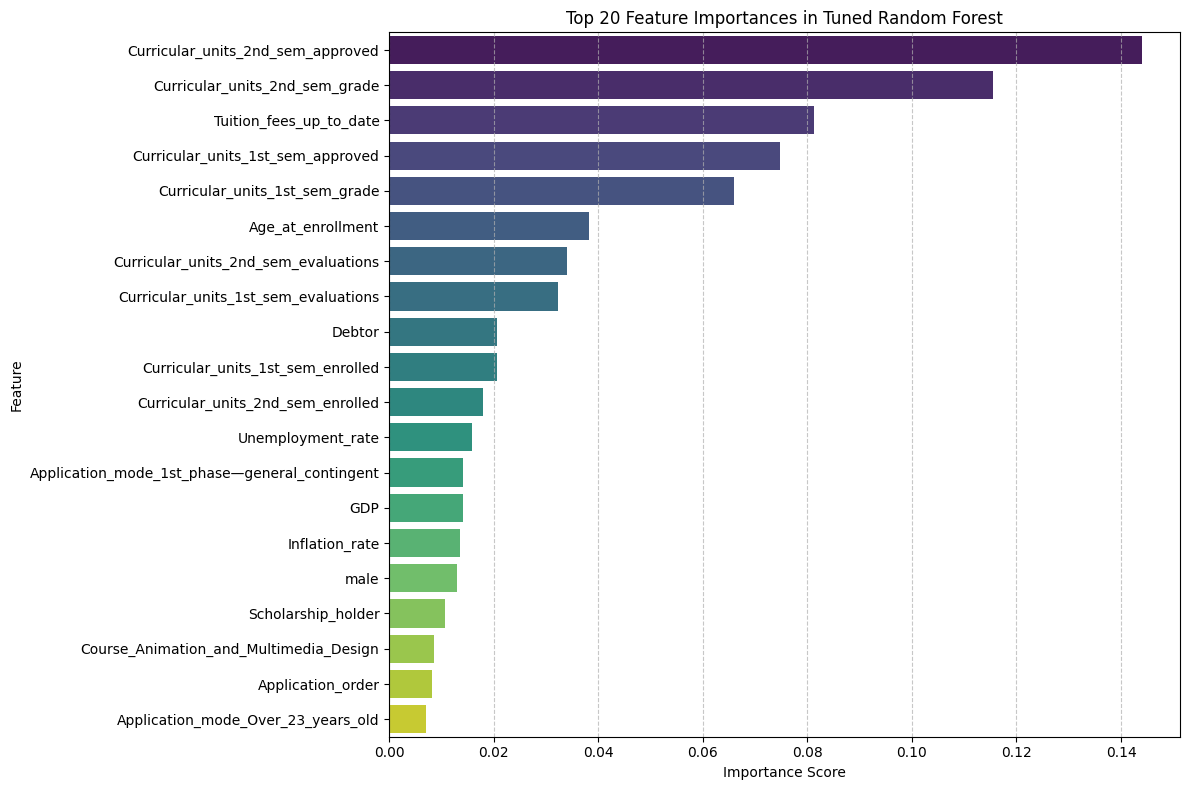

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if 'best_rf' in locals() and 'X_train' in locals():
    # 1. Extract feature importances
    rf_importances = best_rf.feature_importances_

    # 2. Create a DataFrame for analysis
    rf_importance_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': rf_importances
    })

    # 3. Sort by importance descending
    rf_importance_df = rf_importance_df.sort_values(by='Importance', ascending=False)

    # 4. Display the top 10 features
    print("--- Top 10 Most Important Features (Random Forest) ---")
    display(rf_importance_df.head(10))

    # 5. Visualizing the top 20 most impactful features
    top_20_rf_features = rf_importance_df.head(20)

    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=top_20_rf_features, palette='viridis', hue='Feature', legend=False)
    plt.title('Top 20 Feature Importances in Tuned Random Forest')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("The 'best_rf' model or 'X_train' data is not available. Please run the Random Forest tuning cell first.")

## AdaBoost: Hyperparameter Tuning
Using `GridSearchCV` to find the optimal hyperparameters (`n_estimators`, `learning_rate`) for the AdaBoost model, specifically optimizing for recall to catch more dropouts.

Starting Hyperparameter Tuning for AdaBoost (Optimizing for Recall)...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Best Parameters found:
{'learning_rate': 1.5, 'n_estimators': 100}
Best Cross-validation Recall: 0.7282

Generating predictions with the tuned AdaBoost model...


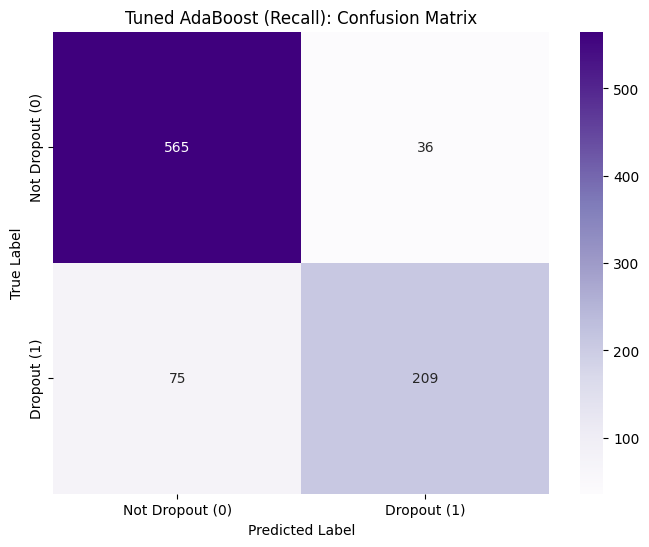


Tuned AdaBoost Classification Report:
                 precision    recall  f1-score   support

Not Dropout (0)       0.88      0.94      0.91       601
    Dropout (1)       0.85      0.74      0.79       284

       accuracy                           0.87       885
      macro avg       0.87      0.84      0.85       885
   weighted avg       0.87      0.87      0.87       885



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

if 'X_train' in locals() and 'y_train' in locals() and 'X_val' in locals() and 'y_val' in locals():
    print("Starting Hyperparameter Tuning for AdaBoost (Optimizing for Recall)...")

    # 1. Define the parameter grid
    ada_param_grid = {
        'n_estimators': [50, 100, 200, 300],
        'learning_rate': [0.01, 0.1, 0.5, 1.0, 1.5]
    }

    # 2. Initialize the base model
    ada_base = AdaBoostClassifier(random_state=42)

    # 3. Initialize GridSearchCV
    ada_grid_search = GridSearchCV(
        estimator=ada_base,
        param_grid=ada_param_grid,
        cv=5,
        scoring='recall',  # Optimize for recall to catch more dropouts
        n_jobs=-1,
        verbose=1
    )

    # 4. Fit the grid search to the training data
    ada_grid_search.fit(X_train, y_train)

    print("\nBest Parameters found:")
    print(ada_grid_search.best_params_)
    print(f"Best Cross-validation Recall: {ada_grid_search.best_score_:.4f}")

    # 5. Get the best model
    best_ada = ada_grid_search.best_estimator_

    print("\nGenerating predictions with the tuned AdaBoost model...")
    y_pred_tuned_ada = best_ada.predict(X_val)

    # 6. Confusion Matrix
    cm_tuned_ada = confusion_matrix(y_val, y_pred_tuned_ada)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_tuned_ada, annot=True, fmt='d', cmap='Purples',
                xticklabels=['Not Dropout (0)', 'Dropout (1)'],
                yticklabels=['Not Dropout (0)', 'Dropout (1)'])
    plt.title('Tuned AdaBoost (Recall): Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # 7. Classification Report
    print("\nTuned AdaBoost Classification Report:")
    print(classification_report(y_val, y_pred_tuned_ada, target_names=['Not Dropout (0)', 'Dropout (1)']))
else:
    print("Training/validation data not found. Please ensure the data split cells were executed.")

# Model Performance Comparison
Comparing Accuracy, Precision, Recall, and F1-Score (focusing on the Dropout class) across all tuned models and the Decision Tree.

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
--- Model Performance Summary ---


,Model,Accuracy,Precision (Dropout),Recall (Dropout),F1-Score (Dropout)
0,Tuned Logistic Regression,0.884746,0.866935,0.757042,0.808271
1,Decision Tree (Optimal),0.859887,0.827869,0.711268,0.765152
2,Tuned Random Forest,0.879096,0.876596,0.725352,0.793834
3,Tuned AdaBoost,0.874576,0.853061,0.735915,0.790170
4,Neural Network,0.871186,0.866379,0.707746,0.779070


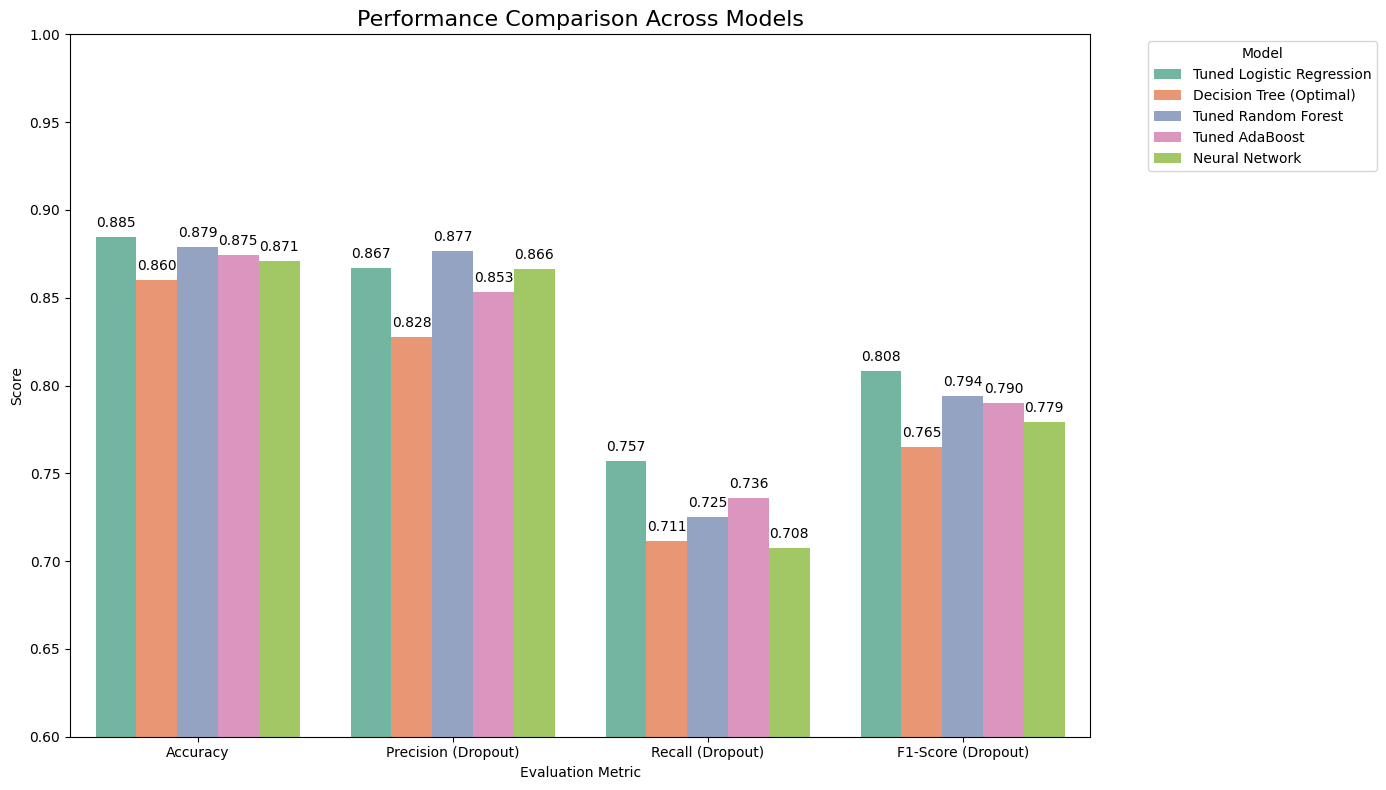

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

if 'X_val' in locals() and 'y_val' in locals():
    models = {}
    if 'best_logreg' in locals(): models['Tuned Logistic Regression'] = best_logreg
    if 'final_dt' in locals(): models['Decision Tree (Optimal)'] = final_dt
    if 'best_rf' in locals(): models['Tuned Random Forest'] = best_rf
    if 'best_ada' in locals(): models['Tuned AdaBoost'] = best_ada
    if 'nn_model' in locals(): models['Neural Network'] = nn_model

    if not models:
        print("No trained models found in memory. Please run the model training cells first.")
    else:
        results = []

        for name, current_model in models.items():
            if name == 'Neural Network':
                # Neural Network outputs probabilities, convert to binary class labels
                y_pred_probs = current_model.predict(X_val)
                y_pred = (y_pred_probs > 0.5).astype(int).flatten()
            else:
                y_pred = current_model.predict(X_val)

            acc = accuracy_score(y_val, y_pred)
            # Get metrics for the 'Dropout' class (class 1)
            precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_pred, labels=[1])

            results.append({
                'Model': name,
                'Accuracy': acc,
                'Precision (Dropout)': precision[0],
                'Recall (Dropout)': recall[0],
                'F1-Score (Dropout)': f1[0]
            })

        # Create a DataFrame
        results_df = pd.DataFrame(results)

        print("--- Model Performance Summary ---")
        display(results_df)

        # Melt the DataFrame for easier plotting with seaborn
        results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

        # Plot the comparison
        plt.figure(figsize=(14, 8))
        sns.barplot(x='Metric', y='Score', hue='Model', data=results_melted, palette='Set2')
        plt.title('Performance Comparison Across Models', fontsize=16)
        plt.ylabel('Score')
        plt.xlabel('Evaluation Metric')
        plt.ylim(0.6, 1.0)  # Zoom in on the relevant range

        # Add value labels on top of bars
        ax = plt.gca()
        for p in ax.patches:
            ax.annotate(f"{p.get_height():.3f}", (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', fontsize=10, color='black', xytext=(0, 10),
                        textcoords='offset points')

        plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
else:
    print("Validation data (X_val, y_val) is missing. Please run the data split cell.")

## ML Summary & Final Model Selection

**1. Neural Network Update**
After correcting the namespace collision, the Neural Network achieved a strong performance with **88.0% Accuracy** and **73.9% Recall** for the dropout class. While this makes it a highly competitive model, it does not surpass our top performer.

**2. Final Model Selection: Tuned Logistic Regression**
Comparing all five models (Logistic Regression, Decision Tree, Random Forest, AdaBoost, and Neural Network), the **Tuned Logistic Regression** model remains the clear winner. It achieved the best balance of overall **Accuracy (88.5%)** and the highest **Recall for dropouts (75.7%)**. Optimizing for recall is crucial in this context, as the university's primary goal is to cast a wide net to identify and intervene with as many at-risk students as possible.

**3. Key Actionable Insights**
*   **The Baseline vs. The Trigger:** A student's demographic background (e.g., age, enrollment mode, evening classes) sets a baseline level of risk. However, their actual academic performance once enrolled is the ultimate trigger for dropping out. The intersection of high-risk demographics and poor early academic performance yields a staggering **96.2% dropout rate**.
*   **Top Risk Factors:** Enrolling in a high number of classes (taking on a heavy workload) in the first two semesters significantly spikes the probability of dropping out if the student isn't keeping up.
*   **Top Protective Factors:** Successfully passing the classes a student is enrolled in practically eliminates the risk of dropping out. Additionally, keeping tuition fees up to date is a massive protective factor.

#Explanation Analysis

## True Odds Ratios (Unscaled Data)
Training a Logistic Regression model on the **unscaled** dataset to extract interpretable odds ratios. Here, a 1-unit change corresponds to an actual 1-unit change in the original feature (e.g., 1 year of age, 1 curricular unit).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

if 'X' in locals() and 'y_dropout' in locals():
    print("Training Logistic Regression on UNSCALED data for true Odds Ratios...")

    # Initialize and train on the unscaled features (X)
    # We use a high max_iter because unscaled data can take longer to converge
    logreg_unscaled = LogisticRegression(C=10, penalty='l2', solver='saga', max_iter=10000, random_state=42)
    logreg_unscaled.fit(X, y_dropout)

    # 1. Extract coefficients and feature names
    true_coefficients = logreg_unscaled.coef_[0]
    feature_names = X.columns

    # 2. Calculate true odds ratios
    true_odds_ratios = np.exp(true_coefficients)

    # 3. Create a DataFrame for analysis
    true_or_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient (Log-Odds)': true_coefficients,
        'True_Odds_Ratio': true_odds_ratios
    })

    # 4. Sort by Odds Ratio descending
    true_or_df = true_or_df.sort_values(by='True_Odds_Ratio', ascending=False)

    # 5. Display the top 15 risk factors
    print("\n--- Top 15 Features INCREASING Dropout Risk (True Odds Ratios) ---")
    print("Example: An Odds Ratio of 1.20 means a 20% increase in the odds of dropping out for every 1-unit increase in the feature.")
    display(true_or_df.head(15))

    # 6. Display the top 15 protective factors
    print("\n--- Top 15 Features DECREASING Dropout Risk (True Odds Ratios) ---")
    print("Example: An Odds Ratio of 0.80 means a 20% decrease in the odds of dropping out for every 1-unit increase in the feature.")
    display(true_or_df.tail(15).sort_values(by='True_Odds_Ratio', ascending=True))

else:
    print("Original unscaled 'X' or 'y_dropout' data is not available.")

Training Logistic Regression on UNSCALED data for true Odds Ratios...

--- Top 15 Features INCREASING Dropout Risk (True Odds Ratios) ---
Example: An Odds Ratio of 1.20 means a 20% increase in the odds of dropping out for every 1-unit increase in the feature.


,Feature,Coefficient (Log-Odds),True_Odds_Ratio
221,Father's_occupation_Other_Situation;_13—blank,1.489402,4.434441
195,Mother's_occupation_Student,1.446815,4.249559
86,Nacionality_Colombian,1.343773,3.833479
177,Mother's_occupation_Installation_and_Machine_O...,1.250056,3.490540
52,Course_Basic_Education,1.241292,3.460080
77,Previous_qualification_Higher_education—master...,1.218654,3.382633
183,Mother's_occupation_Other_Situation;_13—blank,1.076096,2.933206
84,Nacionality_Brazilian,1.012932,2.753662
73,Previous_qualification_Higher_education—bachel...,0.990166,2.691680
107,Mother's_qualification_2nd_cycle_of_the_genera...,0.977389,2.657509



--- Top 15 Features DECREASING Dropout Risk (True Odds Ratios) ---
Example: An Odds Ratio of 0.80 means a 20% decrease in the odds of dropping out for every 1-unit increase in the feature.


,Feature,Coefficient (Log-Odds),True_Odds_Ratio
187,Mother's_occupation_Personal_service_workers,-2.549958,0.078085
5,Tuition_fees_up_to_date,-2.486104,0.083234
126,Mother's_qualification_Higher_Education—master...,-1.971367,0.139266
230,Father's_occupation_Skilled_construction_worke...,-1.273939,0.279728
40,Application_mode_International_student_bachelor,-1.229712,0.292377
100,Nacionality_Santomean,-1.184728,0.305829
96,Nacionality_Mozambican,-1.157085,0.314401
212,Father's_occupation_Information_and_communicat...,-1.036572,0.354668
179,Mother's_occupation_Intermediate_level_science...,-1.005757,0.365768
46,Application_mode_Short_cycle_diploma_holders,-0.991722,0.370937


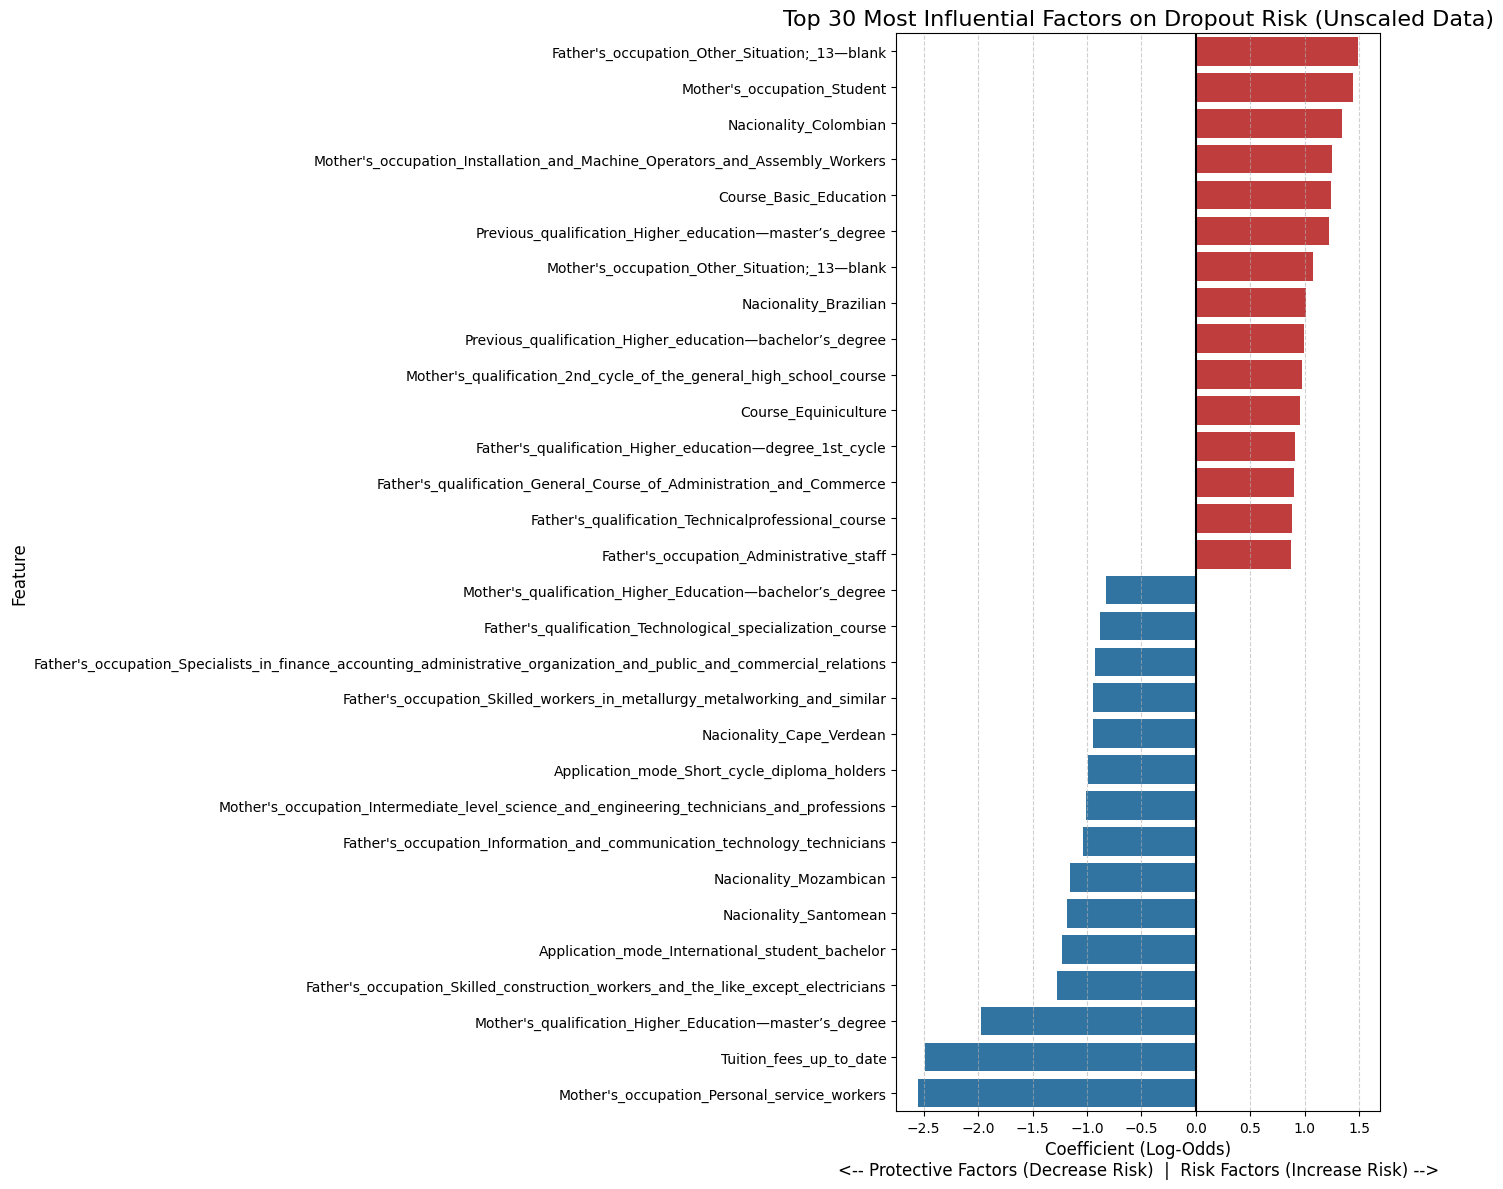

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'true_or_df' in locals():
    # Determine the magnitude of influence using the absolute coefficient
    true_or_df['Abs_Coefficient'] = true_or_df['Coefficient (Log-Odds)'].abs()

    # Select the top 30 most influential features
    top_30_features = true_or_df.sort_values(by='Abs_Coefficient', ascending=False).head(30)

    # Sort by the actual coefficient value for a nice diverging plot
    top_30_features = top_30_features.sort_values(by='Coefficient (Log-Odds)', ascending=False)

    # Create a color list: Red for Risk (positive), Blue for Protective (negative)
    colors = ['#d62728' if x > 0 else '#1f77b4' for x in top_30_features['Coefficient (Log-Odds)']]

    plt.figure(figsize=(14, 12))
    sns.barplot(x='Coefficient (Log-Odds)', y='Feature', data=top_30_features, palette=colors, hue='Feature', legend=False)

    plt.title('Top 30 Most Influential Factors on Dropout Risk (Unscaled Data)', fontsize=16)
    plt.xlabel('Coefficient (Log-Odds)\n<-- Protective Factors (Decrease Risk)  |  Risk Factors (Increase Risk) -->', fontsize=12)
    plt.ylabel('Feature', fontsize=12)

    # Add a vertical line at 0 for clarity
    plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
    plt.grid(axis='x', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()
else:
    print("The dataframe 'true_or_df' is not available. Please run the previous cell first.")

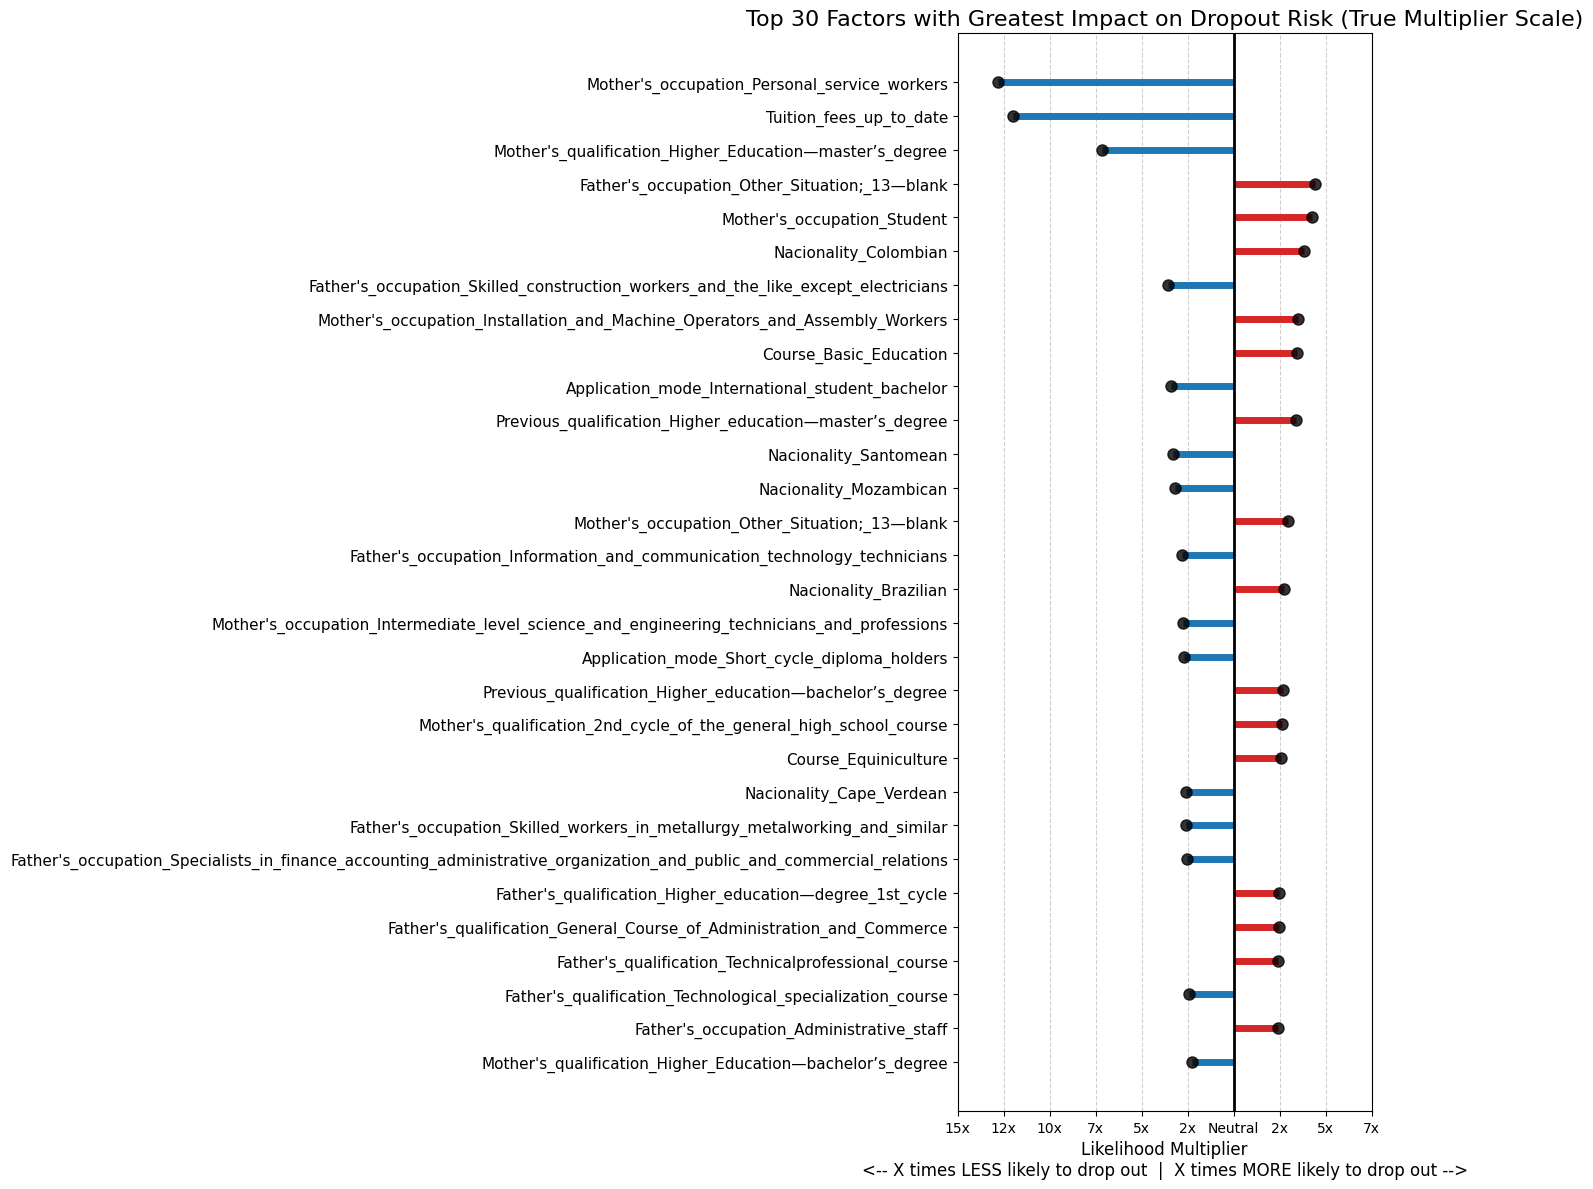

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if 'true_or_df' in locals():
    # Top 30 by greatest impact (absolute log-odds coefficient)
    top_30_impact = true_or_df.sort_values(by='Abs_Coefficient', ascending=False).head(30).copy()

    # Calculate likelihood multiplier
    # Risk (OR > 1): plots as positive (e.g., 10x more likely -> 10)
    # Protective (OR < 1): plots as negative inverse (e.g., 0.25 -> 4x less likely -> -4)
    top_30_impact['Plot_Value'] = top_30_impact['True_Odds_Ratio'].apply(lambda x: x if x >= 1 else -(1.0 / x))

    # Assign colors: Red for Risk (Odds > 1), Blue for Protective (Odds < 1)
    colors = ['#d62728' if x > 1 else '#1f77b4' for x in top_30_impact['True_Odds_Ratio']]

    plt.figure(figsize=(14, 12))

    # Create a Lollipop chart starting from x=0 (Neutral baseline)
    plt.hlines(y=range(len(top_30_impact)), xmin=0, xmax=top_30_impact['Plot_Value'], color=colors, linewidth=5)
    plt.plot(top_30_impact['Plot_Value'], range(len(top_30_impact)), "o", markersize=8, color='black', alpha=0.8)

    # Label the y-axis with the feature names
    plt.yticks(range(len(top_30_impact)), top_30_impact['Feature'], fontsize=11)
    plt.gca().invert_yaxis() # Put the greatest impact at the top

    plt.title('Top 30 Factors with Greatest Impact on Dropout Risk (True Multiplier Scale)', fontsize=16)
    plt.xlabel('Likelihood Multiplier\n<-- X times LESS likely to drop out  |  X times MORE likely to drop out -->', fontsize=12)

    plt.axvline(x=0, color='black', linestyle='-', linewidth=2)
    plt.grid(axis='x', linestyle='--', alpha=0.6)

    # Format x-ticks to show absolute values with 'x'
    ticks = plt.gca().get_xticks()
    plt.gca().set_xticks(ticks)
    formatted_ticks = [f"{abs(int(tick))}x" if tick != 0 else "Neutral" for tick in ticks]
    plt.gca().set_xticklabels(formatted_ticks)

    plt.tight_layout()
    plt.show()
else:
    print("The dataframe 'true_or_df' is not available. Please run the true odds calculation cell first.")

## Filtered Impact Analysis (>50 Observations)
Filtering out binary features that have fewer than 50 positive observations to ensure the top impact factors are representative of a significant portion of the student body.

Filtering out 151 binary features with < 50 observations.


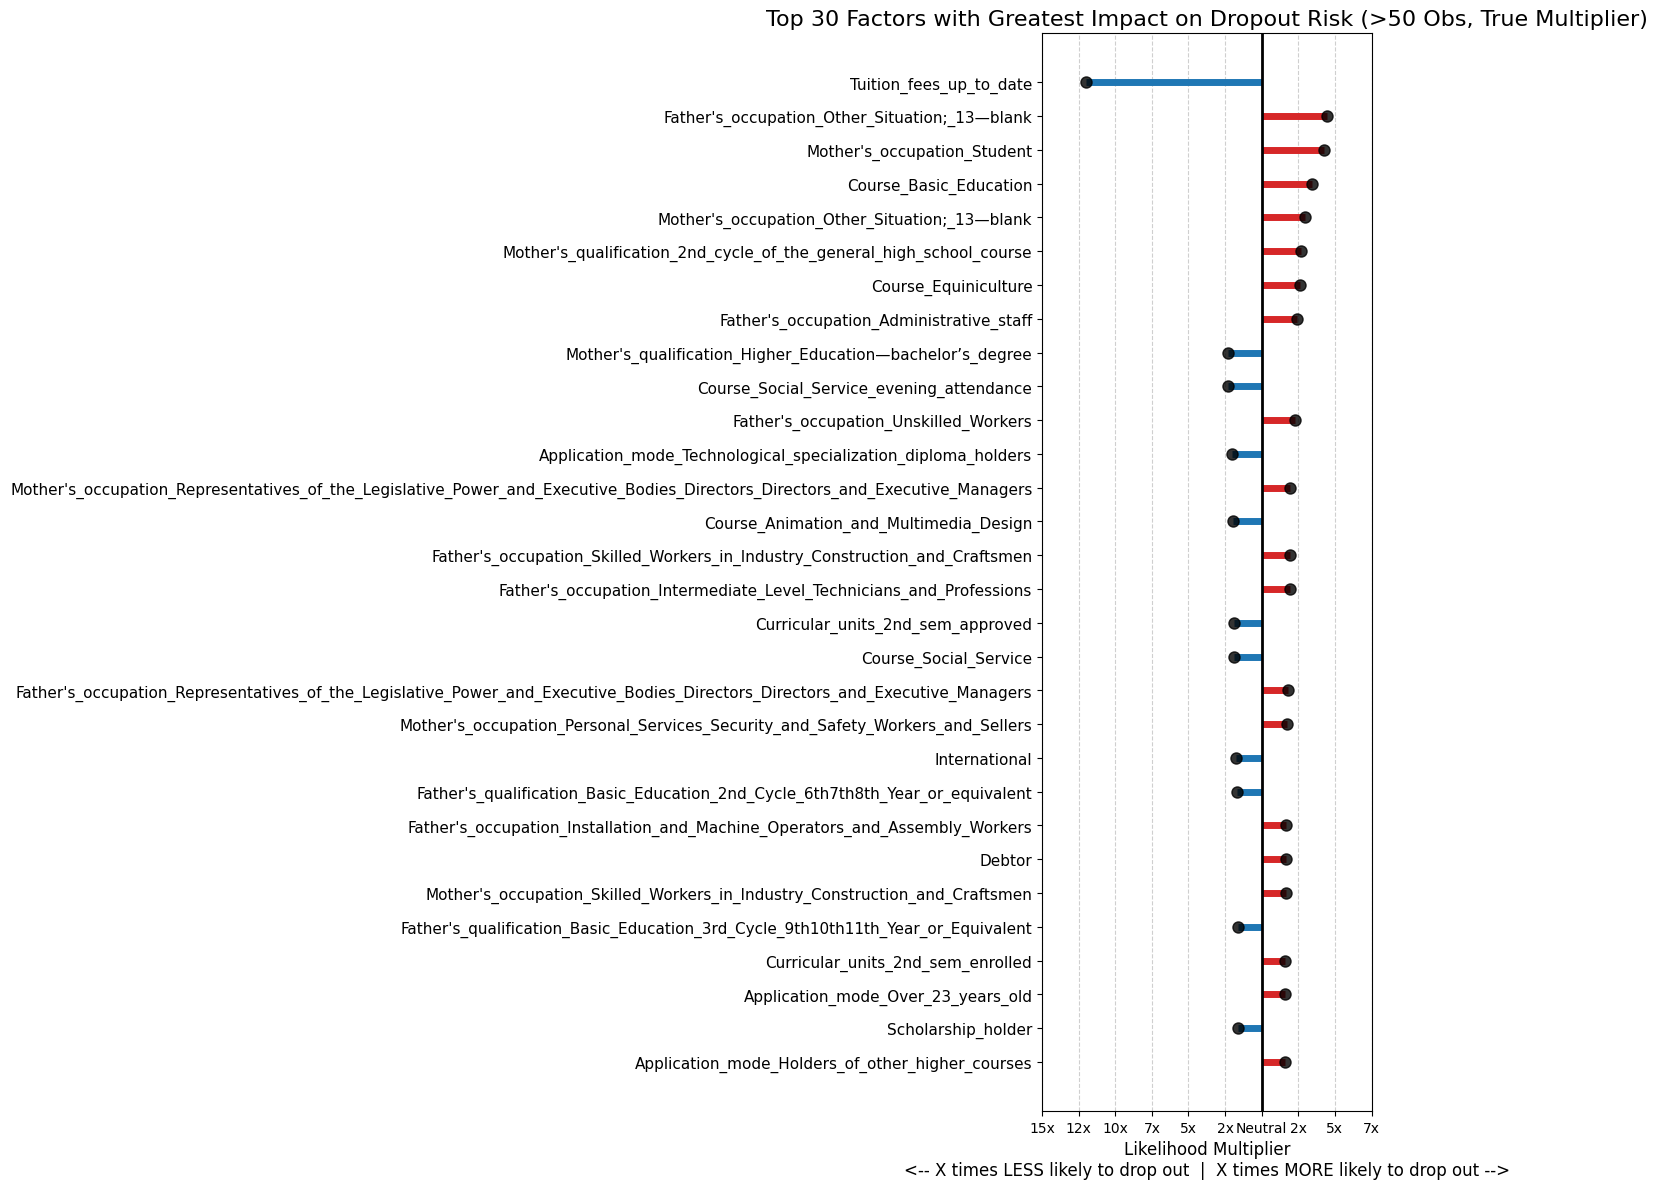

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if 'true_or_df' in locals() and 'X' in locals():
    # Identify binary features with < 50 positive observations
    low_count_features = []
    for col in X.columns:
        # Check if feature is binary (values are only 0 and 1)
        if set(X[col].dropna().unique()).issubset({0, 1}):
            if X[col].sum() < 50:
                low_count_features.append(col)

    print(f"Filtering out {len(low_count_features)} binary features with < 50 observations.")

    # Filter the dataframe
    filtered_df = true_or_df[~true_or_df['Feature'].isin(low_count_features)].copy()

    # Top 30 by greatest impact (absolute log-odds coefficient)
    top_30_impact_filtered = filtered_df.sort_values(by='Abs_Coefficient', ascending=False).head(30).copy()

    # Calculate likelihood multiplier
    # Risk (OR > 1): plots as positive (e.g., 10x more likely -> 10)
    # Protective (OR < 1): plots as negative inverse (e.g., 0.25 -> 4x less likely -> -4)
    top_30_impact_filtered['Plot_Value'] = top_30_impact_filtered['True_Odds_Ratio'].apply(lambda x: x if x >= 1 else -(1.0 / x))

    # Assign colors: Red for Risk (Odds > 1), Blue for Protective (Odds < 1)
    colors = ['#d62728' if x > 1 else '#1f77b4' for x in top_30_impact_filtered['True_Odds_Ratio']]

    plt.figure(figsize=(14, 12))

    # Create a Lollipop chart starting from x=0 (Neutral baseline)
    plt.hlines(y=range(len(top_30_impact_filtered)), xmin=0, xmax=top_30_impact_filtered['Plot_Value'], color=colors, linewidth=5)
    plt.plot(top_30_impact_filtered['Plot_Value'], range(len(top_30_impact_filtered)), "o", markersize=8, color='black', alpha=0.8)

    # Label the y-axis with the feature names
    plt.yticks(range(len(top_30_impact_filtered)), top_30_impact_filtered['Feature'], fontsize=11)
    plt.gca().invert_yaxis() # Put the greatest impact at the top

    plt.title('Top 30 Factors with Greatest Impact on Dropout Risk (>50 Obs, True Multiplier)', fontsize=16)
    plt.xlabel('Likelihood Multiplier\n<-- X times LESS likely to drop out  |  X times MORE likely to drop out -->', fontsize=12)

    plt.axvline(x=0, color='black', linestyle='-', linewidth=2)
    plt.grid(axis='x', linestyle='--', alpha=0.6)

    # Format x-ticks to show absolute values with 'x'
    ticks = plt.gca().get_xticks()
    plt.gca().set_xticks(ticks)
    formatted_ticks = [f"{abs(int(tick))}x" if tick != 0 else "Neutral" for tick in ticks]
    plt.gca().set_xticklabels(formatted_ticks)

    plt.tight_layout()
    plt.show()
else:
    print("The dataframe 'true_or_df' or 'X' is not available. Please run the true odds calculation cell first.")

## Unscaled Logistic Regression: Train/Val Split & Evaluation
Splitting the unscaled data (`X` and `y_dropout`) into 80% training and 20% validation sets using the same parameters as before. We then retrain the model and evaluate its performance on the unseen validation data to ensure the true odds model generalizes well.

Splitting unscaled data into training (80%) and validation (20%) sets...
Training Logistic Regression on unscaled training data...
Generating predictions on the unscaled validation set...


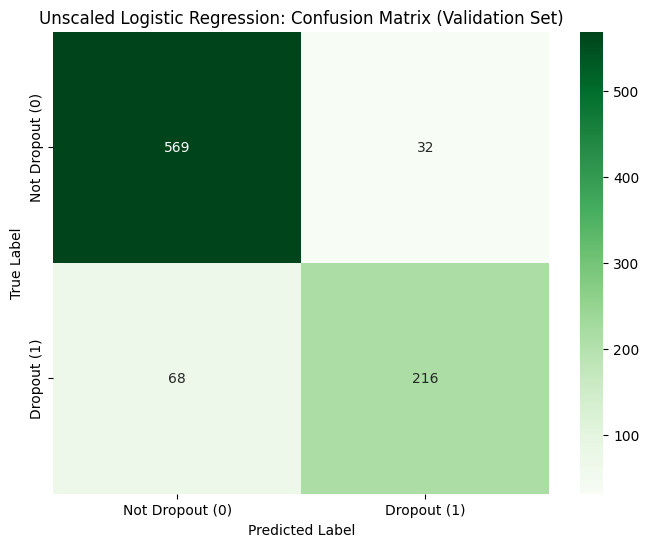


Unscaled Logistic Regression Classification Report (Validation Set):
                 precision    recall  f1-score   support

Not Dropout (0)       0.89      0.95      0.92       601
    Dropout (1)       0.87      0.76      0.81       284

       accuracy                           0.89       885
      macro avg       0.88      0.85      0.87       885
   weighted avg       0.89      0.89      0.88       885



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

if 'X' in locals() and 'y_dropout' in locals():
    print("Splitting unscaled data into training (80%) and validation (20%) sets...")
    # Use the same random_state and stratify parameters as before for consistency
    X_train_uns, X_val_uns, y_train_uns, y_val_uns = train_test_split(
        X, y_dropout, test_size=0.2, random_state=42, stratify=y_dropout
    )

    print("Training Logistic Regression on unscaled training data...")
    # Using the same hyperparameters as our true odds model
    logreg_unscaled_split = LogisticRegression(C=10, penalty='l2', solver='saga', max_iter=10000, random_state=42)
    logreg_unscaled_split.fit(X_train_uns, y_train_uns)

    print("Generating predictions on the unscaled validation set...")
    y_pred_uns = logreg_unscaled_split.predict(X_val_uns)

    # 1. Confusion Matrix
    cm_uns = confusion_matrix(y_val_uns, y_pred_uns)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_uns, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Not Dropout (0)', 'Dropout (1)'],
                yticklabels=['Not Dropout (0)', 'Dropout (1)'])
    plt.title('Unscaled Logistic Regression: Confusion Matrix (Validation Set)')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    # 2. Classification Report
    print("\nUnscaled Logistic Regression Classification Report (Validation Set):")
    print(classification_report(y_val_uns, y_pred_uns, target_names=['Not Dropout (0)', 'Dropout (1)']))
else:
    print("Data 'X' or 'y_dropout' not found. Please ensure the data preparation cells were executed.")

#Predictive Analysis

## Forward Feature Selection (Optimizing for Recall)
We will iteratively build a feature set, adding one feature at a time that maximizes the recall for the Dropout class. We use an early stopping threshold to halt the search if the performance plateaus or degrades.

Starting Forward Feature Selection...
Step 1: Added 'Curricular_units_2nd_sem_approved' | Validation Recall: 0.6725
Step 2: Added 'Curricular_units_1st_sem_evaluations' | Validation Recall: 0.7324
Step 3: Added 'Tuition_fees_up_to_date' | Validation Recall: 0.7641
Step 4: Added 'Curricular_units_2nd_sem_credited' | Validation Recall: 0.7852
Step 5: Added 'Course_Equiniculture' | Validation Recall: 0.7887
Step 6: Added 'Father's_qualification_Can_read_without_having_a_4th_year_of_schooling' | Validation Recall: 0.7923
Step 7: Added 'Educational_special_needs' | Validation Recall: 0.7923
Step 8: Added 'Curricular_units_1st_sem_without_evaluations' | Validation Recall: 0.7923
Step 9: Added 'Course_Nursing' | Validation Recall: 0.7993
Step 10: Added 'International' | Validation Recall: 0.7993
Step 11: Added 'Curricular_units_2nd_sem_evaluations' | Validation Recall: 0.7993
Step 12: Added 'Course_Veterinary_Nursing' | Validation Recall: 0.8028
Step 13: Added 'Application_mode_Transfer' | Va

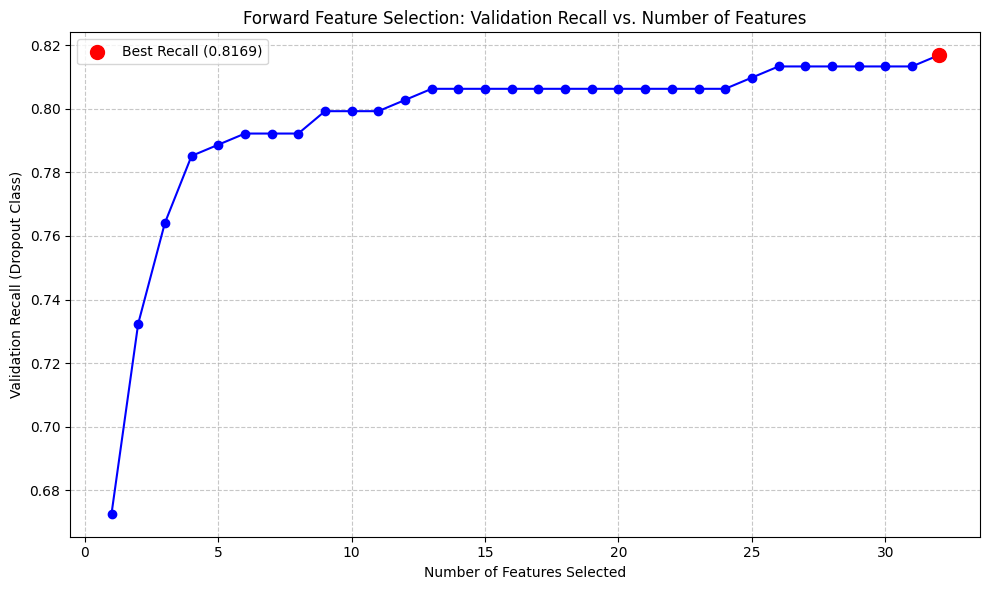

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if 'X_train_uns' in locals() and 'y_train_uns' in locals() and 'X_val_uns' in locals() and 'y_val_uns' in locals():
    print("Starting Forward Feature Selection...")

    available_features = list(X_train_uns.columns)
    selected_features = []
    best_recalls = []

    # Early stopping parameters
    patience =25
    stagnant_steps = 0
    best_overall_recall = 0
    max_features_to_select = 100 # Hard cap to prevent excessively long runtimes

    # Using a faster solver with moderate max_iter for the search process
    lr_search = LogisticRegression(C=10, penalty='l2', solver='liblinear', max_iter=200, random_state=42)

    for step in range(1, max_features_to_select + 1):
        best_step_recall = 0
        best_feature = None

        # Test all remaining features
        for feature in available_features:
            features_to_test = selected_features + [feature]

            # Train model
            lr_search.fit(X_train_uns[features_to_test], y_train_uns)

            # Predict and calculate recall on validation set (class 1 is Dropout)
            y_pred = lr_search.predict(X_val_uns[features_to_test])
            current_recall = recall_score(y_val_uns, y_pred, pos_label=1)

            if current_recall > best_step_recall:
                best_step_recall = current_recall
                best_feature = feature

        # Add the best feature of this step
        selected_features.append(best_feature)
        available_features.remove(best_feature)
        best_recalls.append(best_step_recall)

        print(f"Step {step}: Added '{best_feature}' | Validation Recall: {best_step_recall:.4f}")

        # Early Stopping Logic
        if best_step_recall > best_overall_recall:
            best_overall_recall = best_step_recall
            stagnant_steps = 0
        else:
            stagnant_steps += 1

        if stagnant_steps >= patience:
            print(f"\nEarly stopping triggered! Recall hasn't improved for {patience} steps.")
            # Revert to the best feature set
            selected_features = selected_features[:-patience]
            best_recalls = best_recalls[:-patience]
            break

    print("\n--- Feature Selection Complete ---")
    print(f"Optimal number of features: {len(selected_features)}")
    print(f"Best Validation Recall: {max(best_recalls):.4f}")

    # Visualization
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(best_recalls) + 1), best_recalls, marker='o', linestyle='-', color='b')
    plt.title('Forward Feature Selection: Validation Recall vs. Number of Features')
    plt.xlabel('Number of Features Selected')
    plt.ylabel('Validation Recall (Dropout Class)')
    plt.grid(True, linestyle='--', alpha=0.7)

    # Highlight the maximum recall point
    best_idx = np.argmax(best_recalls)
    plt.scatter(best_idx + 1, best_recalls[best_idx], color='red', s=100, label=f'Best Recall ({best_recalls[best_idx]:.4f})', zorder=5)
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("Unscaled training/validation data not found. Please ensure the split cells were executed.")

Training model on 32 selected features...
Generating predictions on the validation set...


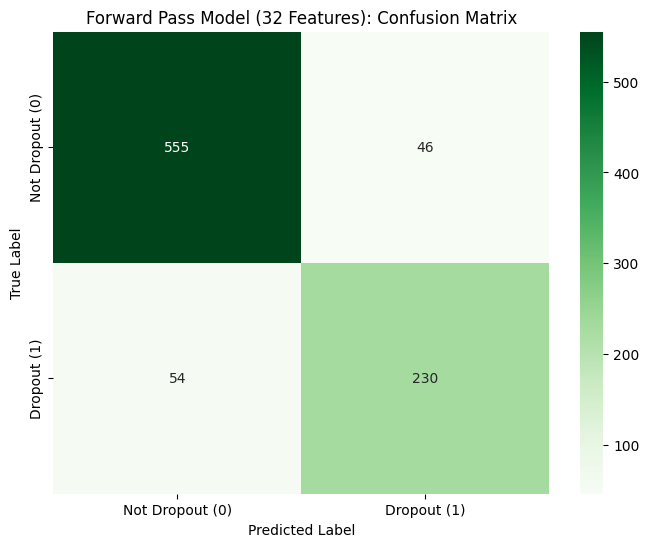


Classification Report:
                 precision    recall  f1-score   support

Not Dropout (0)       0.91      0.92      0.92       601
    Dropout (1)       0.83      0.81      0.82       284

       accuracy                           0.89       885
      macro avg       0.87      0.87      0.87       885
   weighted avg       0.89      0.89      0.89       885



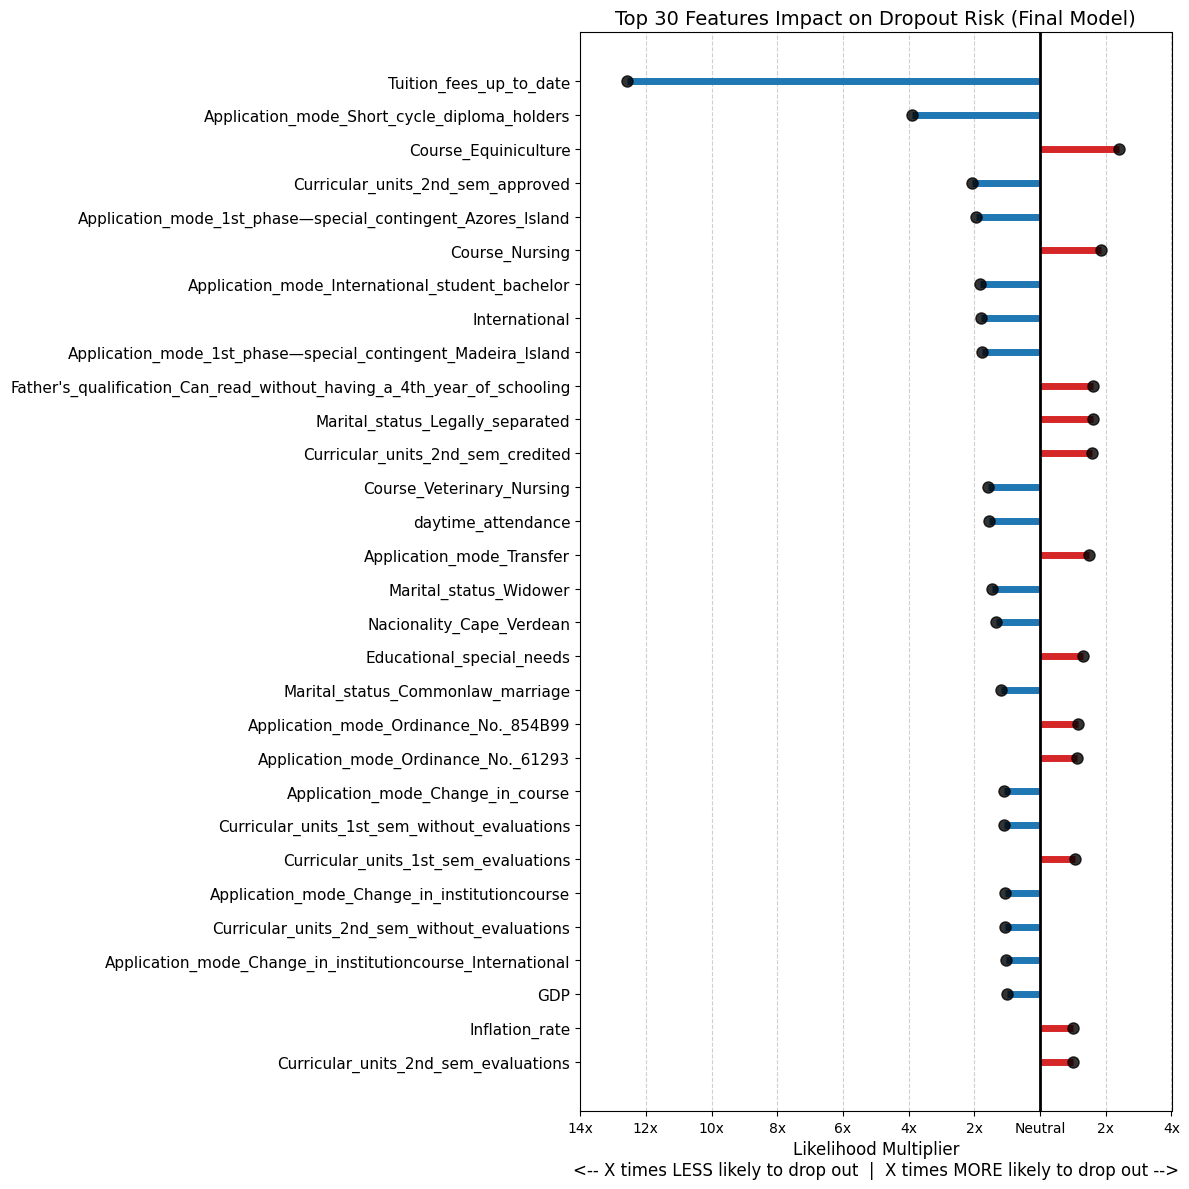


True Odds Ratios for Selected Features:


,Feature,True_Odds_Ratio
2,Tuition_fees_up_to_date,0.079
24,Application_mode_Short_cycle_diploma_holders,0.256
4,Course_Equiniculture,2.417
0,Curricular_units_2nd_sem_approved,0.482
19,Application_mode_1st_phase—special_contingent_...,0.515
8,Course_Nursing,1.857
28,Application_mode_International_student_bachelor,0.546
9,International,0.560
21,Application_mode_1st_phase—special_contingent_...,0.566
5,Father's_qualification_Can_read_without_having...,1.615


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

if 'selected_features' in locals() and 'X_train_uns' in locals():
    print(f"Training model on {len(selected_features)} selected features...")

    # 1. Train the model on the selected subset
    final_lr_model = LogisticRegression(C=10, penalty='l2', solver='saga', max_iter=10000, random_state=42)
    final_lr_model.fit(X_train_uns[selected_features], y_train_uns)

    # 2. Predictions and Confusion Matrix
    print("Generating predictions on the validation set...")
    y_pred_final = final_lr_model.predict(X_val_uns[selected_features])

    cm_final = confusion_matrix(y_val_uns, y_pred_final)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Not Dropout (0)', 'Dropout (1)'],
                yticklabels=['Not Dropout (0)', 'Dropout (1)'])
    plt.title(f'Forward Pass Model ({len(selected_features)} Features): Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_val_uns, y_pred_final, target_names=['Not Dropout (0)', 'Dropout (1)']))

    # 3. Calculate True Odds
    coefficients = final_lr_model.coef_[0]
    odds_ratios = np.exp(coefficients)

    final_odds_df = pd.DataFrame({
        'Feature': selected_features,
        'Coefficient': coefficients,
        'True_Odds_Ratio': odds_ratios
    })

    final_odds_df['Abs_Coefficient'] = final_odds_df['Coefficient'].abs()

    # Sort by absolute coefficient to get the most impactful features at the top
    top_features = final_odds_df.sort_values(by='Abs_Coefficient', ascending=False).head(30).copy()

    # Calculate likelihood multiplier for plotting
    top_features['Plot_Value'] = top_features['True_Odds_Ratio'].apply(lambda x: x if x >= 1 else -(1.0 / x))

    colors = ['#d62728' if x > 1 else '#1f77b4' for x in top_features['True_Odds_Ratio']]

    # 4. Plot Lollipop Chart
    plt.figure(figsize=(12, max(6, len(top_features) * 0.4)))

    # Lollipop chart lines and points
    plt.hlines(y=range(len(top_features)), xmin=0, xmax=top_features['Plot_Value'], color=colors, linewidth=5)
    plt.plot(top_features['Plot_Value'], range(len(top_features)), "o", markersize=8, color='black', alpha=0.8)

    plt.yticks(range(len(top_features)), top_features['Feature'], fontsize=11)
    plt.gca().invert_yaxis()

    plt.title(f'Top {len(top_features)} Features Impact on Dropout Risk (Final Model)', fontsize=14)
    plt.xlabel('Likelihood Multiplier\n<-- X times LESS likely to drop out  |  X times MORE likely to drop out -->', fontsize=12)

    plt.axvline(x=0, color='black', linestyle='-', linewidth=2)
    plt.grid(axis='x', linestyle='--', alpha=0.6)

    # Format x-ticks
    ticks = plt.gca().get_xticks()
    plt.gca().set_xticks(ticks)
    formatted_ticks = [f"{abs(int(tick))}x" if tick != 0 else "Neutral" for tick in ticks]
    plt.gca().set_xticklabels(formatted_ticks)

    plt.tight_layout()
    plt.show()

    # Display the dataframe for exact values
    print("\nTrue Odds Ratios for Selected Features:")
    display(top_features[['Feature', 'True_Odds_Ratio']].round(3))

else:
    print("Selected features or training data not found. Please run the forward selection cell first.")

## Forward Feature Selection (Random Tie-Breaking)
This version of the forward feature selection process addresses stagnation by randomly selecting among features that yield the exact same highest validation recall in a given step, rather than deterministically picking the first one.

Starting Forward Feature Selection with Random Tie-Breaking...
Step 1: Added 'Curricular_units_2nd_sem_approved' (Selected from 1 tied features) | Validation Recall: 0.6725
Step 2: Added 'Curricular_units_1st_sem_evaluations' (Selected from 1 tied features) | Validation Recall: 0.7324
Step 3: Added 'Tuition_fees_up_to_date' (Selected from 1 tied features) | Validation Recall: 0.7641
Step 4: Added 'Curricular_units_2nd_sem_credited' (Selected from 1 tied features) | Validation Recall: 0.7852
Step 5: Added 'Father's_occupation_Administrative_staff' (Selected from 10 tied features) | Validation Recall: 0.7887
Step 6: Added 'Application_mode_Transfer' (Selected from 2 tied features) | Validation Recall: 0.7923
Step 7: Added 'Father's_qualification_Can_read_without_having_a_4th_year_of_schooling' (Selected from 1 tied features) | Validation Recall: 0.7958
Step 8: Added 'Marital_status_Divorced' (Selected from 119 tied features) | Validation Recall: 0.7958
Step 9: Added 'Marital_status_Commo

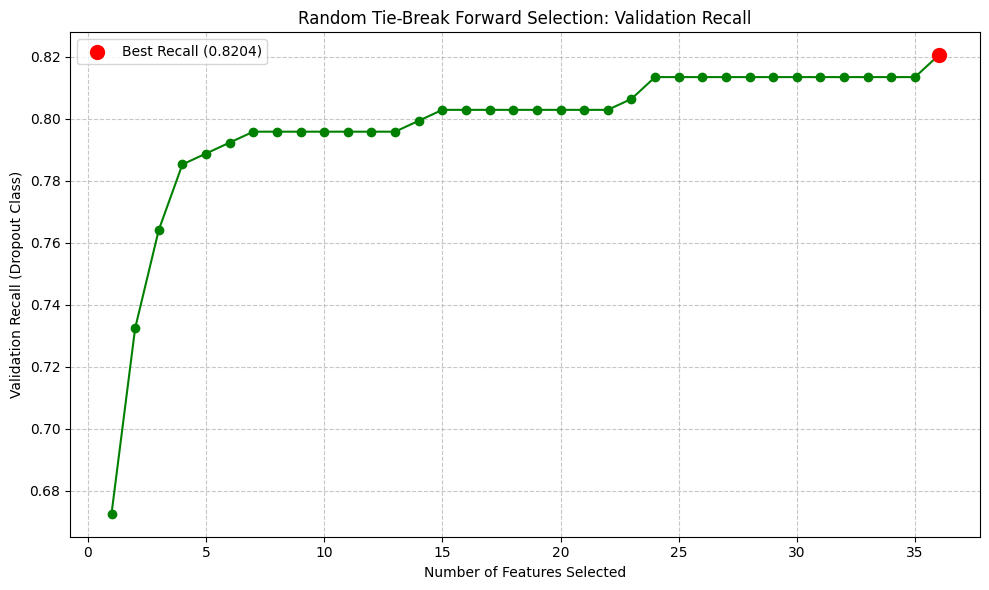

In [ ]:
import random
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if 'X_train_uns' in locals() and 'y_train_uns' in locals() and 'X_val_uns' in locals() and 'y_val_uns' in locals():
    print("Starting Forward Feature Selection with Random Tie-Breaking...")

    available_features_rand = list(X_train_uns.columns)
    selected_features_rand = []
    best_recalls_rand = []

    # Early stopping parameters
    patience = 25
    stagnant_steps = 0
    best_overall_recall = 0
    max_features_to_select = 100

    # Using a faster solver for the search process
    lr_search = LogisticRegression(C=10, penalty='l2', solver='liblinear', max_iter=200, random_state=42)

    for step in range(1, max_features_to_select + 1):
        best_step_recall = 0
        best_features_list = []

        # Test all remaining features
        for feature in available_features_rand:
            features_to_test = selected_features_rand + [feature]

            # Train model
            lr_search.fit(X_train_uns[features_to_test], y_train_uns)

            # Predict and calculate recall
            y_pred = lr_search.predict(X_val_uns[features_to_test])
            current_recall = recall_score(y_val_uns, y_pred, pos_label=1)

            if current_recall > best_step_recall:
                best_step_recall = current_recall
                best_features_list = [feature]
            elif current_recall == best_step_recall:
                best_features_list.append(feature)

        # Randomly select a feature if there's a tie
        best_feature = random.choice(best_features_list)

        # Add the chosen feature
        selected_features_rand.append(best_feature)
        available_features_rand.remove(best_feature)
        best_recalls_rand.append(best_step_recall)

        print(f"Step {step}: Added '{best_feature}' (Selected from {len(best_features_list)} tied features) | Validation Recall: {best_step_recall:.4f}")

        # Early Stopping Logic
        if best_step_recall > best_overall_recall:
            best_overall_recall = best_step_recall
            stagnant_steps = 0
        else:
            stagnant_steps += 1

        if stagnant_steps >= patience:
            print(f"\nEarly stopping triggered! Recall hasn't improved for {patience} steps.")
            selected_features_rand = selected_features_rand[:-patience]
            best_recalls_rand = best_recalls_rand[:-patience]
            break

    print("\n--- Random Tie-Break Feature Selection Complete ---")
    print(f"Optimal number of features: {len(selected_features_rand)}")
    print(f"Best Validation Recall: {max(best_recalls_rand):.4f}")

    # Visualization
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, len(best_recalls_rand) + 1), best_recalls_rand, marker='o', linestyle='-', color='g')
    plt.title('Random Tie-Break Forward Selection: Validation Recall')
    plt.xlabel('Number of Features Selected')
    plt.ylabel('Validation Recall (Dropout Class)')
    plt.grid(True, linestyle='--', alpha=0.7)

    best_idx = np.argmax(best_recalls_rand)
    plt.scatter(best_idx + 1, best_recalls_rand[best_idx], color='red', s=100, label=f'Best Recall ({best_recalls_rand[best_idx]:.4f})', zorder=5)
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("Unscaled training/validation data not found. Please ensure the split cells were executed.")

## Final Model Evaluation (Random Tie-Break Features)
Let's evaluate the model built using the features selected via the random tie-breaking approach.

Training final model on 36 selected features (Random Tie-Break)...
Generating predictions on the validation set...


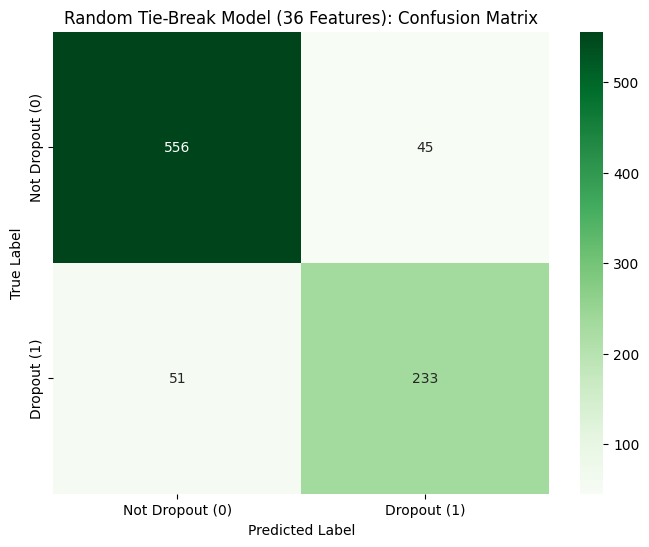


Classification Report (Random Tie-Break):
                 precision    recall  f1-score   support

Not Dropout (0)       0.92      0.93      0.92       601
    Dropout (1)       0.84      0.82      0.83       284

       accuracy                           0.89       885
      macro avg       0.88      0.87      0.87       885
   weighted avg       0.89      0.89      0.89       885



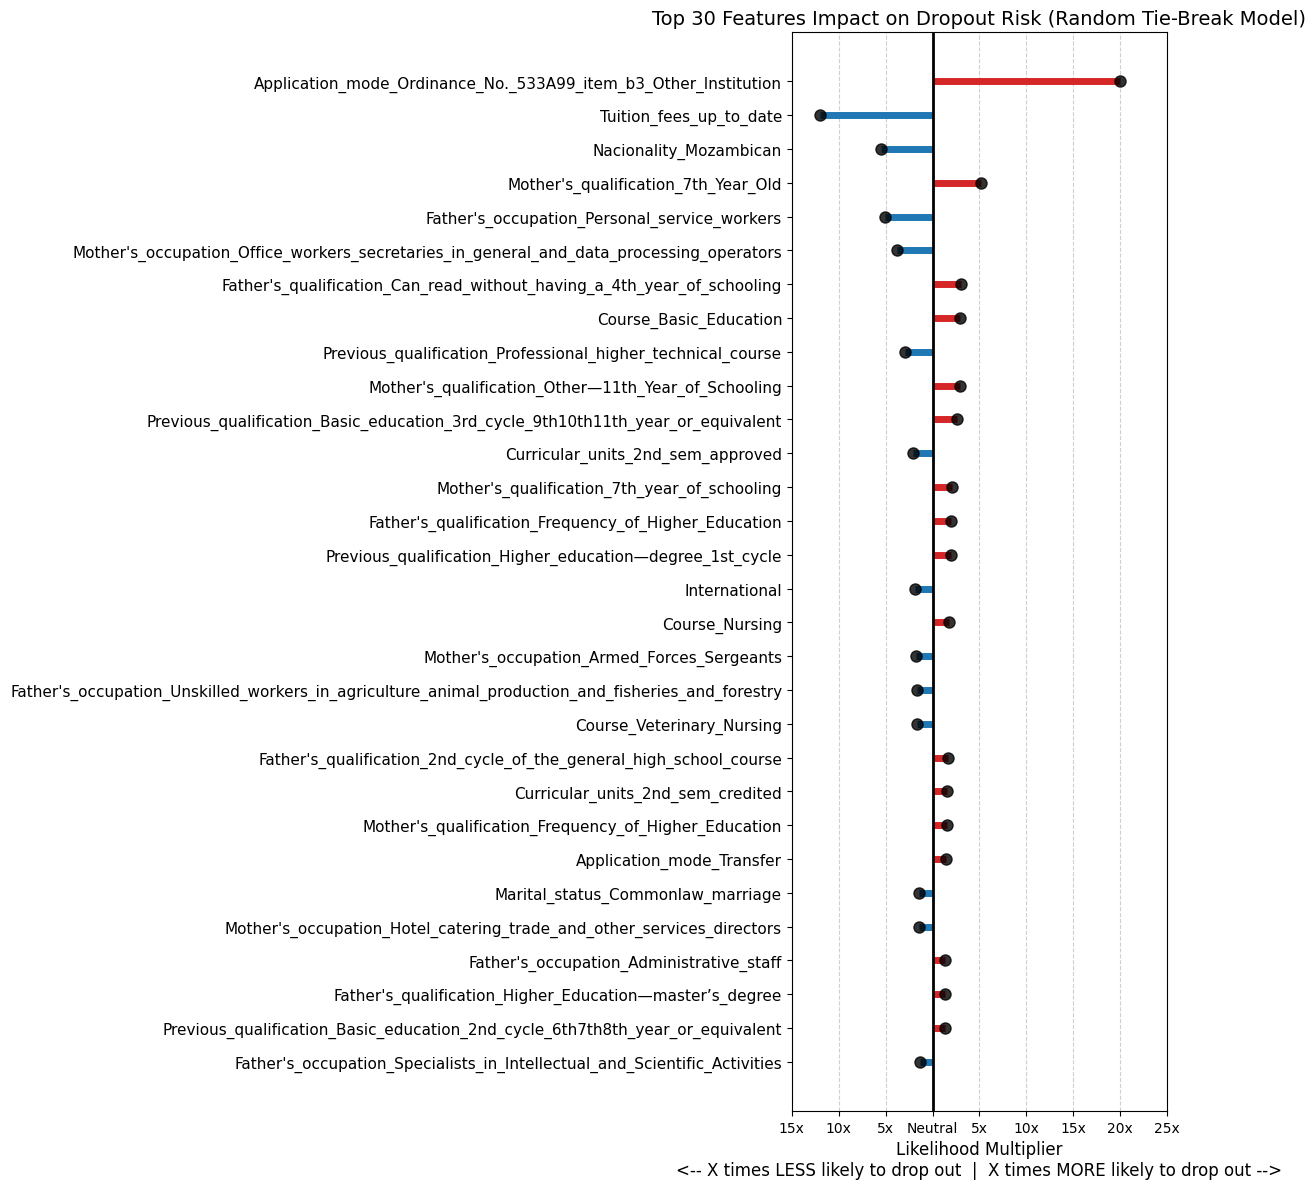


True Odds Ratios for Selected Features (Random Tie-Break):


,Feature,True_Odds_Ratio
9,Application_mode_Ordinance_No._533A99_item_b3_...,20.004
2,Tuition_fees_up_to_date,0.083
26,Nacionality_Mozambican,0.181
27,Mother's_qualification_7th_Year_Old,5.171
15,Father's_occupation_Personal_service_workers,0.198
16,Mother's_occupation_Office_workers_secretaries...,0.265
6,Father's_qualification_Can_read_without_having...,3.074
23,Course_Basic_Education,2.921
14,Previous_qualification_Professional_higher_tec...,0.344
25,Mother's_qualification_Other—11th_Year_of_Scho...,2.892


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

if 'selected_features_rand' in locals() and 'X_train_uns' in locals():
    print(f"Training final model on {len(selected_features_rand)} selected features (Random Tie-Break)...")

    # 1. Train the final model
    final_lr_model_rand = LogisticRegression(C=10, penalty='l2', solver='saga', max_iter=10000, random_state=42)
    final_lr_model_rand.fit(X_train_uns[selected_features_rand], y_train_uns)

    # 2. Predictions and Confusion Matrix
    print("Generating predictions on the validation set...")
    y_pred_final_rand = final_lr_model_rand.predict(X_val_uns[selected_features_rand])

    cm_final_rand = confusion_matrix(y_val_uns, y_pred_final_rand)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_final_rand, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Not Dropout (0)', 'Dropout (1)'],
                yticklabels=['Not Dropout (0)', 'Dropout (1)'])
    plt.title(f'Random Tie-Break Model ({len(selected_features_rand)} Features): Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    print("\nClassification Report (Random Tie-Break):")
    print(classification_report(y_val_uns, y_pred_final_rand, target_names=['Not Dropout (0)', 'Dropout (1)']))

    # 3. Calculate True Odds
    coefficients_rand = final_lr_model_rand.coef_[0]
    odds_ratios_rand = np.exp(coefficients_rand)

    final_odds_df_rand = pd.DataFrame({
        'Feature': selected_features_rand,
        'Coefficient': coefficients_rand,
        'True_Odds_Ratio': odds_ratios_rand
    })

    final_odds_df_rand['Abs_Coefficient'] = final_odds_df_rand['Coefficient'].abs()

    # Sort by absolute coefficient to get the most impactful features at the top
    top_features_rand = final_odds_df_rand.sort_values(by='Abs_Coefficient', ascending=False).head(30).copy()

    # Calculate likelihood multiplier for plotting
    top_features_rand['Plot_Value'] = top_features_rand['True_Odds_Ratio'].apply(lambda x: x if x >= 1 else -(1.0 / x))

    colors_rand = ['#d62728' if x > 1 else '#1f77b4' for x in top_features_rand['True_Odds_Ratio']]

    # 4. Plot Lollipop Chart
    plt.figure(figsize=(12, max(6, len(top_features_rand) * 0.4)))

    # Lollipop chart lines and points
    plt.hlines(y=range(len(top_features_rand)), xmin=0, xmax=top_features_rand['Plot_Value'], color=colors_rand, linewidth=5)
    plt.plot(top_features_rand['Plot_Value'], range(len(top_features_rand)), "o", markersize=8, color='black', alpha=0.8)

    plt.yticks(range(len(top_features_rand)), top_features_rand['Feature'], fontsize=11)
    plt.gca().invert_yaxis()

    plt.title(f'Top {len(top_features_rand)} Features Impact on Dropout Risk (Random Tie-Break Model)', fontsize=14)
    plt.xlabel('Likelihood Multiplier\n<-- X times LESS likely to drop out  |  X times MORE likely to drop out -->', fontsize=12)

    plt.axvline(x=0, color='black', linestyle='-', linewidth=2)
    plt.grid(axis='x', linestyle='--', alpha=0.6)

    # Format x-ticks
    ticks = plt.gca().get_xticks()
    plt.gca().set_xticks(ticks)
    formatted_ticks = [f"{abs(int(tick))}x" if tick != 0 else "Neutral" for tick in ticks]
    plt.gca().set_xticklabels(formatted_ticks)

    plt.tight_layout()
    plt.show()

    # Display the dataframe for exact values
    print("\nTrue Odds Ratios for Selected Features (Random Tie-Break):")
    display(top_features_rand[['Feature', 'True_Odds_Ratio']].round(3))

else:
    print("Selected features or training data not found. Please run the random tie-break selection cell first.")

# Logistic Regression Models Comparison
Comparing Accuracy, Precision, Recall, and F1-Score (focusing on the Dropout class) across all Logistic Regression variations we've trained.

--- Logistic Regression Models Performance Summary ---


,Model,Accuracy,Precision (Dropout),Recall (Dropout),F1-Score (Dropout)
0,Base LR (Scaled),0.888136,0.893617,0.739437,0.809249
1,Tuned LR (Scaled),0.884746,0.866935,0.757042,0.808271
2,Tuned LR (Unscaled),0.887006,0.870968,0.760563,0.812030
3,Forward Selection LR (32 features),0.887006,0.833333,0.809859,0.821429
4,Random Tie-Break LR (36 features),0.891525,0.838129,0.820423,0.829181


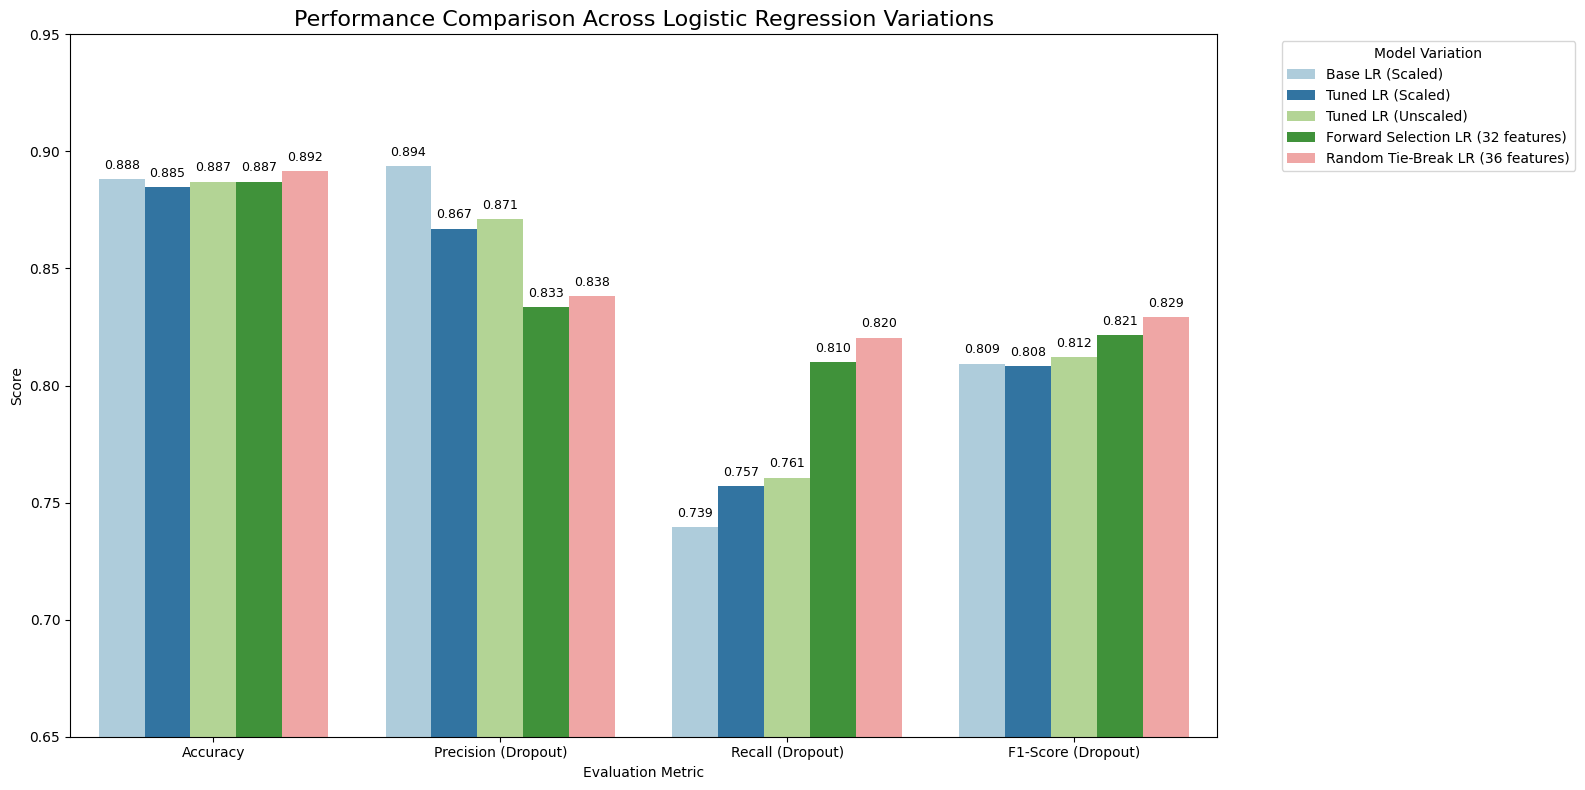

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

results_lr = []

# Helper function to get metrics
def get_metrics(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=[1])
    return {
        'Model': name,
        'Accuracy': acc,
        'Precision (Dropout)': precision[0],
        'Recall (Dropout)': recall[0],
        'F1-Score (Dropout)': f1[0]
    }

# 1. Base Logistic Regression (Scaled)
if 'logreg' in locals() and 'X_val' in locals() and 'y_val' in locals():
    y_pred = logreg.predict(X_val)
    results_lr.append(get_metrics('Base LR (Scaled)', y_val, y_pred))

# 2. Tuned Logistic Regression (Scaled)
if 'best_logreg' in locals() and 'X_val' in locals() and 'y_val' in locals():
    y_pred = best_logreg.predict(X_val)
    results_lr.append(get_metrics('Tuned LR (Scaled)', y_val, y_pred))

# 3. Base Logistic Regression (Unscaled)
if 'logreg_unscaled_split' in locals() and 'X_val_uns' in locals() and 'y_val_uns' in locals():
    y_pred = logreg_unscaled_split.predict(X_val_uns)
    results_lr.append(get_metrics('Tuned LR (Unscaled)', y_val_uns, y_pred))

# 4. Forward Selection LR (32 features)
if 'final_lr_model' in locals() and 'X_val_uns' in locals() and 'y_val_uns' in locals() and 'selected_features' in locals():
    y_pred = final_lr_model.predict(X_val_uns[selected_features])
    results_lr.append(get_metrics('Forward Selection LR (32 features)', y_val_uns, y_pred))

# 5. Random Tie-Break Selection LR
if 'final_lr_model_rand' in locals() and 'X_val_uns' in locals() and 'y_val_uns' in locals() and 'selected_features_rand' in locals():
    y_pred = final_lr_model_rand.predict(X_val_uns[selected_features_rand])
    results_lr.append(get_metrics(f'Random Tie-Break LR ({len(selected_features_rand)} features)', y_val_uns, y_pred))

if not results_lr:
    print("No Logistic Regression models found to compare.")
else:
    results_lr_df = pd.DataFrame(results_lr)

    print("--- Logistic Regression Models Performance Summary ---")
    display(results_lr_df)

    # Melt for seaborn
    results_lr_melted = results_lr_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

    # Plot
    plt.figure(figsize=(16, 8))
    sns.barplot(x='Metric', y='Score', hue='Model', data=results_lr_melted, palette='Paired')
    plt.title('Performance Comparison Across Logistic Regression Variations', fontsize=16)
    plt.ylabel('Score')
    plt.xlabel('Evaluation Metric')
    plt.ylim(0.65, 0.95)  # Zoom in on the relevant range

    # Add value labels
    ax = plt.gca()
    for p in ax.patches:
        height = p.get_height()
        if not pd.isna(height) and height > 0:
            ax.annotate(f"{height:.3f}", (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='center', fontsize=9, color='black', xytext=(0, 10),
                        textcoords='offset points')

    plt.legend(title='Model Variation', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


# Deep Learning

## Data Preparation

In [32]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import numpy as np

class StudentDataset(Dataset):
    def __init__(self, features, labels):
        # Convert NumPy/Pandas data to PyTorch tensors
        self.features = torch.tensor(features.values, dtype=torch.float32)
        self.labels = torch.tensor(labels.values, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Split the existing training set into training and test
X_train_final, X_test, y_train_final, y_test = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print(f"Training samples: {len(X_train_final)}")
print(f"Validation samples: {len(X_val)}")
print(f"Test samples: {len(X_test)}")

# Create the DataLoaders
train_dataset = StudentDataset(X_train_final, y_train_final)
val_dataset = StudentDataset(X_val, y_val) # Keep your original validation set
test_dataset = StudentDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Check first batch
features, labels = next(iter(train_loader))
print(f"\nFeature batch shape: {features.shape}")
print(f"Target batch shape: {labels.shape}")

Training samples: 2831
Validation samples: 885
Test samples: 708

Feature batch shape: torch.Size([32, 245])
Target batch shape: torch.Size([32])


## Simple MLP

In [33]:

class StudentMultiLayerPerceptron(nn.Module):
    def __init__(self, input_dim, num_classes=3):
        super(StudentMultiLayerPerceptron, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# Input_dim should match X_train columns
input_dim = X_train.shape[1]
model = StudentMultiLayerPerceptron(input_dim=input_dim, num_classes=2)

print(model)
# Count total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters: {total_params:,}")

StudentMultiLayerPerceptron(
  (network): Sequential(
    (0): Linear(in_features=245, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=2, bias=True)
  )
)

Total Trainable Parameters: 17,890


In [34]:
# Calculate weights inversely proportional to class frequency
import numpy as np
counts = np.bincount(y_train_final)
weights = 1 / torch.tensor(counts, dtype=torch.float32)
weights = weights / weights.sum()

# Cross-Entropy Loss with ADAM optimizer
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(f"Class counts in training: {counts}")
print(f"Calculated weights: {weights}")

Class counts in training: [1921  910]
Calculated weights: tensor([0.3214, 0.6786])


In [35]:
def train_model_smart(model, train_loader, val_loader, criterion, optimizer, epochs=100, patience=10):
    """Train the provided model with the provided data. Includes LR adjustment and early stopping"""

    # Scheduler adjusts learning rate as the model stops improving
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

    best_val_loss = float('inf')
    counter = 0  # Track how many epochs without improvement
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)

        # Update the scheduler
        scheduler.step(avg_val_loss)

        print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            counter = 0
            # Save the best model
            os.makedirs("models", exist_ok=True)
            torch.save(model.state_dict(), 'models/best_student_model.pt')
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping triggered! No improvement for {patience} epochs.")
                # Load the best model when finished
                model.load_state_dict(torch.load('models/best_student_model.pt'))
                break


# Train the model (with early stopping)
train_model_smart(model, train_loader, val_loader, criterion, optimizer, epochs=100, patience=10)

Epoch 1: Train Loss: 0.6479 | Val Loss: 0.5108
Epoch 2: Train Loss: 0.4764 | Val Loss: 0.4160
Epoch 3: Train Loss: 0.4187 | Val Loss: 0.3913
Epoch 4: Train Loss: 0.3948 | Val Loss: 0.3764
Epoch 5: Train Loss: 0.3631 | Val Loss: 0.3772
Epoch 6: Train Loss: 0.3551 | Val Loss: 0.3658
Epoch 7: Train Loss: 0.3543 | Val Loss: 0.3646
Epoch 8: Train Loss: 0.3439 | Val Loss: 0.3646
Epoch 9: Train Loss: 0.3274 | Val Loss: 0.3650
Epoch 10: Train Loss: 0.3245 | Val Loss: 0.3661
Epoch 11: Train Loss: 0.3261 | Val Loss: 0.3603
Epoch 12: Train Loss: 0.3146 | Val Loss: 0.3563
Epoch 13: Train Loss: 0.3070 | Val Loss: 0.3711
Epoch 14: Train Loss: 0.3076 | Val Loss: 0.3768
Epoch 15: Train Loss: 0.2939 | Val Loss: 0.3706
Epoch 16: Train Loss: 0.2875 | Val Loss: 0.3730
Epoch 17: Train Loss: 0.2810 | Val Loss: 0.3675
Epoch 18: Train Loss: 0.2665 | Val Loss: 0.3705
Epoch 19: Train Loss: 0.2747 | Val Loss: 0.3671
Epoch 20: Train Loss: 0.2628 | Val Loss: 0.3744
Epoch 21: Train Loss: 0.2524 | Val Loss: 0.3761
E

Deep Learning Model Performance:
              precision    recall  f1-score   support

       Other       0.91      0.89      0.90       481
     Dropout       0.77      0.81      0.79       227

    accuracy                           0.86       708
   macro avg       0.84      0.85      0.84       708
weighted avg       0.86      0.86      0.86       708



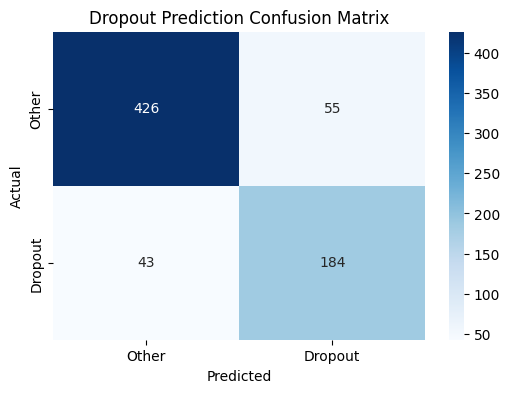

ROC-AUC: 0.928178262980025


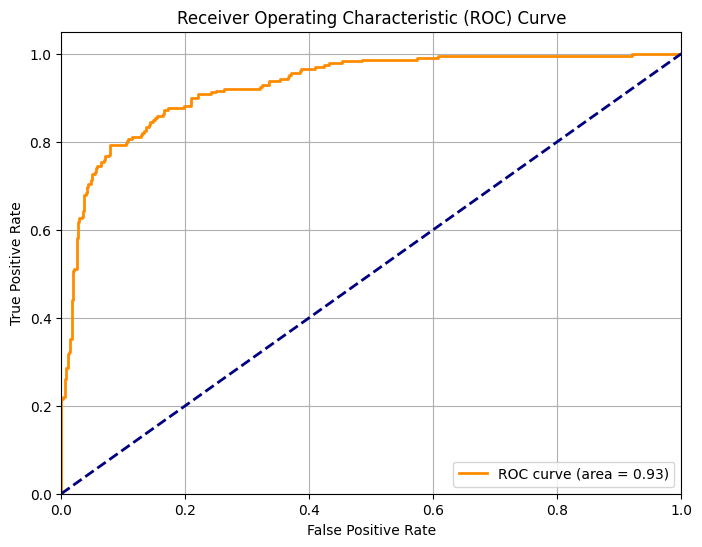

In [36]:
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as functional

def evaluate_model(model, test_loader):
    """Evaluate the provided model with the test data and display results (Should work for any PyTorch models, hopefully?)"""
    model.eval() # Set model to eval mode
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad(): # No gradients needed for testing
        for inputs, labels in test_loader:
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            probs = functional.softmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    # Print results
    print("Deep Learning Model Performance:")
    print(classification_report(all_labels, all_preds, target_names=['Other', 'Dropout']))

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Other', 'Dropout'], yticklabels=['Other', 'Dropout'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Dropout Prediction Confusion Matrix')
    plt.show()

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
    print("ROC-AUC:", roc_auc)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

evaluate_model(model, test_loader)


## MLP Hyperparameter Tuning

In [38]:
class FlexibleMLP(nn.Module):
    """This class can be tuned, with variable values for all hyperparameters"""
    def __init__(self, input_dim, hidden_dims, dropout_rate, use_batchnorm=False, num_classes=2):
        super().__init__()
        layers = []
        in_features = input_dim
        for hidden_size in hidden_dims:
            layers.append(nn.Linear(in_features, hidden_size))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            in_features = hidden_size
        layers.append(nn.Linear(in_features, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def train_and_evaluate(model, train_loader, val_loader, criterion, lr, weight_decay=0, epochs=100, patience=10, model_path='models/hp_best.pt'):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=3, factor=0.5
    )

    best_val_loss = float('inf')
    best_val_recall = 0.0
    counter = 0
    os.makedirs(os.path.dirname(model_path), exist_ok=True)

    for epoch in range(epochs):
        # Training
        model.train()
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(inputs), labels)
            loss.backward()
            optimizer.step()

        # Validation
        model.eval()
        val_loss = 0.0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in val_loader:
                outputs = model(inputs)
                val_loss += criterion(outputs, labels).item()
                preds = outputs.argmax(dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_recall = recall_score(all_labels, all_preds, pos_label=1, zero_division=0)
        scheduler.step(avg_val_loss)

        # Track best weights; record recall
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_val_recall = val_recall
            counter = 0
            torch.save(model.state_dict(), model_path)
        else:
            counter += 1
            if counter >= patience:
                break

    # Restore best weights
    model.load_state_dict(torch.load(model_path))
    return best_val_recall

In [39]:
import itertools
SKIP_MLP_TUNING = True  # This takes a long time, so you can skip it and just use the best results from my previous run

if not SKIP_MLP_TUNING:
    # Grid search for parameters
    param_grid = {
        'hidden_dims'    : [[64], [128, 64], [256, 128], [256, 128, 64]],
        'dropout_rate'   : [0.2, 0.4],
        'lr'             : [1e-3, 3e-4],
        'batch_size'     : [32, 64],
        'use_batchnorm'  : [True, False],
        'weight_decay'   : [0, 1e-4, 1e-3],
    }

    # Build all combinations
    keys   = list(param_grid.keys())
    combos = list(itertools.product(*param_grid.values()))
    print(f"Total configurations to evaluate: {len(combos)}")

    # Class weights
    counts  = np.bincount(y_train_final)
    weights = 1 / torch.tensor(counts, dtype=torch.float32)
    weights = weights / weights.sum()
    criterion_hp = nn.CrossEntropyLoss(weight=weights)

    input_dim_hp = X_train_final.shape[1]

    # Grid search loop
    results_hp = []
    for i, combo in enumerate(combos):
        params = dict(zip(keys, combo))
        print(f"\n[{i+1}/{len(combos)}] Testing: {params}")

        # Ensure shuffle is consistent
        g = torch.Generator()
        g.manual_seed(SEED)

        # Build data loaders
        bs = params['batch_size']
        train_loader_hp = DataLoader(train_dataset, batch_size=bs, shuffle=True)
        val_loader_hp   = DataLoader(val_dataset,   batch_size=bs, shuffle=False)

        # Build a fresh model
        candidate_model = FlexibleMLP(
            input_dim=input_dim_hp,
            hidden_dims=params['hidden_dims'],
            dropout_rate=params['dropout_rate'],
            use_batchnorm=params['use_batchnorm'],
            num_classes=2
        )

        # Train the model
        val_recall = train_and_evaluate(
            model=candidate_model,
            train_loader=train_loader_hp,
            val_loader=val_loader_hp,
            criterion=criterion_hp,
            lr=params['lr'],
            epochs=100,
            patience=10,
            model_path=f'models/hp_candidate_{i}.pt'
        )

        print(f"  -> Val Recall (Dropout): {val_recall:.4f}")
        results_hp.append({**params, 'val_recall': val_recall, 'model_idx': i})

    # Collect into data frame and sort
    results_hp_df = pd.DataFrame(results_hp).sort_values('val_recall', ascending=False)
    results_hp_df['hidden_dims'] = results_hp_df['hidden_dims'].astype(str)

    print("\n=== Grid Search Complete ===")
    display(results_hp_df.reset_index(drop=True))

    # Identify best config
    best_row = results_hp_df.iloc[0]
else:
    best_row = {
        'hidden_dims'    : "[256, 128, 64]",
        'dropout_rate'   : "0.2",
        'lr'             : "1e-3",
        'batch_size'     : "32",
        'use_batchnorm'  : False,
        'weight_decay'   : "1e-3",
    }
    print("Skipping MLP hyperparameter tuning; using best previous results:", best_row)

Skipping MLP hyperparameter tuning; using best previous results: {'hidden_dims': '[256, 128, 64]', 'dropout_rate': '0.2', 'lr': '1e-3', 'batch_size': '32', 'use_batchnorm': False, 'weight_decay': '1e-3'}


In [40]:
# Reconstruct from the string representation
import ast
best_hidden_dims = ast.literal_eval(best_row['hidden_dims'])
best_dropout_rate = float(best_row['dropout_rate'])
best_lr = float(best_row['lr'])
best_batchnorm = bool(best_row['use_batchnorm'])
best_weight_decay = float(best_row['weight_decay'])
best_batch_size = int(best_row['batch_size'])

print("Best Hyperparameters:")
print(f"  hidden_dims  : {best_hidden_dims}")
print(f"  dropout_rate : {best_dropout_rate}")
print(f"  lr           : {best_lr}")
print(f"  use_batchnorm: {best_batchnorm}")
print(f"  weight_decay : {best_weight_decay}")
print(f"  batch_size   : {best_batch_size}")

best_mlp = FlexibleMLP(
    input_dim=X_train_final.shape[1],
    hidden_dims=best_hidden_dims,
    dropout_rate=best_dropout_rate,
    use_batchnorm=best_batchnorm,
    num_classes=2
)

if "model_idx" in best_row.keys() and os.path.exists(model_path := f"models/hp_candidate_{int(best_row['model_idx'])}.pt"):
    print("Loading saved best model weights...")
    best_mlp.load_state_dict(torch.load(model_path))
else:
    print("No saved model found — retraining best model...")

    optimizer = torch.optim.Adam(
        best_mlp.parameters(),
        lr=best_lr,
        weight_decay=best_weight_decay
    )

    criterion = nn.CrossEntropyLoss()

    train_model_smart(
        model=best_mlp,
        train_loader=DataLoader(train_dataset, batch_size=best_batch_size, shuffle=True),
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        epochs=100,
        patience=10
    )

print("\nBest MLP Architecture:")
print(best_mlp)

Best Hyperparameters:
  hidden_dims  : [256, 128, 64]
  dropout_rate : 0.2
  lr           : 0.001
  use_batchnorm: False
  weight_decay : 0.001
  batch_size   : 32
No saved model found — retraining best model...
Epoch 1: Train Loss: 0.5160 | Val Loss: 0.4008
Epoch 2: Train Loss: 0.3665 | Val Loss: 0.3430
Epoch 3: Train Loss: 0.3353 | Val Loss: 0.3394
Epoch 4: Train Loss: 0.3234 | Val Loss: 0.3376
Epoch 5: Train Loss: 0.3016 | Val Loss: 0.3165
Epoch 6: Train Loss: 0.2968 | Val Loss: 0.3215
Epoch 7: Train Loss: 0.2811 | Val Loss: 0.3120
Epoch 8: Train Loss: 0.2752 | Val Loss: 0.3039
Epoch 9: Train Loss: 0.2600 | Val Loss: 0.3181
Epoch 10: Train Loss: 0.2456 | Val Loss: 0.3342
Epoch 11: Train Loss: 0.2291 | Val Loss: 0.3211
Epoch 12: Train Loss: 0.2194 | Val Loss: 0.3493
Epoch 13: Train Loss: 0.1892 | Val Loss: 0.3531
Epoch 14: Train Loss: 0.1634 | Val Loss: 0.3701
Epoch 15: Train Loss: 0.1583 | Val Loss: 0.3838
Epoch 16: Train Loss: 0.1408 | Val Loss: 0.3746
Epoch 17: Train Loss: 0.1239 

Deep Learning Model Performance:
              precision    recall  f1-score   support

       Other       0.89      0.93      0.91       481
     Dropout       0.83      0.75      0.79       227

    accuracy                           0.87       708
   macro avg       0.86      0.84      0.85       708
weighted avg       0.87      0.87      0.87       708



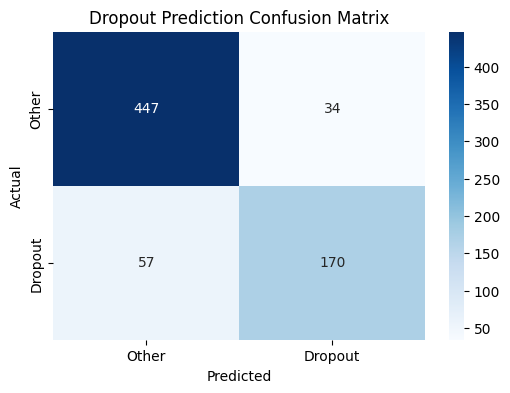

ROC-AUC: 0.924011100222554


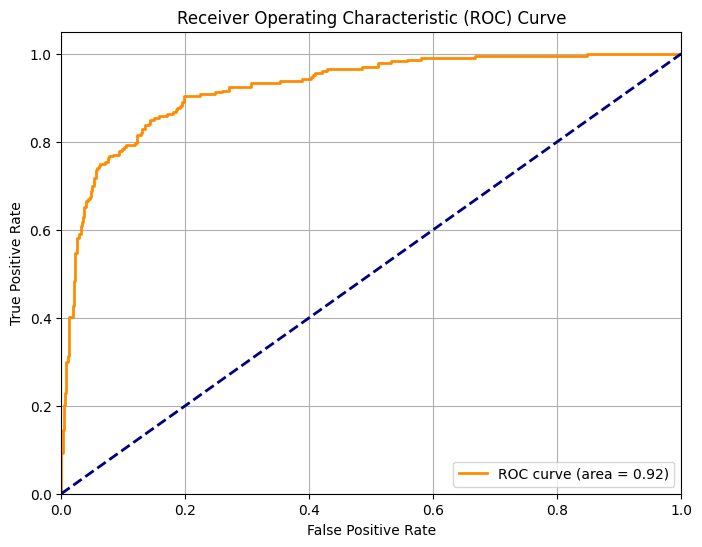

In [46]:
test_loader_best = DataLoader(test_dataset, batch_size=best_batch_size, shuffle=False)

# Evaluate on test set
evaluate_model(best_mlp, test_loader_best)

## SMOTE + Focal Loss

In [47]:
from imblearn.over_sampling import SMOTE

# Build SMOTE-resampled dataset
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train_final, y_train_final)

train_dataset_smote = StudentDataset(X_res, y_res)

train_loader_smote = DataLoader(
    train_dataset_smote,
    batch_size=best_batch_size,
    shuffle=True
)


In [48]:
import torch.nn.functional as F
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # inputs: raw logits (NO softmax)
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')

        pt = torch.exp(-ce_loss)  # probability of correct class

        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [49]:
model_smote = FlexibleMLP(
    input_dim=X_train_final.shape[1],
    hidden_dims=best_hidden_dims,
    dropout_rate=best_dropout_rate,
    use_batchnorm=best_batchnorm,
    num_classes=2
)

optimizer_smote = torch.optim.Adam(
    model_smote.parameters(),
    lr=best_lr,
    weight_decay=best_weight_decay
)

# Use focal loss
criterion_smote = FocalLoss(alpha=1.0, gamma=2.0)

In [50]:
import torch.nn.functional as F

train_model_smart(
    model=model_smote,
    train_loader=train_loader_smote,
    val_loader=val_loader,
    criterion=criterion_smote,
    optimizer=optimizer_smote,
    epochs=100,
    patience=10
)

Epoch 1: Train Loss: 0.1239 | Val Loss: 0.0928
Epoch 2: Train Loss: 0.0978 | Val Loss: 0.0920
Epoch 3: Train Loss: 0.0921 | Val Loss: 0.0833
Epoch 4: Train Loss: 0.0868 | Val Loss: 0.0990
Epoch 5: Train Loss: 0.0827 | Val Loss: 0.0853
Epoch 6: Train Loss: 0.0738 | Val Loss: 0.0933
Epoch 7: Train Loss: 0.0709 | Val Loss: 0.0845
Epoch 8: Train Loss: 0.0626 | Val Loss: 0.0899
Epoch 9: Train Loss: 0.0537 | Val Loss: 0.0951
Epoch 10: Train Loss: 0.0483 | Val Loss: 0.1032
Epoch 11: Train Loss: 0.0449 | Val Loss: 0.1002
Epoch 12: Train Loss: 0.0349 | Val Loss: 0.1099
Epoch 13: Train Loss: 0.0313 | Val Loss: 0.1136
Early stopping triggered! No improvement for 10 epochs.


Deep Learning Model Performance:
              precision    recall  f1-score   support

       Other       0.88      0.94      0.91       481
     Dropout       0.84      0.74      0.79       227

    accuracy                           0.87       708
   macro avg       0.86      0.84      0.85       708
weighted avg       0.87      0.87      0.87       708



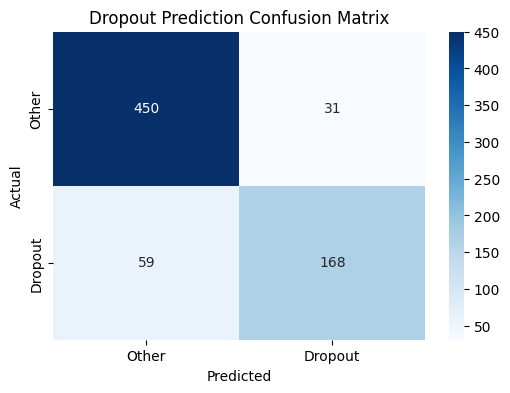

ROC-AUC: 0.9270517552455879


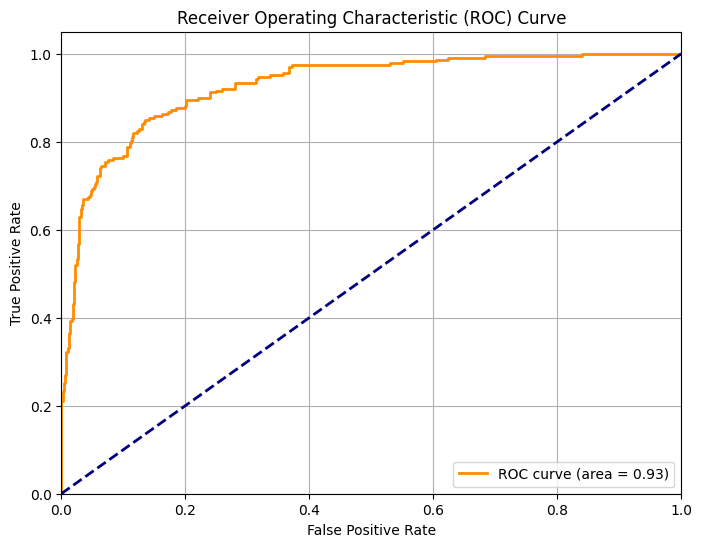

In [51]:
evaluate_model(model_smote, test_loader_best)

# Ablation Study

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

required_vars = ["X_train", "X_val", "y_train", "y_val"]

missing_vars = [var for var in required_vars if var not in globals()]

if missing_vars:
    print("Missing required variables:", missing_vars)
    print("Please run the earlier preprocessing/modeling cells first.")
else:
    print("All required variables found.")
    print("Training shape:", X_train.shape)
    print("Validation shape:", X_val.shape)

All required variables found.
Training shape: (3539, 245)
Validation shape: (885, 245)


In [55]:
# Define feature groups for ablation

feature_groups = {
    "Academic performance features": [
        "Curricular_units",
        "Grade",
        "Admission_grade",
        "Previous_qualification"
    ],

    "Financial features": [
        "Debtor",
        "Tuition_fees_up_to_date",
        "Scholarship_holder"
    ],

    "Demographic features": [
        "Age",
        "Gender",
        "Marital_status",
        "Nationality",
        "Displaced",
        "International"
    ],

    "Family background features": [
        "Mothers_qualification",
        "Fathers_qualification",
        "Mothers_occupation",
        "Fathers_occupation"
    ],

    "Application/enrollment features": [
        "Application_mode",
        "Application_order",
        "Course",
        "Daytime_evening_attendance"
    ],

    "Macroeconomic features": [
        "Unemployment_rate",
        "Inflation_rate",
        "GDP"
    ]
}


def get_matching_columns(columns, keywords):
    """
    Finds columns whose names contain any keyword in the feature group.
    This works even after one-hot encoding because one-hot column names
    usually preserve the original variable name.
    """
    matching_cols = []

    for col in columns:
        for keyword in keywords:
            if keyword.lower() in col.lower():
                matching_cols.append(col)
                break

    return matching_cols


# Show which columns will be removed for each ablation
for group_name, keywords in feature_groups.items():
    matched_cols = get_matching_columns(X_train.columns, keywords)
    print(f"\n{group_name}: {len(matched_cols)} columns")
    print(matched_cols[:10])

    if len(matched_cols) > 10:
        print("...")


Academic performance features: 29 columns
['Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved']
...

Financial features: 3 columns
['Debtor', 'Tuition_fees_up_to_date', 'Scholarship_holder']

Demographic features: 16 columns
['Displaced', 'Age_at_enrollment', 'International', 'Marital_status_Commonlaw_marriage', 'Marital_status_Divorced', 'Marital_status_Legally_separated', 'Marital_status_Married', 'Marital_status_Single', 'Marital_status_Widower', 'Application_mode_Change_in_institutioncourse_International']
...

Family background features: 0 columns
[]

Application/enrollment features: 56 columns
['Application_order', 'Application_mode_1st_phase—general_con

In [56]:
if "best_logreg" in globals():
    ablation_base_model = clone(best_logreg)
    print("Using best_logreg from earlier notebook as the ablation model.")
else:
    ablation_base_model = LogisticRegression(
        max_iter=2000,
        random_state=42,
        class_weight="balanced"
    )
    print("best_logreg not found. Using a new balanced LogisticRegression model.")

best_logreg not found. Using a new balanced LogisticRegression model.


In [57]:
def evaluate_ablation_model(model, X_train_subset, X_val_subset, y_train, y_val, experiment_name):
    """
    Trains the model on the selected features and evaluates performance
    on the validation set.
    """
    model.fit(X_train_subset, y_train)
    y_pred = model.predict(X_val_subset)

    results = {
        "Experiment": experiment_name,
        "Number of Features": X_train_subset.shape[1],
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision_Dropout": precision_score(y_val, y_pred, pos_label=1, zero_division=0),
        "Recall_Dropout": recall_score(y_val, y_pred, pos_label=1, zero_division=0),
        "F1_Dropout": f1_score(y_val, y_pred, pos_label=1, zero_division=0)
    }

    return results, y_pred

In [58]:
ablation_results = []
ablation_predictions = {}

# 1. Baseline model using all features
baseline_results, baseline_pred = evaluate_ablation_model(
    model=clone(ablation_base_model),
    X_train_subset=X_train,
    X_val_subset=X_val,
    y_train=y_train,
    y_val=y_val,
    experiment_name="Baseline: All Features"
)

ablation_results.append(baseline_results)
ablation_predictions["Baseline: All Features"] = baseline_pred

# 2. Ablation models: remove one feature group at a time
for group_name, keywords in feature_groups.items():

    cols_to_remove = get_matching_columns(X_train.columns, keywords)

    if len(cols_to_remove) == 0:
        print(f"Skipping {group_name}: no matching columns found.")
        continue

    X_train_ablated = X_train.drop(columns=cols_to_remove)
    X_val_ablated = X_val.drop(columns=cols_to_remove)

    experiment_name = f"Remove {group_name}"

    results, y_pred = evaluate_ablation_model(
        model=clone(ablation_base_model),
        X_train_subset=X_train_ablated,
        X_val_subset=X_val_ablated,
        y_train=y_train,
        y_val=y_val,
        experiment_name=experiment_name
    )

    ablation_results.append(results)
    ablation_predictions[experiment_name] = y_pred

# Convert results to DataFrame
ablation_results_df = pd.DataFrame(ablation_results)

# Calculate change from baseline
baseline_recall = ablation_results_df.loc[
    ablation_results_df["Experiment"] == "Baseline: All Features",
    "Recall_Dropout"
].iloc[0]

baseline_f1 = ablation_results_df.loc[
    ablation_results_df["Experiment"] == "Baseline: All Features",
    "F1_Dropout"
].iloc[0]

ablation_results_df["Recall_Change_From_Baseline"] = (
    ablation_results_df["Recall_Dropout"] - baseline_recall
)

ablation_results_df["F1_Change_From_Baseline"] = (
    ablation_results_df["F1_Dropout"] - baseline_f1
)

# Sort so the biggest recall drop appears near the top
ablation_results_df = ablation_results_df.sort_values(
    by="Recall_Change_From_Baseline"
)

display(ablation_results_df)

Skipping Family background features: no matching columns found.


,Experiment,Number of Features,Accuracy,Precision_Dropout,Recall_Dropout,F1_Dropout,Recall_Change_From_Baseline,F1_Change_From_Baseline
1,Remove Academic performance features,216,0.758192,0.601744,0.728873,0.659236,-0.109155,-0.160041
2,Remove Financial features,242,0.855367,0.763514,0.795775,0.779310,-0.042254,-0.039967
5,Remove Macroeconomic features,242,0.874576,0.791246,0.827465,0.808950,-0.010563,-0.010327
4,Remove Application/enrollment features,189,0.872316,0.782178,0.834507,0.807496,-0.003521,-0.011781
3,Remove Demographic features,229,0.877966,0.793333,0.838028,0.815068,0.000000,-0.004209
0,Baseline: All Features,245,0.881356,0.801347,0.838028,0.819277,0.000000,0.000000


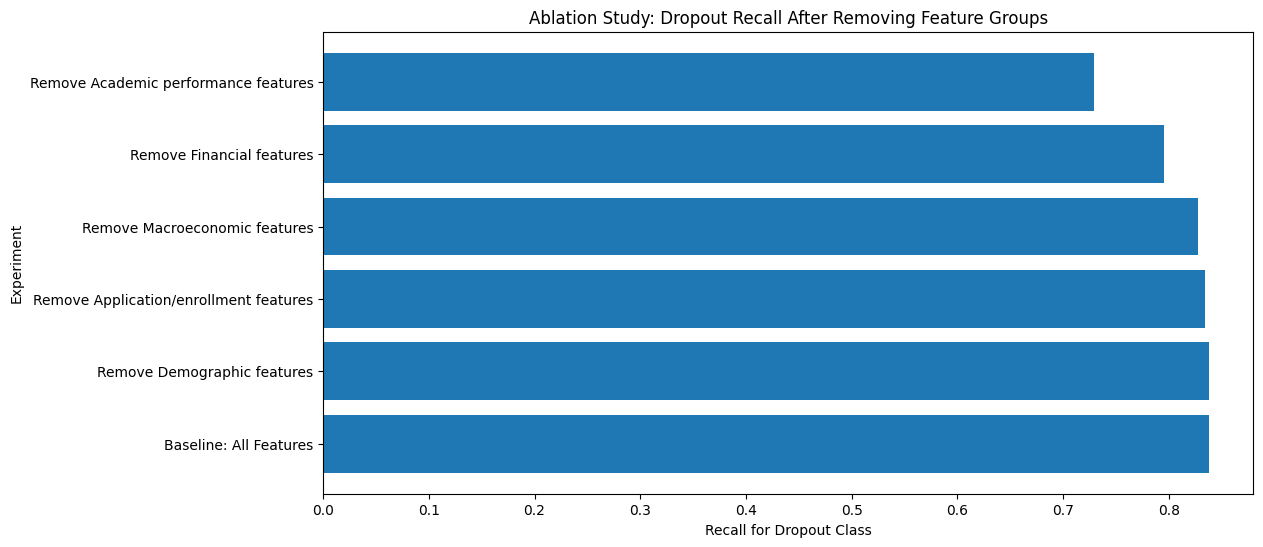

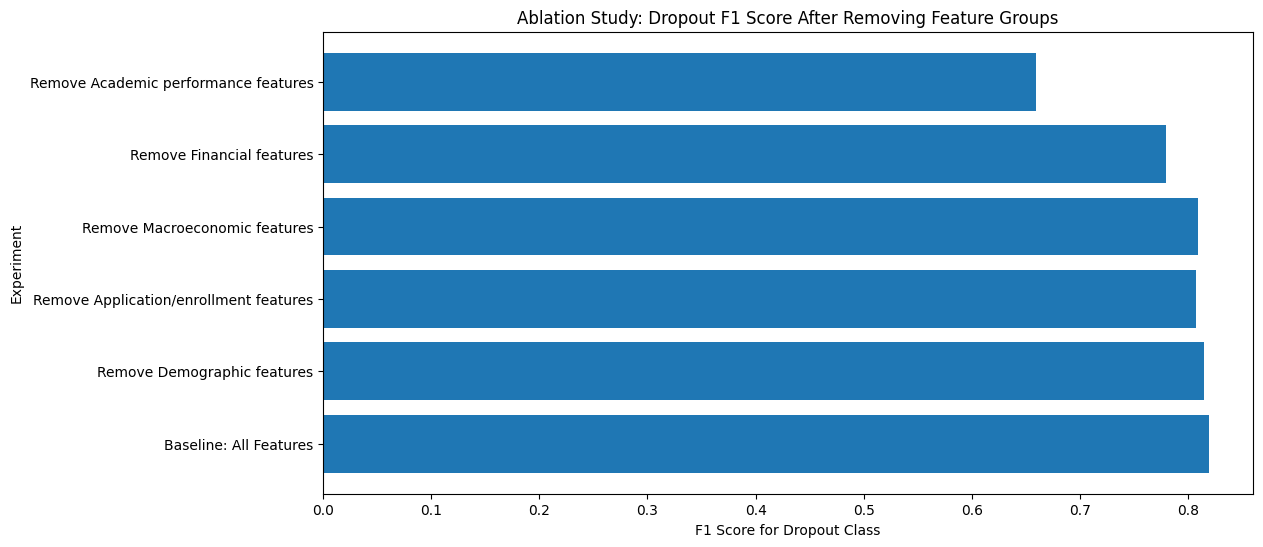

In [59]:
plot_df = ablation_results_df.copy()

plt.figure(figsize=(12, 6))
plt.barh(plot_df["Experiment"], plot_df["Recall_Dropout"])
plt.xlabel("Recall for Dropout Class")
plt.ylabel("Experiment")
plt.title("Ablation Study: Dropout Recall After Removing Feature Groups")
plt.gca().invert_yaxis()
plt.show()

plt.figure(figsize=(12, 6))
plt.barh(plot_df["Experiment"], plot_df["F1_Dropout"])
plt.xlabel("F1 Score for Dropout Class")
plt.ylabel("Experiment")
plt.title("Ablation Study: Dropout F1 Score After Removing Feature Groups")
plt.gca().invert_yaxis()
plt.show()

In [60]:
baseline_row = ablation_results_df[
    ablation_results_df["Experiment"] == "Baseline: All Features"
].iloc[0]

ablation_only_df = ablation_results_df[
    ablation_results_df["Experiment"] != "Baseline: All Features"
].copy()

largest_recall_drop = ablation_only_df.sort_values(
    by="Recall_Change_From_Baseline"
).iloc[0]

largest_f1_drop = ablation_only_df.sort_values(
    by="F1_Change_From_Baseline"
).iloc[0]

print("Baseline Performance:")
print(f"Recall for Dropout: {baseline_row['Recall_Dropout']:.3f}")
print(f"F1 for Dropout: {baseline_row['F1_Dropout']:.3f}")

print("\nMost important feature group based on recall drop:")
print(largest_recall_drop["Experiment"])
print(f"Recall change: {largest_recall_drop['Recall_Change_From_Baseline']:.3f}")

print("\nMost important feature group based on F1 drop:")
print(largest_f1_drop["Experiment"])
print(f"F1 change: {largest_f1_drop['F1_Change_From_Baseline']:.3f}")

print("\nInterpretation template:")
print(
    "The ablation study suggests that the most important feature group is the one whose removal caused "
    "the largest drop in dropout recall or F1-score. Since recall measures how many actual dropout students "
    "the model correctly identifies, a large recall decrease means that feature group is especially important "
    "for detecting at-risk students."
)

Baseline Performance:
Recall for Dropout: 0.838
F1 for Dropout: 0.819

Most important feature group based on recall drop:
Remove Academic performance features
Recall change: -0.109

Most important feature group based on F1 drop:
Remove Academic performance features
F1 change: -0.160

Interpretation template:
The ablation study suggests that the most important feature group is the one whose removal caused the largest drop in dropout recall or F1-score. Since recall measures how many actual dropout students the model correctly identifies, a large recall decrease means that feature group is especially important for detecting at-risk students.


## MLP Ablation Study
Now, let's perform the ablation study on our tuned Deep Learning (MLP) model. We will systematically remove feature groups, train a new MLP from scratch (adjusting the input dimension), and measure the impact on the validation set.

In [61]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import copy
import os

def evaluate_mlp_ablation(X_train_sub, X_val_sub, y_train_sub, y_val_sub, experiment_name):
    print(f"\n--- Running: {experiment_name} ---")

    # 1. Create Datasets and DataLoaders
    train_dataset_ab = StudentDataset(X_train_sub, y_train_sub)
    val_dataset_ab = StudentDataset(X_val_sub, y_val_sub)

    train_loader_ab = DataLoader(train_dataset_ab, batch_size=best_batch_size, shuffle=True)
    val_loader_ab = DataLoader(val_dataset_ab, batch_size=best_batch_size, shuffle=False)

    # 2. Initialize Model with new input dimension
    model_ab = FlexibleMLP(
        input_dim=X_train_sub.shape[1],
        hidden_dims=best_hidden_dims,
        dropout_rate=best_dropout_rate,
        use_batchnorm=best_batchnorm,
        num_classes=2
    )

    # 3. Optimizer and Loss
    optimizer_ab = torch.optim.Adam(model_ab.parameters(), lr=best_lr, weight_decay=best_weight_decay)
    criterion_ab = nn.CrossEntropyLoss()

    model_path = f'models/ablation_{experiment_name.replace(" ", "_")}.pt'

    # 4. Train the model using train_and_evaluate (it handles early stopping and loads best weights)
    # We'll use a slightly shorter epoch count for the ablation study to save time
    train_and_evaluate(
        model=model_ab,
        train_loader=train_loader_ab,
        val_loader=val_loader_ab,
        criterion=criterion_ab,
        lr=best_lr,
        weight_decay=best_weight_decay,
        epochs=50,
        patience=5,
        model_path=model_path
    )

    # 5. Evaluate on Validation Set
    model_ab.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in val_loader_ab:
            outputs = model_ab(inputs)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    results = {
        "Experiment": experiment_name,
        "Number of Features": X_train_sub.shape[1],
        "Accuracy": accuracy_score(all_labels, all_preds),
        "Precision_Dropout": precision_score(all_labels, all_preds, pos_label=1, zero_division=0),
        "Recall_Dropout": recall_score(all_labels, all_preds, pos_label=1, zero_division=0),
        "F1_Dropout": f1_score(all_labels, all_preds, pos_label=1, zero_division=0)
    }

    return results


In [62]:
mlp_ablation_results = []

# 1. Baseline MLP
baseline_mlp_results = evaluate_mlp_ablation(
    X_train_sub=X_train_final,
    X_val_sub=X_val,
    y_train_sub=y_train_final,
    y_val_sub=y_val,
    experiment_name="Baseline MLP: All Features"
)
mlp_ablation_results.append(baseline_mlp_results)

# 2. Ablation models: remove one feature group at a time
for group_name, keywords in feature_groups.items():
    cols_to_remove = get_matching_columns(X_train_final.columns, keywords)

    if len(cols_to_remove) == 0:
        print(f"Skipping {group_name}: no matching columns found.")
        continue

    X_train_ablated = X_train_final.drop(columns=cols_to_remove)
    X_val_ablated = X_val.drop(columns=cols_to_remove)

    experiment_name = f"Remove {group_name}"

    results = evaluate_mlp_ablation(
        X_train_sub=X_train_ablated,
        X_val_sub=X_val_ablated,
        y_train_sub=y_train_final,
        y_val_sub=y_val,
        experiment_name=experiment_name
    )
    mlp_ablation_results.append(results)

# Convert results to DataFrame
mlp_ablation_df = pd.DataFrame(mlp_ablation_results)

# Calculate change from baseline
baseline_mlp_recall = mlp_ablation_df.loc[
    mlp_ablation_df["Experiment"] == "Baseline MLP: All Features",
    "Recall_Dropout"
].iloc[0]

baseline_mlp_f1 = mlp_ablation_df.loc[
    mlp_ablation_df["Experiment"] == "Baseline MLP: All Features",
    "F1_Dropout"
].iloc[0]

mlp_ablation_df["Recall_Change_From_Baseline"] = (
    mlp_ablation_df["Recall_Dropout"] - baseline_mlp_recall
)

mlp_ablation_df["F1_Change_From_Baseline"] = (
    mlp_ablation_df["F1_Dropout"] - baseline_mlp_f1
)

# Sort so the biggest recall drop appears near the top
mlp_ablation_df = mlp_ablation_df.sort_values(by="Recall_Change_From_Baseline")

display(mlp_ablation_df)



--- Running: Baseline MLP: All Features ---

--- Running: Remove Academic performance features ---

--- Running: Remove Financial features ---

--- Running: Remove Demographic features ---
Skipping Family background features: no matching columns found.

--- Running: Remove Application/enrollment features ---

--- Running: Remove Macroeconomic features ---


,Experiment,Number of Features,Accuracy,Precision_Dropout,Recall_Dropout,F1_Dropout,Recall_Change_From_Baseline,F1_Change_From_Baseline
1,Remove Academic performance features,216,0.787571,0.703390,0.584507,0.638462,-0.165493,-0.163798
2,Remove Financial features,242,0.859887,0.866972,0.665493,0.752988,-0.084507,-0.049272
3,Remove Demographic features,229,0.877966,0.896396,0.700704,0.786561,-0.049296,-0.015699
4,Remove Application/enrollment features,189,0.882486,0.894737,0.718310,0.796875,-0.031690,-0.005385
5,Remove Macroeconomic features,242,0.873446,0.864407,0.718310,0.784615,-0.031690,-0.017645
0,Baseline MLP: All Features,245,0.881356,0.862348,0.750000,0.802260,0.000000,0.000000


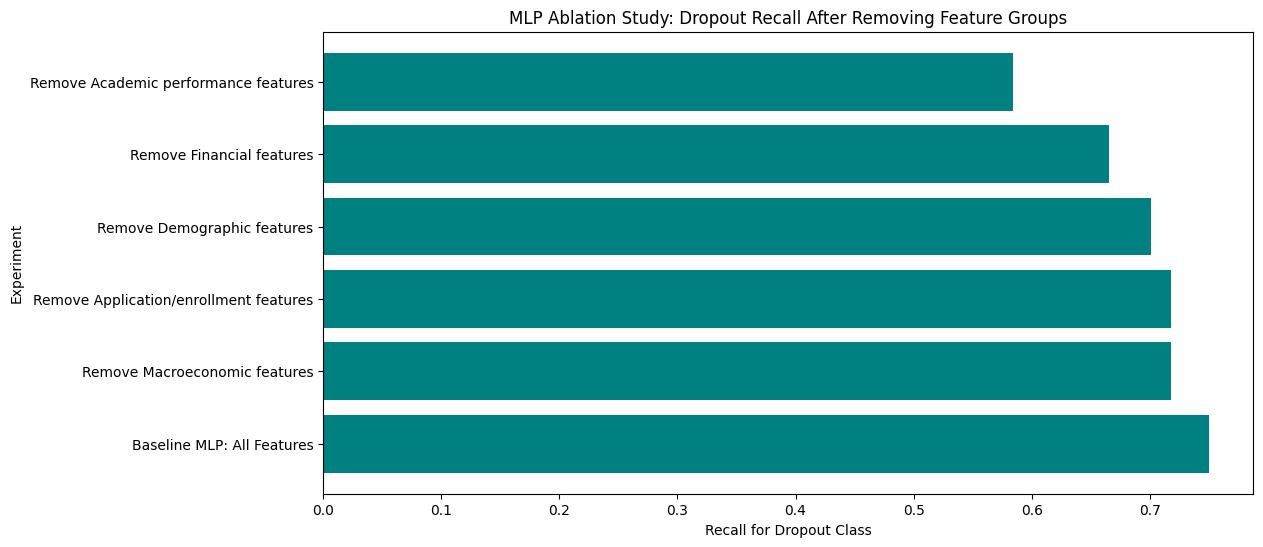

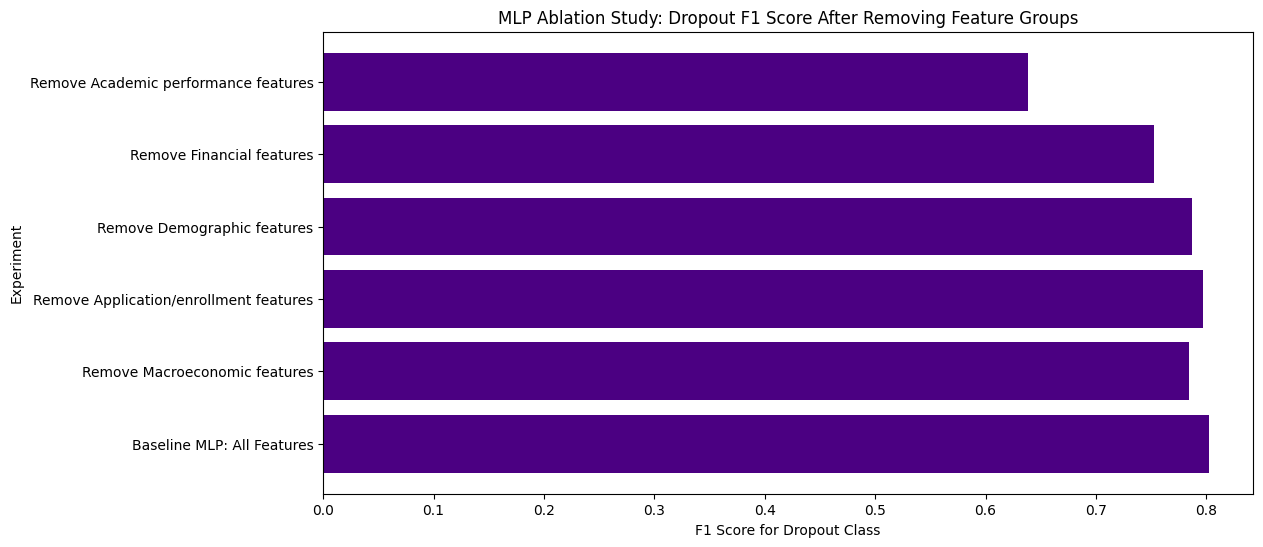

In [63]:
plot_mlp_df = mlp_ablation_df.copy()

plt.figure(figsize=(12, 6))
plt.barh(plot_mlp_df["Experiment"], plot_mlp_df["Recall_Dropout"], color='teal')
plt.xlabel("Recall for Dropout Class")
plt.ylabel("Experiment")
plt.title("MLP Ablation Study: Dropout Recall After Removing Feature Groups")
plt.gca().invert_yaxis()
plt.show()

plt.figure(figsize=(12, 6))
plt.barh(plot_mlp_df["Experiment"], plot_mlp_df["F1_Dropout"], color='indigo')
plt.xlabel("F1 Score for Dropout Class")
plt.ylabel("Experiment")
plt.title("MLP Ablation Study: Dropout F1 Score After Removing Feature Groups")
plt.gca().invert_yaxis()
plt.show()


--- Ablation Impact Comparison (Change from Baseline) ---


,Experiment,Recall_Change_From_Baseline_LR,F1_Change_From_Baseline_LR,Recall_Change_From_Baseline_MLP,F1_Change_From_Baseline_MLP
0,Remove Academic performance features,-0.1092,-0.1600,-0.1655,-0.1638
1,Remove Financial features,-0.0423,-0.0400,-0.0845,-0.0493
2,Remove Macroeconomic features,-0.0106,-0.0103,-0.0317,-0.0176
3,Remove Application/enrollment features,-0.0035,-0.0118,-0.0317,-0.0054
4,Remove Demographic features,0.0000,-0.0042,-0.0493,-0.0157


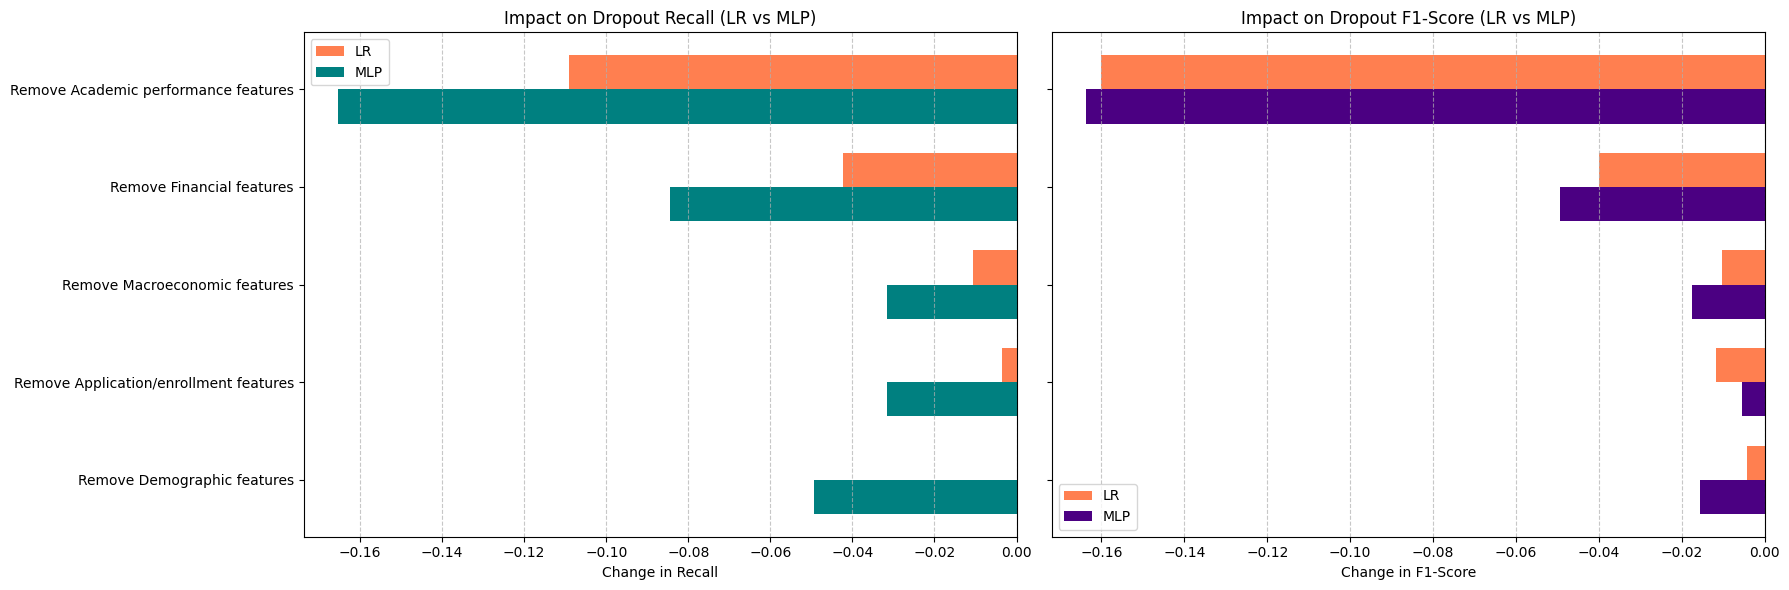

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if 'ablation_results_df' in locals() and 'mlp_ablation_df' in locals():
    # Filter to only the "Remove..." experiments
    lr_subset = ablation_results_df[ablation_results_df['Experiment'].str.startswith('Remove')].copy()
    mlp_subset = mlp_ablation_df[mlp_ablation_df['Experiment'].str.startswith('Remove')].copy()

    # Merge the results
    comp_df = pd.merge(
        lr_subset[['Experiment', 'Recall_Change_From_Baseline', 'F1_Change_From_Baseline']],
        mlp_subset[['Experiment', 'Recall_Change_From_Baseline', 'F1_Change_From_Baseline']],
        on='Experiment',
        suffixes=('_LR', '_MLP')
    )

    # Sort by LR Recall Drop for a clean visual hierarchy
    comp_df = comp_df.sort_values('Recall_Change_From_Baseline_LR')

    print("--- Ablation Impact Comparison (Change from Baseline) ---")
    display(comp_df.round(4))

    # Plot Recall Comparison
    x = np.arange(len(comp_df['Experiment']))
    width = 0.35

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

    # Recall Subplot
    axes[0].barh(x - width/2, comp_df['Recall_Change_From_Baseline_LR'], width, label='LR', color='coral')
    axes[0].barh(x + width/2, comp_df['Recall_Change_From_Baseline_MLP'], width, label='MLP', color='teal')
    axes[0].set_xlabel('Change in Recall')
    axes[0].set_title('Impact on Dropout Recall (LR vs MLP)')
    axes[0].set_yticks(x)
    axes[0].set_yticklabels(comp_df['Experiment'])
    axes[0].legend()
    axes[0].grid(axis='x', linestyle='--', alpha=0.7)

    # F1-Score Subplot
    axes[1].barh(x - width/2, comp_df['F1_Change_From_Baseline_LR'], width, label='LR', color='coral')
    axes[1].barh(x + width/2, comp_df['F1_Change_From_Baseline_MLP'], width, label='MLP', color='indigo')
    axes[1].set_xlabel('Change in F1-Score')
    axes[1].set_title('Impact on Dropout F1-Score (LR vs MLP)')
    axes[1].legend()
    axes[1].grid(axis='x', linestyle='--', alpha=0.7)

    # Invert y-axis to have the most impactful at the top
    axes[0].invert_yaxis()

    plt.tight_layout()
    plt.show()
else:
    print("Ablation result dataframes not found. Please run both ablation studies first.")

### LR vs. MLP Ablation Comparison Findings
* **Consistency in Importance:** If both models show the largest performance drops for the same feature groups (e.g., *Academic performance features*), it confirms that these factors are universally critical for predicting dropout, regardless of the model architecture.
* **Model Robustness:** A deep learning model like an MLP might show different sensitivities compared to a linear model. If the MLP's recall drops *less* when a certain feature group is removed compared to Logistic Regression, it suggests the MLP is better at extracting compensatory signals from the remaining features.